# Example 1: Symmetric Decomposition with Optimized Schwarz PINNs

**How to use it:** run the first seed cell to create the trained `z1`/`z2` models and checkpoints, then run the visualization/reconstruction cells. Run the other seed cells only when you want to regenerate robustness results.


## Seed 1234 Training Run

This cell sets up the manufactured problem, defines the PINN model, builds the optimized Schwarz interface operator, and trains the two subdomain models for seed `1234`.


In [ ]:
# @title Example 1: Optimized Schwarz PINN, seed 1234
# -----------------------------------------------------------------------------
# Purpose: train two PINNs on the overlapping subdomains and run the global-in-time Schwarz iteration.
# Inputs: manufactured solution, domain settings, collocation points, and the selected random seed.
# Outputs: trained z1/z2 models, checkpoints, convergence logs, and L2/interface-jump diagnostics.
# -----------------------------------------------------------------------------

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

# ---------------- reproducibility and runtime device ----------------
torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

# ---------------- problem setup ----------------
L, delta = 1.0, 0.5
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

# ---------- manufactured solution for u, v, and forcing ----------
def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

# ---------- sampling and autograd helpers ----------
def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

# ---------- complex DtN kernels and time-convolution matrices ----------
def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-2/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a
    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)
    spec = sign * (k * c / s)
    limit = 2.0
    spec = np.clip(np.abs(spec), 0, limit) * np.exp(1j * np.angle(spec))
    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)


# ---------- interface operator in real 2x2 form ----------
def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

# ---------- PINN architecture with hard initial/boundary conditions ----------
class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)
        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]
        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

# ---------- loss weights ----------
w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

# ---------- collocation and interface grids ----------
Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)
z1, z2 = new_model(1), new_model(2)

# ---------- validation and plotting helpers ----------
def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))
@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1
    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)
    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)
    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)
    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")
    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}
# ---------- warm-start training on each subdomain ----------
def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()
def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net
def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)
    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)
    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2
    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2
t_decomp_total0 = _now()
# ---------------- global-in-time Schwarz iteration ----------------
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")
    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)
    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 28.828 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 18.928 s
r1=2.925e-01  r2=5.086e+00  (max=5.086e+00)
[iter 1] L2(u)=6.341e-01  L2(v)=4.274e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.732e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 20.778 s
r1=2.944e+00  r2=1.948e-01  (max=2.944e+00)
[iter 2] L2(u)=2.368e-01  L2(v)=3.753e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=9.692e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.408 s
r1=1.299e-01  r2=1.639e+00  (max=1.639e+00)
[iter 3] L2(u)=2.152e-01  L2(v)=1.227e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.207e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 19.193 s
r1=8.751e-01  r2=8.900e-02  (max=8.751e-01)
[iter 4] L2(u)=6.089e-02  L2(v)=1.180e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.694e-01

=== Schwarz iteration 5 (global in time, parallel J

## Convergence Diagnostics

This cell parses the printed training log and produces convergence figures for the maximum L2 error and interface jump.


[parse] points: L2(u)=200, L2(v)=200, gap=200, time=200
[info] k*_acc = 14, t*_acc = 258.625
[info] k*_gap = 19, t*_gap = 311.782
[info] best_acc_iter = 26, best_maxL2 = 0.000167
[info] best_gap_iter = 185, best_gap = 0.000221
[Saved] content/mntt/seq_maxL2_gap_convergence.png + content/mntt/seq_maxL2_gap_convergence.svg


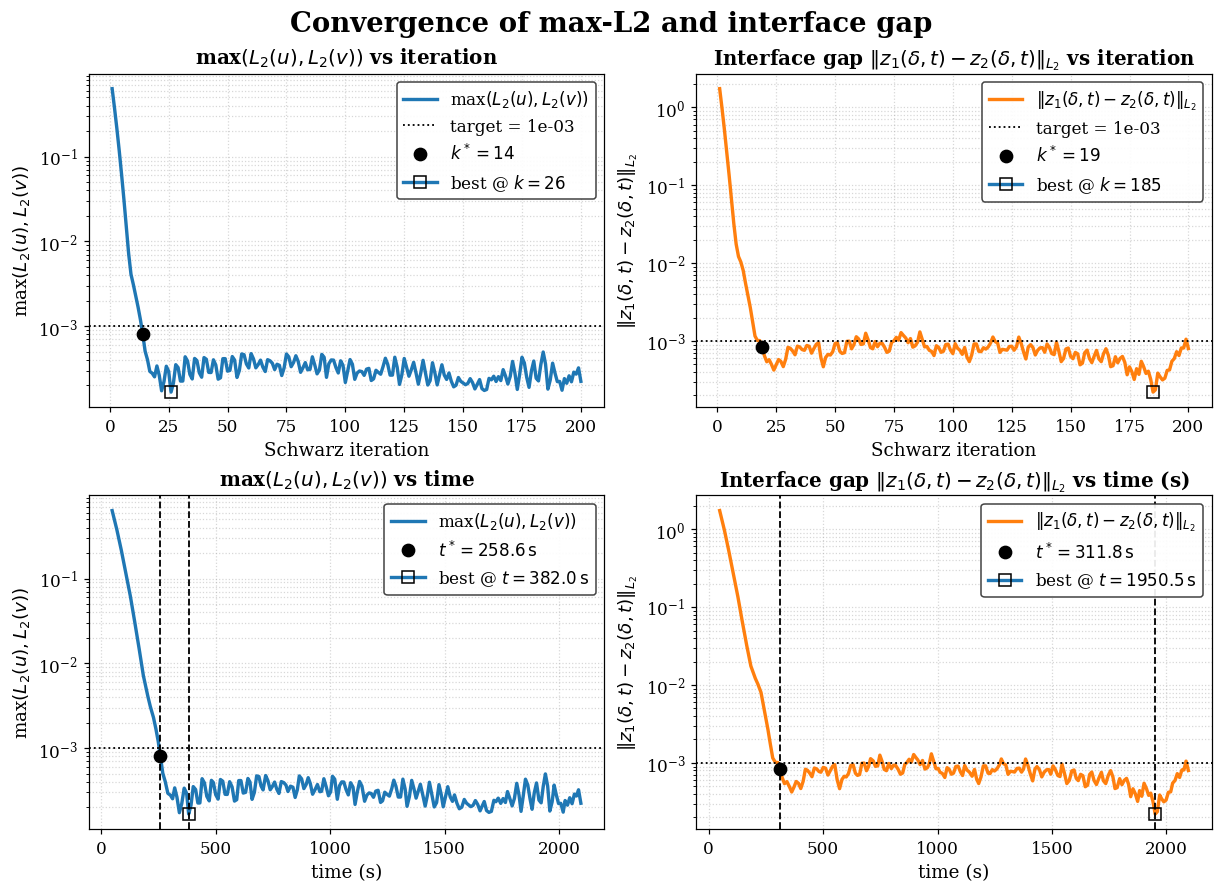

PNG saved at: content/mntt/seq_maxL2_gap_convergence.png
SVG saved at: content/mntt/seq_maxL2_gap_convergence.svg


In [ ]:
# @title Convergence of max-L2 error and interface jump
# -----------------------------------------------------------------------------
# Purpose: parse a single training log and generate convergence plots.
# Inputs: the `sequential_log` string and plotting configuration.
# Outputs: PNG/SVG figures and printed convergence summaries.
# -----------------------------------------------------------------------------

import os, re, math
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, Image
OUTDIR      = globals().get("OUTDIR", "content/mntt")
CAP_ITERS   = globals().get("CAP_ITERS", 200)
TARGET_ACC  = 1e-3
TARGET_GAP  = 1e-3
SAVE_SVG    = True
DPI_PNG     = 300

os.makedirs(OUTDIR, exist_ok=True)
plt.style.use("default")
mpl.rcParams.update({
    "figure.figsize"     : (11, 8),
    "figure.dpi"         : 110,
    "font.family"        : "serif",
    "font.size"          : 11,
    "axes.labelsize"     : 12,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.grid"          : True,
    "grid.linestyle"     : ":",
    "grid.alpha"         : 0.5,
    "grid.linewidth"     : 0.8,
    "legend.fontsize"    : 11,
    "legend.frameon"     : True,
    "legend.framealpha"  : 0.92,
    "legend.edgecolor"   : "0.2",
    "lines.linewidth"    : 2.2,
    "lines.markersize"   : 7,
    "savefig.bbox"       : "tight",
    "savefig.pad_inches" : 0.1,
    "savefig.dpi"        : DPI_PNG,
    "xtick.labelsize"    : 11,
    "ytick.labelsize"    : 11,
})

CB = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
_num = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
re_warm      = re.compile(r"\[Timing\]\s*Warm-?start\s+total.*?:\s*(" + _num + r")\s*s", re.IGNORECASE)
re_iter_time = re.compile(r"\[Timing\]\s*Schwarz\s+iter\s+(\d+)\s*:\s*(" + _num + r")\s*s", re.IGNORECASE)
re_l2_pair   = re.compile(r"\[iter\s+(\d+)\]\s*L2\(u\)=(" + _num + r")\s*L2\(v\)=(" + _num + r")", re.IGNORECASE)
re_gap       = re.compile(r"\[iter\s+(\d+)\]\s*z1.*?=\s*(" + _num + r")", re.IGNORECASE)

def parse_log(log_text: str):
    if not log_text or not log_text.strip():
        return dict(
            warm_start=0.0, iter_order=[],
            iter_time={}, iter_l2u={}, iter_l2v={}, iter_gap={}
        )

    warm = 0.0
    m = re_warm.search(log_text)
    if m:
        warm = float(m.group(1))

    iter_time, iter_l2u, iter_l2v, iter_gap = {}, {}, {}, {}

    for k, t in re_iter_time.findall(log_text):
        iter_time[int(k)] = float(t)

    for k, u, v in re_l2_pair.findall(log_text):
        i = int(k)
        iter_l2u[i] = float(u)
        iter_l2v[i] = float(v)

    for k, g in re_gap.findall(log_text):
        iter_gap[int(k)] = float(g)

    iters = sorted(set(iter_time) | set(iter_l2u) | set(iter_l2v) | set(iter_gap))
    print(f"[parse] points: L2(u)={len(iter_l2u)}, L2(v)={len(iter_l2v)}, "
          f"gap={len(iter_gap)}, time={len(iter_time)}")

    return dict(
        warm_start=warm,
        iter_order=iters,
        iter_time=iter_time,
        iter_l2u=iter_l2u,
        iter_l2v=iter_l2v,
        iter_gap=iter_gap
    )
def wall_time_of(k, iters, tmap, warm):
    if k is None:
        return None
    return warm + sum(tmap.get(i, 0.0) for i in iters if i <= k)

def first_iter_below_threshold(values_dict, iters, thresh):
    for k in iters:
        v = values_dict.get(k, math.inf)
        if math.isfinite(v) and v <= thresh:
            return k
    return None

def best_iter_and_value(values_dict, iters):
    best_k, best_v = None, None
    for k in iters:
        v = values_dict.get(k, None)
        if v is None or not math.isfinite(v):
            continue
        if best_v is None or v < best_v:
            best_v, best_k = v, k
    return best_k, best_v

def save_and_show(fig, base, show_saved_image=False):
    png = f"{base}.png"
    svg = f"{base}.svg"

    fig.savefig(png, dpi=DPI_PNG)
    if SAVE_SVG:
        fig.savefig(svg)

    print(f"[Saved] {png}" + (f" + {svg}" if SAVE_SVG else ""))

    plt.show()
    if show_saved_image and os.path.exists(png):
        display(Image(filename=png))

    plt.close(fig)
    return png, (svg if SAVE_SVG else None)
sequential_log = """
Device : cpu
[Timing] Warm-start total (parallel): 28.828 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 18.928 s
r1=2.925e-01  r2=5.086e+00  (max=5.086e+00)
[iter 1] L2(u)=6.341e-01  L2(v)=4.274e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.732e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 20.778 s
r1=2.944e+00  r2=1.948e-01  (max=2.944e+00)
[iter 2] L2(u)=2.368e-01  L2(v)=3.753e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=9.692e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.408 s
r1=1.299e-01  r2=1.639e+00  (max=1.639e+00)
[iter 3] L2(u)=2.152e-01  L2(v)=1.227e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.207e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 19.193 s
r1=8.751e-01  r2=8.900e-02  (max=8.751e-01)
[iter 4] L2(u)=6.089e-02  L2(v)=1.180e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.694e-01

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 20.300 s
r1=5.243e-02  r2=4.529e-01  (max=4.529e-01)
[iter 5] L2(u)=6.183e-02  L2(v)=3.002e-02
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.355e-01

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 18.620 s
r1=2.262e-01  r2=3.386e-02  (max=2.262e-01)
[iter 6] L2(u)=1.513e-02  L2(v)=3.122e-02
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=6.658e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 19.893 s
r1=2.107e-02  r2=1.095e-01  (max=1.095e-01)
[iter 7] L2(u)=1.473e-02  L2(v)=8.097e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=3.225e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 18.093 s
r1=5.029e-02  r2=1.578e-02  (max=5.029e-02)
[iter 8] L2(u)=4.146e-03  L2(v)=7.193e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=1.753e-02

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 19.628 s
r1=1.286e-02  r2=2.484e-02  (max=2.484e-02)
[iter 9] L2(u)=4.096e-03  L2(v)=2.129e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=1.214e-02

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 10.801 s
r1=1.708e-02  r2=1.044e-02  (max=1.708e-02)
[iter 10] L2(u)=1.445e-03  L2(v)=3.101e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=1.032e-02

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 13.890 s
r1=7.691e-03  r2=1.419e-02  (max=1.419e-02)
[iter 11] L2(u)=2.296e-03  L2(v)=1.046e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=8.031e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 10.628 s
r1=1.134e-02  r2=5.431e-03  (max=1.134e-02)
[iter 12] L2(u)=1.007e-03  L2(v)=1.684e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=5.486e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 10.167 s
r1=3.617e-03  r2=8.511e-03  (max=8.511e-03)
[iter 13] L2(u)=1.196e-03  L2(v)=1.034e-03
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=3.833e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 9.470 s
r1=5.795e-03  r2=2.915e-03  (max=5.795e-03)
[iter 14] L2(u)=7.211e-04  L2(v)=8.034e-04
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.692e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 10.305 s
r1=2.348e-03  r2=4.020e-03  (max=4.020e-03)
[iter 15] L2(u)=5.065e-04  L2(v)=3.364e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=1.759e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 10.707 s
r1=2.619e-03  r2=1.987e-03  (max=2.619e-03)
[iter 16] L2(u)=2.316e-04  L2(v)=4.036e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.158e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 11.605 s
r1=1.655e-03  r2=2.001e-03  (max=2.001e-03)
[iter 17] L2(u)=2.927e-04  L2(v)=2.884e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.017e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 10.824 s
r1=1.647e-03  r2=1.714e-03  (max=1.714e-03)
[iter 18] L2(u)=2.013e-04  L2(v)=2.790e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.013e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 9.716 s
r1=1.688e-03  r2=1.551e-03  (max=1.688e-03)
[iter 19] L2(u)=2.528e-04  L2(v)=2.056e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=8.483e-04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.271 s
r1=1.418e-03  r2=1.677e-03  (max=1.677e-03)
[iter 20] L2(u)=2.079e-04  L2(v)=3.398e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=6.461e-04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.948 s
r1=1.347e-03  r2=1.423e-03  (max=1.423e-03)
[iter 21] L2(u)=2.630e-04  L2(v)=1.731e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=5.417e-04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 10.465 s
r1=1.107e-03  r2=1.468e-03  (max=1.468e-03)
[iter 22] L2(u)=1.363e-04  L2(v)=1.731e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=5.758e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 10.461 s
r1=1.401e-03  r2=1.325e-03  (max=1.401e-03)
[iter 23] L2(u)=1.500e-04  L2(v)=2.215e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=5.004e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 10.625 s
r1=1.245e-03  r2=1.431e-03  (max=1.431e-03)
[iter 24] L2(u)=2.119e-04  L2(v)=3.372e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=4.238e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 10.600 s
r1=1.306e-03  r2=1.314e-03  (max=1.314e-03)
[iter 25] L2(u)=2.934e-04  L2(v)=1.931e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=4.952e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 8.856 s
r1=1.159e-03  r2=1.412e-03  (max=1.412e-03)
[iter 26] L2(u)=1.620e-04  L2(v)=1.670e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=5.782e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 10.283 s
r1=1.580e-03  r2=1.220e-03  (max=1.580e-03)
[iter 27] L2(u)=1.480e-04  L2(v)=2.118e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=5.471e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 9.796 s
r1=1.243e-03  r2=1.336e-03  (max=1.336e-03)
[iter 28] L2(u)=2.251e-04  L2(v)=3.516e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=4.693e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 10.366 s
r1=1.360e-03  r2=1.202e-03  (max=1.360e-03)
[iter 29] L2(u)=3.252e-04  L2(v)=2.029e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=5.803e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 9.811 s
r1=1.261e-03  r2=1.643e-03  (max=1.643e-03)
[iter 30] L2(u)=2.028e-04  L2(v)=2.252e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=8.301e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 8.856 s
r1=1.805e-03  r2=1.268e-03  (max=1.805e-03)
[iter 31] L2(u)=2.205e-04  L2(v)=2.255e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=8.063e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 9.643 s
r1=1.372e-03  r2=1.803e-03  (max=1.803e-03)
[iter 32] L2(u)=2.265e-04  L2(v)=4.359e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=7.426e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 10.213 s
r1=1.415e-03  r2=1.425e-03  (max=1.425e-03)
[iter 33] L2(u)=3.890e-04  L2(v)=2.564e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=6.662e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 10.357 s
r1=1.423e-03  r2=1.631e-03  (max=1.631e-03)
[iter 34] L2(u)=2.123e-04  L2(v)=2.702e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=8.597e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 10.574 s
r1=1.628e-03  r2=1.414e-03  (max=1.628e-03)
[iter 35] L2(u)=2.387e-04  L2(v)=1.895e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=8.373e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 9.629 s
r1=1.394e-03  r2=1.669e-03  (max=1.669e-03)
[iter 36] L2(u)=1.959e-04  L2(v)=4.168e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=7.760e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.498 s
r1=1.436e-03  r2=1.537e-03  (max=1.537e-03)
[iter 37] L2(u)=3.927e-04  L2(v)=2.615e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=7.597e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 10.151 s
r1=1.426e-03  r2=1.683e-03  (max=1.683e-03)
[iter 38] L2(u)=2.279e-04  L2(v)=2.823e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=8.776e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 10.387 s
r1=1.603e-03  r2=1.492e-03  (max=1.603e-03)
[iter 39] L2(u)=2.503e-04  L2(v)=1.833e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=8.552e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 10.287 s
r1=1.383e-03  r2=1.594e-03  (max=1.594e-03)
[iter 40] L2(u)=2.073e-04  L2(v)=4.268e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=6.990e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 10.186 s
r1=1.489e-03  r2=1.596e-03  (max=1.596e-03)
[iter 41] L2(u)=4.071e-04  L2(v)=3.007e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=7.991e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 10.114 s
r1=1.268e-03  r2=1.662e-03  (max=1.662e-03)
[iter 42] L2(u)=2.688e-04  L2(v)=2.853e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=9.067e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 9.550 s
r1=1.825e-03  r2=1.231e-03  (max=1.825e-03)
[iter 43] L2(u)=2.615e-04  L2(v)=2.841e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=9.508e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 10.432 s
r1=1.080e-03  r2=1.461e-03  (max=1.461e-03)
[iter 44] L2(u)=2.821e-04  L2(v)=4.018e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=6.081e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 10.596 s
r1=1.251e-03  r2=9.008e-04  (max=1.251e-03)
[iter 45] L2(u)=3.488e-04  L2(v)=2.605e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=4.673e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 10.521 s
r1=8.890e-04  r2=1.465e-03  (max=1.465e-03)
[iter 46] L2(u)=2.372e-04  L2(v)=2.263e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=6.155e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 9.779 s
r1=1.374e-03  r2=9.009e-04  (max=1.374e-03)
[iter 47] L2(u)=2.065e-04  L2(v)=2.466e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=6.745e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 8.711 s
r1=1.336e-03  r2=1.273e-03  (max=1.336e-03)
[iter 48] L2(u)=2.543e-04  L2(v)=4.143e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=6.607e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 9.605 s
r1=1.563e-03  r2=1.088e-03  (max=1.563e-03)
[iter 49] L2(u)=4.145e-04  L2(v)=2.896e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=7.288e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 10.238 s
r1=1.279e-03  r2=1.688e-03  (max=1.688e-03)
[iter 50] L2(u)=2.951e-04  L2(v)=2.867e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=9.283e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 10.287 s
r1=1.896e-03  r2=1.147e-03  (max=1.896e-03)
[iter 51] L2(u)=2.629e-04  L2(v)=3.009e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=9.476e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 10.016 s
r1=1.191e-03  r2=1.436e-03  (max=1.436e-03)
[iter 52] L2(u)=2.703e-04  L2(v)=4.386e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=7.375e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 9.054 s
r1=1.510e-03  r2=1.016e-03  (max=1.510e-03)
[iter 53] L2(u)=3.984e-04  L2(v)=2.911e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=6.924e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 9.127 s
r1=9.454e-04  r2=1.506e-03  (max=1.506e-03)
[iter 54] L2(u)=2.411e-04  L2(v)=2.487e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=7.091e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 10.014 s
r1=1.763e-03  r2=1.094e-03  (max=1.763e-03)
[iter 55] L2(u)=2.806e-04  L2(v)=2.999e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=9.911e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 10.057 s
r1=1.369e-03  r2=1.643e-03  (max=1.643e-03)
[iter 56] L2(u)=2.918e-04  L2(v)=4.708e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=9.970e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 10.035 s
r1=1.897e-03  r2=1.154e-03  (max=1.897e-03)
[iter 57] L2(u)=4.615e-04  L2(v)=3.067e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=7.951e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 9.074 s
r1=1.467e-03  r2=1.968e-03  (max=1.968e-03)
[iter 58] L2(u)=3.398e-04  L2(v)=3.584e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=8.990e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.915 s
r1=1.992e-03  r2=1.468e-03  (max=1.992e-03)
[iter 59] L2(u)=3.217e-04  L2(v)=3.153e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.135e-03

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 11.240 s
r1=1.630e-03  r2=1.666e-03  (max=1.666e-03)
[iter 60] L2(u)=2.472e-04  L2(v)=4.749e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.064e-03

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 10.026 s
r1=1.739e-03  r2=1.340e-03  (max=1.739e-03)
[iter 61] L2(u)=4.123e-04  L2(v)=2.838e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=9.031e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 9.943 s
r1=1.446e-03  r2=1.815e-03  (max=1.815e-03)
[iter 62] L2(u)=2.861e-04  L2(v)=3.229e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=9.180e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 9.319 s
r1=2.231e-03  r2=1.366e-03  (max=2.231e-03)
[iter 63] L2(u)=3.178e-04  L2(v)=3.526e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=1.259e-03

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.858 s
r1=1.212e-03  r2=1.794e-03  (max=1.794e-03)
[iter 64] L2(u)=2.967e-04  L2(v)=3.978e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.043e-03

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 9.427 s
r1=1.568e-03  r2=1.125e-03  (max=1.568e-03)
[iter 65] L2(u)=3.282e-04  L2(v)=2.967e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=8.254e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 9.648 s
r1=9.365e-04  r2=1.436e-03  (max=1.436e-03)
[iter 66] L2(u)=2.921e-04  L2(v)=2.073e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=7.954e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 10.184 s
r1=1.563e-03  r2=1.017e-03  (max=1.563e-03)
[iter 67] L2(u)=2.498e-04  L2(v)=4.032e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=9.845e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 11.042 s
r1=9.131e-04  r2=1.419e-03  (max=1.419e-03)
[iter 68] L2(u)=3.914e-04  L2(v)=3.892e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=8.450e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 9.324 s
r1=2.031e-03  r2=1.189e-03  (max=2.031e-03)
[iter 69] L2(u)=3.663e-04  L2(v)=3.411e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=9.330e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.751 s
r1=1.006e-03  r2=1.686e-03  (max=1.686e-03)
[iter 70] L2(u)=3.079e-04  L2(v)=2.432e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=9.335e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 11.154 s
r1=1.401e-03  r2=1.122e-03  (max=1.401e-03)
[iter 71] L2(u)=2.210e-04  L2(v)=3.558e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=8.319e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 10.555 s
r1=1.299e-03  r2=1.176e-03  (max=1.299e-03)
[iter 72] L2(u)=3.458e-04  L2(v)=2.587e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=7.160e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 9.682 s
r1=1.017e-03  r2=1.439e-03  (max=1.439e-03)
[iter 73] L2(u)=2.619e-04  L2(v)=2.472e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=7.429e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 9.554 s
r1=1.758e-03  r2=1.173e-03  (max=1.758e-03)
[iter 74] L2(u)=2.703e-04  L2(v)=3.222e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=9.609e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.510 s
r1=1.344e-03  r2=1.580e-03  (max=1.580e-03)
[iter 75] L2(u)=3.145e-04  L2(v)=4.698e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=1.007e-03

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 10.140 s
r1=2.056e-03  r2=1.473e-03  (max=2.056e-03)
[iter 76] L2(u)=4.345e-04  L2(v)=3.518e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.115e-03

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 9.911 s
r1=1.175e-03  r2=2.065e-03  (max=2.065e-03)
[iter 77] L2(u)=3.330e-04  L2(v)=2.791e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.026e-03

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 9.971 s
r1=2.157e-03  r2=1.422e-03  (max=2.157e-03)
[iter 78] L2(u)=3.195e-04  L2(v)=3.725e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=1.283e-03

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 8.908 s
r1=1.402e-03  r2=1.957e-03  (max=1.957e-03)
[iter 79] L2(u)=2.772e-04  L2(v)=4.482e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=1.181e-03

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 9.053 s
r1=2.162e-03  r2=1.325e-03  (max=2.162e-03)
[iter 80] L2(u)=3.833e-04  L2(v)=3.097e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=1.094e-03

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 10.255 s
r1=8.639e-04  r2=2.118e-03  (max=2.118e-03)
[iter 81] L2(u)=2.859e-04  L2(v)=2.533e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=9.511e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 10.444 s
r1=2.005e-03  r2=8.997e-04  (max=2.005e-03)
[iter 82] L2(u)=2.623e-04  L2(v)=3.229e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=1.075e-03

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 10.667 s
r1=7.431e-04  r2=1.762e-03  (max=1.762e-03)
[iter 83] L2(u)=2.553e-04  L2(v)=3.721e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=8.341e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 10.246 s
r1=1.873e-03  r2=1.140e-03  (max=1.873e-03)
[iter 84] L2(u)=3.061e-04  L2(v)=2.600e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=8.676e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 7.877 s
r1=7.985e-04  r2=1.817e-03  (max=1.817e-03)
[iter 85] L2(u)=3.096e-04  L2(v)=1.935e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=9.630e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 9.904 s
r1=1.947e-03  r2=1.342e-03  (max=1.947e-03)
[iter 86] L2(u)=2.061e-04  L2(v)=4.356e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=1.309e-03

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 10.038 s
r1=1.087e-03  r2=1.765e-03  (max=1.765e-03)
[iter 87] L2(u)=3.507e-04  L2(v)=3.077e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.052e-03

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 10.038 s
r1=1.484e-03  r2=1.283e-03  (max=1.484e-03)
[iter 88] L2(u)=2.410e-04  L2(v)=2.743e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=8.409e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 9.545 s
r1=1.445e-03  r2=1.157e-03  (max=1.445e-03)
[iter 89] L2(u)=2.963e-04  L2(v)=3.049e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=8.507e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.067 s
r1=9.153e-04  r2=1.414e-03  (max=1.414e-03)
[iter 90] L2(u)=3.003e-04  L2(v)=4.650e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=7.594e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 9.888 s
r1=1.895e-03  r2=1.026e-03  (max=1.895e-03)
[iter 91] L2(u)=4.303e-04  L2(v)=2.895e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=7.353e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 11.172 s
r1=5.296e-04  r2=1.683e-03  (max=1.683e-03)
[iter 92] L2(u)=2.493e-04  L2(v)=2.356e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=6.510e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 9.863 s
r1=1.759e-03  r2=8.218e-04  (max=1.759e-03)
[iter 93] L2(u)=2.509e-04  L2(v)=3.606e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=8.702e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 9.749 s
r1=7.510e-04  r2=1.647e-03  (max=1.647e-03)
[iter 94] L2(u)=3.382e-04  L2(v)=3.999e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=8.251e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.785 s
r1=1.433e-03  r2=1.016e-03  (max=1.433e-03)
[iter 95] L2(u)=3.985e-04  L2(v)=3.534e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=7.168e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 9.577 s
r1=1.208e-03  r2=1.502e-03  (max=1.502e-03)
[iter 96] L2(u)=3.262e-04  L2(v)=2.651e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=7.397e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 10.122 s
r1=1.477e-03  r2=1.240e-03  (max=1.477e-03)
[iter 97] L2(u)=2.501e-04  L2(v)=2.807e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=9.015e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 9.907 s
r1=1.174e-03  r2=1.386e-03  (max=1.386e-03)
[iter 98] L2(u)=2.061e-04  L2(v)=3.907e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=9.111e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 10.710 s
r1=1.452e-03  r2=1.188e-03  (max=1.452e-03)
[iter 99] L2(u)=3.464e-04  L2(v)=2.517e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=7.629e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 8.847 s
r1=1.008e-03  r2=1.596e-03  (max=1.596e-03)
[iter 100] L2(u)=2.167e-04  L2(v)=2.149e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=6.897e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 9.191 s
r1=1.677e-03  r2=1.172e-03  (max=1.677e-03)
[iter 101] L2(u)=2.976e-04  L2(v)=2.700e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=9.249e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 10.473 s
r1=1.009e-03  r2=1.564e-03  (max=1.564e-03)
[iter 102] L2(u)=2.461e-04  L2(v)=4.043e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=8.091e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 10.457 s
r1=1.793e-03  r2=1.034e-03  (max=1.793e-03)
[iter 103] L2(u)=3.557e-04  L2(v)=2.485e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=7.608e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 11.555 s
r1=6.114e-04  r2=1.649e-03  (max=1.649e-03)
[iter 104] L2(u)=2.362e-04  L2(v)=2.065e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=6.752e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 10.393 s
r1=1.471e-03  r2=7.990e-04  (max=1.471e-03)
[iter 105] L2(u)=2.201e-04  L2(v)=2.802e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=8.265e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 9.528 s
r1=7.223e-04  r2=1.263e-03  (max=1.263e-03)
[iter 106] L2(u)=2.247e-04  L2(v)=2.962e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=6.199e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 8.825 s
r1=1.205e-03  r2=8.954e-04  (max=1.205e-03)
[iter 107] L2(u)=2.918e-04  L2(v)=2.425e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=5.441e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 10.033 s
r1=6.948e-04  r2=1.314e-03  (max=1.314e-03)
[iter 108] L2(u)=2.630e-04  L2(v)=2.000e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=6.612e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 10.161 s
r1=1.248e-03  r2=1.104e-03  (max=1.248e-03)
[iter 109] L2(u)=1.636e-04  L2(v)=3.115e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=9.163e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 10.014 s
r1=1.223e-03  r2=1.182e-03  (max=1.223e-03)
[iter 110] L2(u)=2.183e-04  L2(v)=3.181e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=9.181e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 10.787 s
r1=1.488e-03  r2=1.063e-03  (max=1.488e-03)
[iter 111] L2(u)=2.288e-04  L2(v)=2.158e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=7.387e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.823 s
r1=7.574e-04  r2=1.442e-03  (max=1.442e-03)
[iter 112] L2(u)=2.393e-04  L2(v)=1.751e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=7.309e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 9.507 s
r1=1.252e-03  r2=8.122e-04  (max=1.252e-03)
[iter 113] L2(u)=1.920e-04  L2(v)=3.022e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=8.200e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 9.742 s
r1=1.051e-03  r2=1.171e-03  (max=1.171e-03)
[iter 114] L2(u)=2.732e-04  L2(v)=2.853e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=7.879e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 10.426 s
r1=1.436e-03  r2=1.329e-03  (max=1.436e-03)
[iter 115] L2(u)=2.569e-04  L2(v)=2.715e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=8.388e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 10.487 s
r1=1.157e-03  r2=1.344e-03  (max=1.344e-03)
[iter 116] L2(u)=3.331e-04  L2(v)=2.228e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=9.407e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 8.887 s
r1=1.442e-03  r2=1.285e-03  (max=1.442e-03)
[iter 117] L2(u)=2.425e-04  L2(v)=4.190e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=1.125e-03

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 9.302 s
r1=1.182e-03  r2=1.233e-03  (max=1.233e-03)
[iter 118] L2(u)=3.547e-04  L2(v)=2.937e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=9.797e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 10.167 s
r1=1.752e-03  r2=1.436e-03  (max=1.752e-03)
[iter 119] L2(u)=2.228e-04  L2(v)=2.648e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=9.431e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 10.060 s
r1=9.756e-04  r2=1.364e-03  (max=1.364e-03)
[iter 120] L2(u)=2.648e-04  L2(v)=1.660e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=7.144e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 10.137 s
r1=1.489e-03  r2=1.243e-03  (max=1.489e-03)
[iter 121] L2(u)=2.516e-04  L2(v)=4.309e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=7.817e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 9.880 s
r1=1.762e-03  r2=1.170e-03  (max=1.762e-03)
[iter 122] L2(u)=3.286e-04  L2(v)=2.389e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=7.735e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.285 s
r1=9.640e-04  r2=1.622e-03  (max=1.622e-03)
[iter 123] L2(u)=2.020e-04  L2(v)=2.058e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=7.632e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 10.320 s
r1=1.634e-03  r2=8.858e-04  (max=1.634e-03)
[iter 124] L2(u)=2.680e-04  L2(v)=2.614e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=8.497e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 10.055 s
r1=1.167e-03  r2=1.328e-03  (max=1.328e-03)
[iter 125] L2(u)=2.435e-04  L2(v)=4.166e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=8.574e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 10.134 s
r1=1.489e-03  r2=1.150e-03  (max=1.489e-03)
[iter 126] L2(u)=3.290e-04  L2(v)=2.614e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=7.618e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 9.000 s
r1=1.563e-03  r2=1.350e-03  (max=1.563e-03)
[iter 127] L2(u)=2.401e-04  L2(v)=2.571e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=8.415e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 8.633 s
r1=1.786e-03  r2=1.360e-03  (max=1.786e-03)
[iter 128] L2(u)=2.910e-04  L2(v)=3.056e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=1.123e-03

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 10.085 s
r1=1.217e-03  r2=1.479e-03  (max=1.479e-03)
[iter 129] L2(u)=2.323e-04  L2(v)=3.748e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=9.331e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 10.377 s
r1=1.525e-03  r2=1.039e-03  (max=1.525e-03)
[iter 130] L2(u)=2.817e-04  L2(v)=2.324e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=7.277e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 10.618 s
r1=7.850e-04  r2=1.205e-03  (max=1.205e-03)
[iter 131] L2(u)=2.070e-04  L2(v)=1.578e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=5.883e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 9.894 s
r1=1.313e-03  r2=9.130e-04  (max=1.313e-03)
[iter 132] L2(u)=2.353e-04  L2(v)=2.785e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=8.352e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 8.671 s
r1=1.182e-03  r2=1.411e-03  (max=1.411e-03)
[iter 133] L2(u)=2.506e-04  L2(v)=3.960e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=8.977e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 10.642 s
r1=1.840e-03  r2=1.007e-03  (max=1.840e-03)
[iter 134] L2(u)=2.835e-04  L2(v)=2.426e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=8.247e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 10.477 s
r1=9.111e-04  r2=1.398e-03  (max=1.398e-03)
[iter 135] L2(u)=2.025e-04  L2(v)=1.658e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=6.623e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 10.254 s
r1=1.309e-03  r2=8.562e-04  (max=1.309e-03)
[iter 136] L2(u)=2.280e-04  L2(v)=2.240e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=7.585e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 10.377 s
r1=1.219e-03  r2=1.209e-03  (max=1.219e-03)
[iter 137] L2(u)=2.074e-04  L2(v)=3.709e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=8.169e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 9.841 s
r1=1.787e-03  r2=1.067e-03  (max=1.787e-03)
[iter 138] L2(u)=2.828e-04  L2(v)=2.285e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=8.231e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 8.687 s
r1=9.837e-04  r2=1.552e-03  (max=1.552e-03)
[iter 139] L2(u)=2.030e-04  L2(v)=1.852e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=7.183e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 10.076 s
r1=1.690e-03  r2=7.863e-04  (max=1.690e-03)
[iter 140] L2(u)=2.404e-04  L2(v)=2.685e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=9.162e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 9.802 s
r1=1.047e-03  r2=1.305e-03  (max=1.305e-03)
[iter 141] L2(u)=2.276e-04  L2(v)=3.508e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=8.248e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 10.932 s
r1=1.411e-03  r2=1.007e-03  (max=1.411e-03)
[iter 142] L2(u)=2.654e-04  L2(v)=2.167e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=6.897e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 9.690 s
r1=1.095e-03  r2=1.146e-03  (max=1.146e-03)
[iter 143] L2(u)=2.357e-04  L2(v)=1.633e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=6.690e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.737 s
r1=1.336e-03  r2=1.147e-03  (max=1.336e-03)
[iter 144] L2(u)=2.048e-04  L2(v)=2.807e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=9.621e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 10.666 s
r1=1.110e-03  r2=1.035e-03  (max=1.110e-03)
[iter 145] L2(u)=1.868e-04  L2(v)=2.238e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.376e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 10.380 s
r1=1.008e-03  r2=8.150e-04  (max=1.008e-03)
[iter 146] L2(u)=1.894e-04  L2(v)=1.927e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=5.440e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 10.846 s
r1=7.912e-04  r2=1.019e-03  (max=1.019e-03)
[iter 147] L2(u)=2.011e-04  L2(v)=1.644e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=5.969e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 10.816 s
r1=1.117e-03  r2=7.759e-04  (max=1.117e-03)
[iter 148] L2(u)=1.534e-04  L2(v)=2.481e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=7.903e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 9.967 s
r1=1.270e-03  r2=8.416e-04  (max=1.270e-03)
[iter 149] L2(u)=2.240e-04  L2(v)=2.142e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=8.125e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 9.518 s
r1=1.005e-03  r2=9.804e-04  (max=1.005e-03)
[iter 150] L2(u)=2.007e-04  L2(v)=2.136e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=6.349e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.924 s
r1=1.109e-03  r2=9.145e-04  (max=1.109e-03)
[iter 151] L2(u)=2.041e-04  L2(v)=1.691e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=5.928e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 10.098 s
r1=1.026e-03  r2=1.053e-03  (max=1.053e-03)
[iter 152] L2(u)=1.896e-04  L2(v)=2.112e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=7.143e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 10.123 s
r1=1.286e-03  r2=6.745e-04  (max=1.286e-03)
[iter 153] L2(u)=1.739e-04  L2(v)=2.408e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=6.854e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 10.235 s
r1=9.650e-04  r2=9.232e-04  (max=9.650e-04)
[iter 154] L2(u)=1.810e-04  L2(v)=2.164e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=4.950e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 10.223 s
r1=1.064e-03  r2=8.852e-04  (max=1.064e-03)
[iter 155] L2(u)=1.821e-04  L2(v)=1.442e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=5.188e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.618 s
r1=1.117e-03  r2=9.020e-04  (max=1.117e-03)
[iter 156] L2(u)=1.534e-04  L2(v)=2.057e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=7.087e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.550 s
r1=1.277e-03  r2=8.032e-04  (max=1.277e-03)
[iter 157] L2(u)=1.874e-04  L2(v)=2.346e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=7.638e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 10.158 s
r1=1.095e-03  r2=9.032e-04  (max=1.095e-03)
[iter 158] L2(u)=1.834e-04  L2(v)=1.757e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=5.953e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 10.341 s
r1=1.179e-03  r2=7.799e-04  (max=1.179e-03)
[iter 159] L2(u)=1.746e-04  L2(v)=1.329e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=5.284e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 10.661 s
r1=1.008e-03  r2=8.458e-04  (max=1.008e-03)
[iter 160] L2(u)=1.793e-04  L2(v)=1.731e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=6.382e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 11.066 s
r1=1.363e-03  r2=5.767e-04  (max=1.363e-03)
[iter 161] L2(u)=1.605e-04  L2(v)=2.426e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=7.579e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.762 s
r1=7.937e-04  r2=1.240e-03  (max=1.240e-03)
[iter 162] L2(u)=2.180e-04  L2(v)=2.333e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=5.904e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 10.139 s
r1=1.269e-03  r2=5.970e-04  (max=1.269e-03)
[iter 163] L2(u)=2.276e-04  L2(v)=2.571e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=5.430e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 10.900 s
r1=9.114e-04  r2=1.355e-03  (max=1.355e-03)
[iter 164] L2(u)=2.212e-04  L2(v)=2.230e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=6.903e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 10.507 s
r1=1.311e-03  r2=7.700e-04  (max=1.311e-03)
[iter 165] L2(u)=1.408e-04  L2(v)=2.542e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=7.960e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 9.993 s
r1=1.182e-03  r2=1.127e-03  (max=1.182e-03)
[iter 166] L2(u)=2.284e-04  L2(v)=1.902e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=6.600e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 9.082 s
r1=1.101e-03  r2=8.261e-04  (max=1.101e-03)
[iter 167] L2(u)=2.020e-04  L2(v)=3.074e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=4.688e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 9.384 s
r1=1.090e-03  r2=8.291e-04  (max=1.090e-03)
[iter 168] L2(u)=2.585e-04  L2(v)=2.150e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=4.818e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 10.914 s
r1=1.228e-03  r2=1.025e-03  (max=1.228e-03)
[iter 169] L2(u)=1.412e-04  L2(v)=2.081e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=6.286e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 9.990 s
r1=1.131e-03  r2=1.369e-03  (max=1.369e-03)
[iter 170] L2(u)=2.552e-04  L2(v)=1.946e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=5.261e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 10.174 s
r1=1.489e-03  r2=7.525e-04  (max=1.489e-03)
[iter 171] L2(u)=2.523e-04  L2(v)=3.846e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=5.985e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 9.974 s
r1=7.424e-04  r2=1.409e-03  (max=1.409e-03)
[iter 172] L2(u)=2.730e-04  L2(v)=2.790e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=6.340e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 8.756 s
r1=1.537e-03  r2=7.680e-04  (max=1.537e-03)
[iter 173] L2(u)=1.753e-04  L2(v)=1.795e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=5.331e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 9.348 s
r1=1.193e-03  r2=1.459e-03  (max=1.459e-03)
[iter 174] L2(u)=2.692e-04  L2(v)=1.642e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=3.689e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 9.965 s
r1=1.293e-03  r2=1.056e-03  (max=1.293e-03)
[iter 175] L2(u)=2.991e-04  L2(v)=4.302e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=4.658e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 10.035 s
r1=1.018e-03  r2=1.148e-03  (max=1.148e-03)
[iter 176] L2(u)=3.116e-04  L2(v)=3.689e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=4.037e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 10.310 s
r1=9.250e-04  r2=8.494e-04  (max=9.250e-04)
[iter 177] L2(u)=2.495e-04  L2(v)=2.087e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=3.210e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 8.626 s
r1=1.257e-03  r2=8.251e-04  (max=1.257e-03)
[iter 178] L2(u)=1.900e-04  L2(v)=1.573e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=4.414e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 9.447 s
r1=8.409e-04  r2=1.238e-03  (max=1.238e-03)
[iter 179] L2(u)=2.162e-04  L2(v)=2.964e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=3.735e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 10.001 s
r1=1.436e-03  r2=5.568e-04  (max=1.436e-03)
[iter 180] L2(u)=3.019e-04  L2(v)=3.885e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=5.489e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 10.507 s
r1=1.000e-03  r2=1.257e-03  (max=1.257e-03)
[iter 181] L2(u)=2.439e-04  L2(v)=1.737e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=4.677e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 9.617 s
r1=1.306e-03  r2=9.732e-04  (max=1.306e-03)
[iter 182] L2(u)=2.264e-04  L2(v)=1.342e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=3.835e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 9.085 s
r1=1.316e-03  r2=1.143e-03  (max=1.316e-03)
[iter 183] L2(u)=3.013e-04  L2(v)=3.527e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=4.099e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 9.457 s
r1=1.305e-03  r2=1.145e-03  (max=1.305e-03)
[iter 184] L2(u)=3.341e-04  L2(v)=4.964e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=3.225e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 9.893 s
r1=1.205e-03  r2=1.050e-03  (max=1.205e-03)
[iter 185] L2(u)=3.569e-04  L2(v)=2.538e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=2.210e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 9.512 s
r1=1.298e-03  r2=1.074e-03  (max=1.298e-03)
[iter 186] L2(u)=1.622e-04  L2(v)=1.810e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=2.366e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 10.135 s
r1=1.125e-03  r2=1.149e-03  (max=1.149e-03)
[iter 187] L2(u)=2.327e-04  L2(v)=1.851e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=3.874e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 8.681 s
r1=9.581e-04  r2=1.106e-03  (max=1.106e-03)
[iter 188] L2(u)=2.286e-04  L2(v)=3.664e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=3.466e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 9.478 s
r1=1.057e-03  r2=7.206e-04  (max=1.057e-03)
[iter 189] L2(u)=2.679e-04  L2(v)=2.808e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=3.171e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 9.813 s
r1=7.901e-04  r2=9.425e-04  (max=9.425e-04)
[iter 190] L2(u)=2.219e-04  L2(v)=1.822e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=3.334e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 10.033 s
r1=9.840e-04  r2=5.911e-04  (max=9.840e-04)
[iter 191] L2(u)=1.889e-04  L2(v)=2.233e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=4.199e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 10.226 s
r1=9.134e-04  r2=7.105e-04  (max=9.134e-04)
[iter 192] L2(u)=1.753e-04  L2(v)=1.757e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=4.258e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.423 s
r1=9.148e-04  r2=9.695e-04  (max=9.695e-04)
[iter 193] L2(u)=2.054e-04  L2(v)=2.410e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=5.507e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 10.336 s
r1=9.732e-04  r2=9.700e-04  (max=9.732e-04)
[iter 194] L2(u)=2.124e-04  L2(v)=2.108e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=5.951e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 9.933 s
r1=9.542e-04  r2=1.171e-03  (max=1.171e-03)
[iter 195] L2(u)=1.565e-04  L2(v)=2.599e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=7.288e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 10.147 s
r1=1.279e-03  r2=7.760e-04  (max=1.279e-03)
[iter 196] L2(u)=2.210e-04  L2(v)=1.664e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=6.519e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 10.121 s
r1=1.128e-03  r2=1.434e-03  (max=1.434e-03)
[iter 197] L2(u)=2.098e-04  L2(v)=2.872e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=8.145e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.944 s
r1=1.352e-03  r2=1.136e-03  (max=1.352e-03)
[iter 198] L2(u)=2.722e-04  L2(v)=1.978e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=8.135e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 9.141 s
r1=1.280e-03  r2=1.524e-03  (max=1.524e-03)
[iter 199] L2(u)=1.836e-04  L2(v)=3.227e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=1.055e-03

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 10.244 s
r1=1.358e-03  r2=8.950e-04  (max=1.358e-03)
[iter 200] L2(u)=2.237e-04  L2(v)=1.923e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=7.986e-04

[Timing] Decomposed (z1/z2) total: 2304.510 s (warm-start 28.828 s, Schwarz 2275.682 s)
[Timing] Schwarz per-iter: avg 10.334 s, min 7.877 s, max 20.778 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt

"""
parsed = parse_log(sequential_log)

iters_all = parsed["iter_order"]
iters = [k for k in iters_all if (CAP_ITERS is None or k <= CAP_ITERS)]

if not iters:
    print("[Info] No iterations found – nothing to plot.")
else:
    warm = parsed["warm_start"]
    t_map = parsed["iter_time"]
    u_map = parsed["iter_l2u"]
    v_map = parsed["iter_l2v"]
    g_map = parsed["iter_gap"]

    y_u   = [u_map.get(i, math.nan) for i in iters]
    y_v   = [v_map.get(i, math.nan) for i in iters]
    y_gap = [g_map.get(i, math.nan) for i in iters]
    y_max = [max(u_map.get(i, math.inf), v_map.get(i, math.inf)) for i in iters]

    cum = []
    c = warm
    for i in iters:
        c += t_map.get(i, 0.0)
        cum.append(c)

    k_acc = first_iter_below_threshold({k: y for k, y in zip(iters, y_max)}, iters, TARGET_ACC)
    k_gap = first_iter_below_threshold(g_map, iters, TARGET_GAP)

    t_acc = wall_time_of(k_acc, iters, t_map, warm)
    t_gap = wall_time_of(k_gap, iters, t_map, warm)

    best_acc_iter, best_acc_val = best_iter_and_value(
        {k: y for k, y in zip(iters, y_max)}, iters
    )
    best_gap_iter, best_gap_val = best_iter_and_value(g_map, iters)

    best_acc_wall = wall_time_of(best_acc_iter, iters, t_map, warm)
    best_gap_wall = wall_time_of(best_gap_iter, iters, t_map, warm)

    print(f"[info] k*_acc = {k_acc}, t*_acc = {t_acc}")
    print(f"[info] k*_gap = {k_gap}, t*_gap = {t_gap}")
    print(f"[info] best_acc_iter = {best_acc_iter}, best_maxL2 = {best_acc_val}")
    print(f"[info] best_gap_iter = {best_gap_iter}, best_gap = {best_gap_val}")
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    ax = axes[0, 0]
    ax.plot(iters, y_max, color=CB[0], label=r'max$(L_2(u), L_2(v))$')
    ax.axhline(TARGET_ACC, color='k', ls=':', lw=1.2, label=f'target = {TARGET_ACC:.0e}')

    if k_acc is not None and k_acc in iters:
        j = iters.index(k_acc)
        ax.plot(k_acc, y_max[j], 'o', color='k', ms=8, label=f'$k^* = {k_acc}$')

    if best_acc_iter is not None and best_acc_iter in iters:
        j = iters.index(best_acc_iter)
        ax.plot(best_acc_iter, y_max[j], marker='s', ms=8, mfc='none', mec='k',
                label=f'best @ $k = {best_acc_iter}$')

    ax.set_xlabel('Schwarz iteration')
    ax.set_ylabel(r'max$(L_2(u), L_2(v))$')
    ax.set_yscale('log')
    ax.set_title(r'max$(L_2(u), L_2(v))$ vs iteration')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    ax = axes[0, 1]
    ax.plot(iters, y_gap, color=CB[1], label=r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.axhline(TARGET_GAP, color='k', ls=':', lw=1.2, label=f'target = {TARGET_GAP:.0e}')

    if k_gap is not None and k_gap in iters:
        j = iters.index(k_gap)
        ax.plot(k_gap, y_gap[j], 'o', color='k', ms=8, label=f'$k^* = {k_gap}$')

    if best_gap_iter is not None and best_gap_iter in iters:
        j = iters.index(best_gap_iter)
        ax.plot(best_gap_iter, y_gap[j], marker='s', ms=8, mfc='none', mec='k',
                label=f'best @ $k = {best_gap_iter}$')

    ax.set_xlabel('Schwarz iteration')
    ax.set_ylabel(r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.set_yscale('log')
    ax.set_title(r'Interface gap $\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$ vs iteration')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')
    ax = axes[1, 0]
    ax.plot(cum, y_max, color=CB[0], label=r'max$(L_2(u), L_2(v))$')
    ax.axhline(TARGET_ACC, color='k', ls=':', lw=1.2)

    if t_acc is not None and k_acc is not None and k_acc in iters:
        j = iters.index(k_acc)
        ax.axvline(t_acc, color='k', ls='--', lw=1.2)
        ax.plot(t_acc, y_max[j], 'o', color='k', ms=8,
                label='$t^* = {:.1f}\\,\\mathrm{{s}}$'.format(t_acc))

    if best_acc_wall is not None and best_acc_iter in iters:
        j = iters.index(best_acc_iter)
        ax.axvline(best_acc_wall, color='k', ls='--', lw=1.2)
        ax.plot(best_acc_wall, y_max[j], marker='s', ms=8, mfc='none', mec='k',
                label='best @ $t = {:.1f}\\,\\mathrm{{s}}$'.format(best_acc_wall))

    ax.set_xlabel('time (s)')
    ax.set_ylabel(r'max$(L_2(u), L_2(v))$')
    ax.set_yscale('log')
    ax.set_title(r'max$(L_2(u), L_2(v))$ vs time')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')
    ax = axes[1, 1]
    ax.plot(cum, y_gap, color=CB[1], label=r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.axhline(TARGET_GAP, color='k', ls=':', lw=1.2)

    if t_gap is not None and k_gap is not None and k_gap in iters:
        j = iters.index(k_gap)
        ax.axvline(t_gap, color='k', ls='--', lw=1.2)
        ax.plot(t_gap, y_gap[j], 'o', color='k', ms=8,
                label='$t^* = {:.1f}\\,\\mathrm{{s}}$'.format(t_gap))

    if best_gap_wall is not None and best_gap_iter in iters:
        j = iters.index(best_gap_iter)
        ax.axvline(best_gap_wall, color='k', ls='--', lw=1.2)
        ax.plot(best_gap_wall, y_gap[j], marker='s', ms=8, mfc='none', mec='k',
                label='best @ $t = {:.1f}\\,\\mathrm{{s}}$'.format(best_gap_wall))

    ax.set_xlabel('time (s)')
    ax.set_ylabel(r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.set_yscale('log')
    ax.set_title(r'Interface gap $\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$ vs time (s)')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    fig.suptitle("Convergence of max-L2 and interface gap", fontsize=18, fontweight="bold")

    png_path, svg_path = save_and_show(
        fig,
        os.path.join(OUTDIR, "seq_maxL2_gap_convergence"),
        show_saved_image=False
    )

    print("PNG saved at:", png_path)
    if svg_path is not None:
        print("SVG saved at:", svg_path)


## 3D Surface Visualization for `u` and `v`

This cell stitches the two trained subdomain models into one global prediction and compares predicted/exact surfaces.


/tmp/ipython-input-768/2431141374.py:121: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contourf(


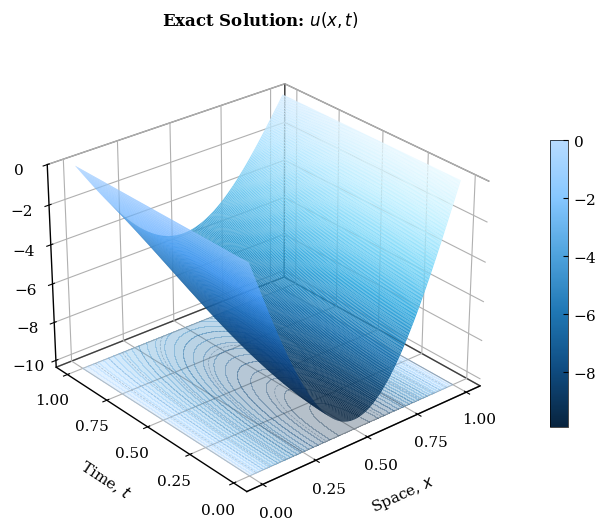

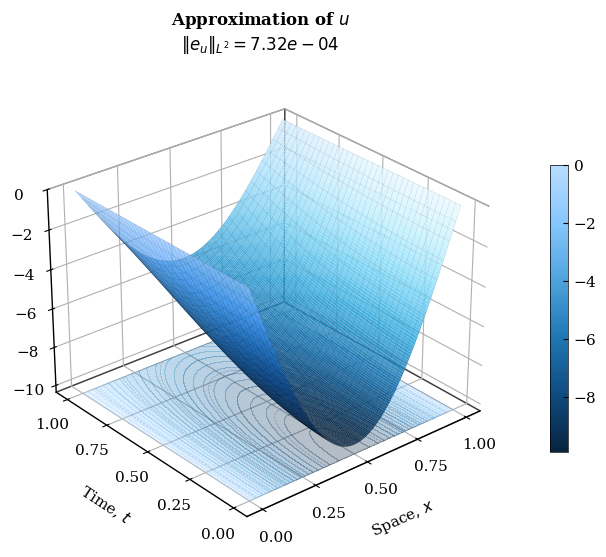

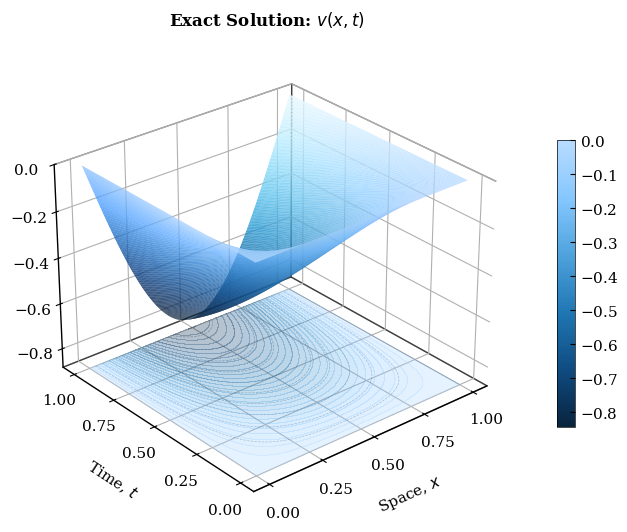

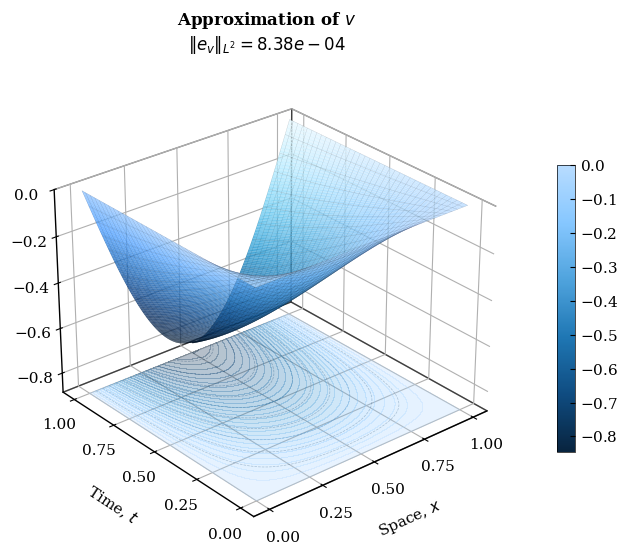

In [ ]:
# @title 3D visualization for Optimized Schwarz PINN outputs u and v
# -----------------------------------------------------------------------------
# Purpose: visualize exact and predicted u/v surfaces after Schwarz convergence.
# Inputs: trained `z1`, `z2`, exact solution helpers, and plotting grid settings.
# Outputs: 3D surface plots saved as image files.
# -----------------------------------------------------------------------------

import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size": 11,
    "axes.grid": False,
    "savefig.dpi": 450,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})
custom_blue = mcolors.LinearSegmentedColormap.from_list(
    "custom_blue_no_white",
    ["#08243f", "#0f4c81", "#1f77b4", "#4fa3dd", "#86c7ff", "#b8dcff"],
    N=256
)
@torch.no_grad()
def generate_stitched_surfaces(z1_net, z2_net, delta_val, L_val=1.0, Tmax_val=1.0, Nx_plot=180, Nt_plot=180):
    z1_net.eval()
    z2_net.eval()

    xg = torch.linspace(0.0, L_val, Nx_plot, device=device)
    tg = torch.linspace(0.0, Tmax_val, Nt_plot, device=device)
    X_mesh, T_mesh = torch.meshgrid(xg, tg, indexing="ij")
    XT_plot = torch.stack([X_mesh.reshape(-1), T_mesh.reshape(-1)], dim=1)
    out1 = z1_net(XT_plot)
    out2 = z2_net(XT_plot)
    mask = (XT_plot[:, 0:1] <= delta_val)
    Z_pred = torch.where(mask.expand_as(out1), out1, out2)
    U_pred = Z_pred[:, 0].reshape(Nx_plot, Nt_plot).cpu().numpy()
    V_pred = Z_pred[:, 1].reshape(Nx_plot, Nt_plot).cpu().numpy()
    U_ex = u_exact(XT_plot[:, 0:1], XT_plot[:, 1:2]).reshape(Nx_plot, Nt_plot).cpu().numpy()
    V_ex = v_exact(XT_plot[:, 0:1], XT_plot[:, 1:2]).reshape(Nx_plot, Nt_plot).cpu().numpy()

    Xn = X_mesh.cpu().numpy()
    Tn = T_mesh.cpu().numpy()

    return Xn, Tn, U_pred, U_ex, V_pred, V_ex
Xn, Tn, U_pred, U_ex, V_pred, V_ex = generate_stitched_surfaces(z1, z2, delta, L, Tmax)
def save_publication_surface(
    Xn, Tn, Zn, title, zlabel, filename,
    cmap=custom_blue, log_norm=False, show_wire=False,
    elev=28, azim=-130
):
    fig = plt.figure(figsize=(8.2, 6.2))
    ax = fig.add_subplot(111, projection="3d")
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor((0, 0, 0, 0.18))
    if log_norm:
        positive = Zn[Zn > 0]
        vmin = float(np.min(positive)) if positive.size else 1e-16
        vmin = max(vmin, 1e-16)
        vmax = float(np.max(Zn)) if float(np.max(Zn)) > vmin else vmin * 10.0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    ls = LightSource(azdeg=315, altdeg=38)
    rgb = ls.shade(
        Zn, cmap=cmap, norm=norm,
        vert_exag=0.9, blend_mode="soft"
    )
    ax.plot_surface(
        Xn, Tn, Zn,
        facecolors=rgb,
        rcount=Zn.shape[0], ccount=Zn.shape[1],
        linewidth=0.0,
        antialiased=True,
        shade=False,
        alpha=0.98,
        rasterized=True
    )
    if show_wire:
        ax.plot_wireframe(
            Xn, Tn, Zn,
            rstride=5, cstride=5,
            color=(0, 0, 0, 0.22),
            linewidth=0.22,
            rasterized=True
        )
    z0 = float(np.min(Zn))
    offset_z = z0 - 0.05 * abs(float(np.max(Zn)) - z0)

    ax.contourf(
        Xn, Tn, Zn,
        zdir="z", offset=offset_z,
        cmap=cmap, norm=norm,
        levels=28,
        alpha=0.30,
        rasterized=True
    )
    ax.contour(
        Xn, Tn, Zn,
        zdir="z", offset=offset_z,
        levels=10,
        colors=[(0.05, 0.20, 0.35, 0.35)],
        linewidths=0.5
    )
    ax.set_zlim(offset_z, float(np.max(Zn)))
    ax.set_xlabel(r"Space, $x$", labelpad=10)
    ax.set_ylabel(r"Time, $t$", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=8)
    ax.set_title(title, pad=14, fontsize=12, fontweight="bold")
    ax.view_init(elev=elev, azim=azim)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.zaxis.set_major_locator(mticker.MaxNLocator(5))
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(Zn)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.60, aspect=16, pad=0.08)
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    cbar.outline.set_linewidth(0.5)

    plt.savefig(filename, bbox_inches="tight")
    plt.show()
save_publication_surface(
    Xn, Tn, U_ex,
    title=r"Exact Solution: $u(x,t)$",
    zlabel=r"$u_{\mathrm{exact}}$",
    filename="ex3_u_exact_blue.png",
    show_wire=False
)
err_u_l2 = np.sqrt(np.mean((U_pred - U_ex)**2))
save_publication_surface(
    Xn, Tn, U_pred,
    title=r"Approximation of $u$" + "\n" + rf"$\|e_u\|_{{L^2}}={err_u_l2:.2e}$",
    zlabel=r"$u_{\mathrm{pred}}$",
    filename="ex3_u_pred_blue.png",
    show_wire=True
)
save_publication_surface(
    Xn, Tn, V_ex,
    title=r"Exact Solution: $v(x,t)$",
    zlabel=r"$v_{\mathrm{exact}}$",
    filename="ex3_v_exact_blue.png",
    show_wire=False
)
err_v_l2 = np.sqrt(np.mean((V_pred - V_ex)**2))
save_publication_surface(
    Xn, Tn, V_pred,
    title=r"Approximation of $v$" + "\n" + rf"$\|e_v\|_{{L^2}}={err_v_l2:.2e}$", # Fixed title from u to v
    zlabel=r"$v_{\mathrm{pred}}$",
    filename="ex3_v_pred_blue.png",
    show_wire=True
)


## Reconstruct Displacement `y`

This cell trains a separate `YModel` so that `y_t` matches `v` and `y_xx` matches `u`, using the trained Schwarz models as supervision.


In [ ]:
# @title Reconstruct displacement y using u and v
# -----------------------------------------------------------------------------
# Purpose: reconstruct the displacement y from trained u/v models.
# Inputs: trained z-model checkpoints and collocation points from the Schwarz run.
# Outputs: trained `Y` model, best checkpoint, and reconstruction diagnostics.
# -----------------------------------------------------------------------------

#===========================================================================================================Y_pinn======================================================
BEST_Z1_CKPT = "checkpoints/final_last_z1.pt"
BEST_Z2_CKPT = "checkpoints/final_last_z2.pt"
BEST_Y_CKPT  = "/content/Y_pinn_best.pt"   # where to save best Y

# Exact solution (PyTorch, tensor-safe)
def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

# must match training architecture exactly
class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)  # [N,2] = [û, v̂]
        # hard BC/IC wrapper for (u,v)
        x = xt[:,0:1]; t = xt[:,1:2]
        Sx = x*(1.0 - x)                  # zero at x=0,1
        u0 = -pi**2 * torch.sin(pi * x)   # u(x,0)
        v0 = torch.zeros_like(x)          # v(x,0)=0
        u = u0 + Sx * t * h[:,0:1]
        v = v0 + Sx * t * h[:,1:2]
        return torch.cat([u,v], dim=1)

# instantiate and load best checkpoints (override any existing z1,z2)
z1 = Net().to(device)
z2 = Net().to(device)
z1.load_state_dict(torch.load(BEST_Z1_CKPT, map_location=device))
z2.load_state_dict(torch.load(BEST_Z2_CKPT, map_location=device))
z1.eval(); z2.eval()
print("Loaded best z1/z2 from checkpoints.")
L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
print(f"[z1/z2 checkpoints] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

# ---- stitcher: get [u,v] from trained z1/z2 at arbitrary (x,t) ----
@torch.no_grad()
def uv_from_subdomains(xt: torch.Tensor) -> torch.Tensor:
    """
    xt: [N,2] with cols (x,t). Returns [N,2] = [u,v],
    using z1 on x<=delta and z2 on x>delta.
    """
    z1.eval(); z2.eval()
    out1 = z1(xt)
    out2 = z2(xt)
    mask = (xt[:, 0:1] <= delta).expand_as(out1)
    return torch.where(mask, out1, out2)

# ---- Y-model with HARD BC/IC: y(x,t) = sin(pi x) C(t) + [x^3(1-x)^3] t^2 F(x,t) ----
class Tiny1D(nn.Module):
    """C_hat(t)"""
    def __init__(self, width=24, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """F(x,t)"""
    def __init__(self, width=48, depth=4):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        # xavier init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    HARD BC/IC ansatz:
      y(x,t) = sin(pi x) * C(t) + [x^3 (1-x)^3] * t^2 * F(x,t),
      with C(t) = 1 + t^2 * C_hat(t).
    """
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=24, depth=5)
        self.F     = Tiny2D(width=48, depth=4)
    def forward(self, xt):
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        C  = 1.0 + (t**2) * self.C_hat(t)
        Sx = (x**3) * ((1.0 - x)**3)
        y  = torch.sin(pi * x) * C + Sx * (t**2) * self.F(xt)
        return y

Y = YModel().to(device)

# ---- autograd helpers: y_t and y_xx on arbitrary points ----
def y_t_and_y_xx(Y_net: nn.Module, xt: torch.Tensor):
    """
    xt must require_grad. Returns y_t, y_xx, y at those points.
    """
    y  = Y_net(xt)                                   # [N,1]
    gy = torch.autograd.grad(y, xt, torch.ones_like(y),
                             create_graph=True, retain_graph=True)[0]
    y_t = gy[:, 1:2]
    y_x = gy[:, 0:1]
    g2  = torch.autograd.grad(y_x, xt, torch.ones_like(y_x),
                              create_graph=True, retain_graph=True)[0]
    y_xx = g2[:, 0:1]
    return y_t, y_xx, y

# ----------------- training set for Y: interior + interface -----------------
# xt_int1, xt_int2, xt_if_all come from the previous DDM cell
# Ω1 interior (60) + Ω2 interior (61) + interface (100) = 221 points
xt_train_Y = torch.cat(
    [xt_int1.detach(), xt_int2.detach(), xt_if_all.detach()], dim=0
).to(device)

# ----------------- validation grid for model selection -----------------
xv = torch.linspace(0.0, 1.0, 100, device=device)
tv = torch.linspace(0.0, 1.0, 100, device=device)
Xv, Tv = torch.meshgrid(xv, tv, indexing="ij")
xt_val = torch.stack([Xv.reshape(-1), Tv.reshape(-1)], dim=1)   # [81*81, 2]

@torch.no_grad()
def L2_y_on_val(Y_net):
    y_pred = Y_net(xt_val)
    y_true = y_exact(xt_val[:,0:1], xt_val[:,1:2])
    e = y_pred - y_true
    return float(torch.max(torch.abs(e)))   # now L_max*




# ----------------- loss: match (y_t, y_xx) to (v, u) from z-nets -----------------
p_exp = 2
w_u, w_v = 1.0, 1.0

def make_grad_copy(xt: torch.Tensor):
    return xt.detach().clone().requires_grad_(True)

def loss_components_Y():
    xtg = make_grad_copy(xt_train_Y)
    with torch.no_grad():
        uv   = uv_from_subdomains(xt_train_Y)  # [N,2]
        u_tr = uv[:, 0:1]
        v_tr = uv[:, 1:2]
    y_t, y_xx, _ = y_t_and_y_xx(Y, xtg)
    L_u = (y_xx - u_tr).abs().pow(p_exp).mean()
    L_v = (y_t  - v_tr).abs().pow(p_exp).mean()
    loss = w_u * L_u + w_v * L_v
    return loss, (L_u.item(), L_v.item())

# ----------------- train (Adam ONLY, select best by L2(y) on validation) -----
optA   = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 25000

best_loss = float('inf')      # just for monitoring
best_val  = float('inf')      # selection criterion
best_st   = None

for it in range(1, E_ADAM+1):
    optA.zero_grad()
    loss, (Lu, Lv) = loss_components_Y()
    loss.backward()
    optA.step()

    if loss.item() < best_loss:
        best_loss = loss.item()

    # check validation every 200 iters (you can change this)
    if it % 200 == 0 or it == 1:
        L2_val = L2_y_on_val(Y)
        if L2_val < best_val:
            best_val = L2_val
            best_st  = {k: v.detach().clone() for k, v in Y.state_dict().items()}
        print(f"[Y-Adam {it:5d}] loss={loss.item():.3e} | Lu={Lu:.2e} Lv={Lv:.2e} | L2_val(y)={L2_val:.3e}")

# load best (lowest L2(y) on validation) and SAVE it
if best_st is not None:
    Y.load_state_dict(best_st)
    print(f"Best validation L2(y) = {best_val:.3e}")

torch.save(Y.state_dict(), BEST_Y_CKPT)
print(f"Saved best Y-PINN (Adam only, best on validation) to: {BEST_Y_CKPT}")

Y.eval()
print("Y-PINN trained on interior + interface samples (Adam only, N=", xt_train_Y.shape[0], ").")

# ----------------- diagnostics: error at the TRAINING points -----------------
@torch.no_grad()
def errors_y_on_training(Y_net: nn.Module, xt_train: torch.Tensor):
    y_pred = Y_net(xt_train)
    y_true = y_exact(xt_train[:, 0:1], xt_train[:, 1:2])
    e = y_pred - y_true
    L2  = float(torch.sqrt(torch.mean(e**2)))
    Linf= float(torch.max(torch.abs(e)))
    return L2, Linf

L2y_tr, Linfy_tr = errors_y_on_training(Y, xt_train_Y)
print(f"[Y @ training points] N={xt_train_Y.shape[0]}  L2(y)={L2y_tr:.3e}  Linf(y)={Linfy_tr:.3e}")

# (Optional) quick slice like Table-1: y at t*=0.20 for a few x's
@torch.no_grad()
def print_slice_Y(t_star=0.20, xs=(0.1,0.2,0.3,0.4,0.5)):
    XT = torch.tensor([[x, t_star] for x in xs], device=device, dtype=torch.float32)
    y_p = Y(XT).squeeze(1); y_e = y_exact(XT[:,0:1], XT[:,1:2]).squeeze(1)
    print(f"\n[Y slice at t={t_star:.2f}]")
    for xq, yp, ye in zip(xs, y_p.tolist(), y_e.tolist()):
        print(f"x={xq:.2f}:  exact={ye: .6e}  Y={yp: .6e}  err={yp-ye: .2e}")

print_slice_Y(0.20)


Loaded best z1/z2 from checkpoints.
[z1/z2 checkpoints] L2(u)=7.211e-04  L2(v)=8.034e-04
[Y-Adam     1] loss=2.788e+00 | Lu=2.63e+00 Lv=1.62e-01 | L2_val(y)=3.811e-01
[Y-Adam   200] loss=1.290e-03 | Lu=7.72e-04 Lv=5.17e-04 | L2_val(y)=8.794e-03
[Y-Adam   400] loss=1.750e-04 | Lu=1.22e-04 Lv=5.31e-05 | L2_val(y)=2.562e-03
[Y-Adam   600] loss=3.632e-05 | Lu=2.33e-05 Lv=1.30e-05 | L2_val(y)=9.062e-04
[Y-Adam   800] loss=1.584e-05 | Lu=7.83e-06 Lv=8.01e-06 | L2_val(y)=5.635e-04
[Y-Adam  1000] loss=1.067e-05 | Lu=4.57e-06 Lv=6.10e-06 | L2_val(y)=4.423e-04
[Y-Adam  1200] loss=8.703e-06 | Lu=3.65e-06 Lv=5.05e-06 | L2_val(y)=3.847e-04
[Y-Adam  1400] loss=7.467e-06 | Lu=3.12e-06 Lv=4.34e-06 | L2_val(y)=3.577e-04
[Y-Adam  1600] loss=6.458e-06 | Lu=2.66e-06 Lv=3.80e-06 | L2_val(y)=3.309e-04
[Y-Adam  1800] loss=5.584e-06 | Lu=2.23e-06 Lv=3.35e-06 | L2_val(y)=3.052e-04
[Y-Adam  2000] loss=4.830e-06 | Lu=1.87e-06 Lv=2.96e-06 | L2_val(y)=2.810e-04
[Y-Adam  2200] loss=4.190e-06 | Lu=1.57e-06 Lv=2.62e-

## Plot Exact vs Approximated Displacement

This cell evaluates the trained displacement model on a dense grid and saves publication-style exact/predicted/error surfaces.


/tmp/ipython-input-768/3940116113.py:155: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contourf(


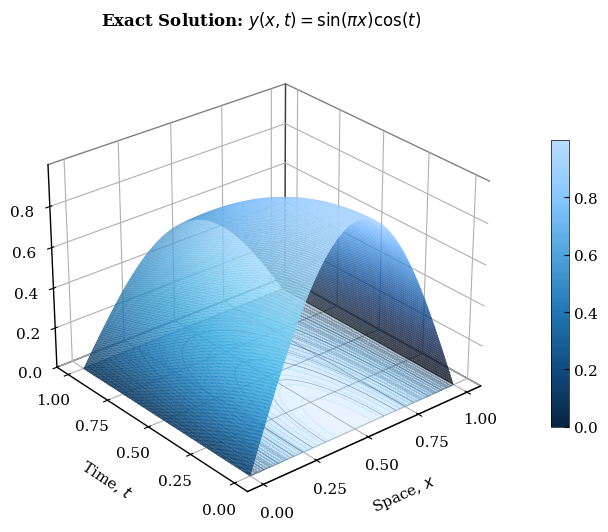

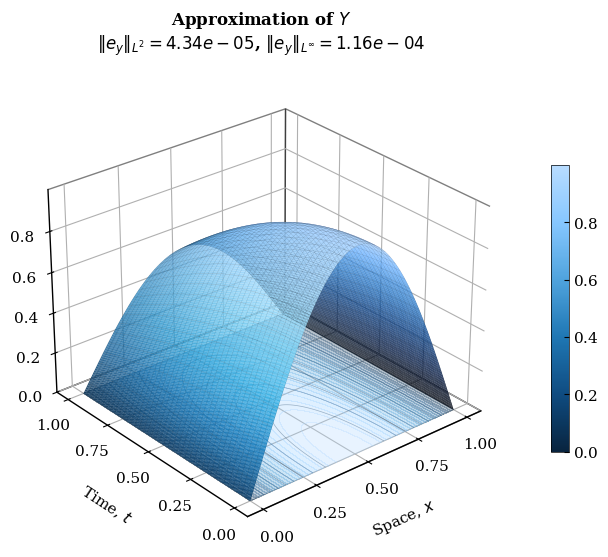

In [ ]:
# @title Plot exact vs approximated displacement y
# -----------------------------------------------------------------------------
# Purpose: compare exact and approximated displacement y on a dense grid.
# Inputs: trained `Y` model or a saved `Y` checkpoint.
# Outputs: exact, predicted, and error surface figures.
# -----------------------------------------------------------------------------


import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from math import pi

# =====================================================================================
# ASSUMES you already have:
#   - device
#   - Y (trained YModel)  (or load it by setting LOAD_FROM_CKPT=True)
#   - y_exact(x,t)  (your exact function)
# =====================================================================================

LOAD_FROM_CKPT = False
BEST_Y_CKPT = "/content/Y_pinn_best.pt"

# --- If loading: rebuild YModel EXACTLY as in your training cell ---
class Tiny1D(torch.nn.Module):
    def __init__(self, width=24, depth=5):
        super().__init__()
        layers = [torch.nn.Linear(1, width), torch.nn.Tanh()]
        for _ in range(depth - 1):
            layers += [torch.nn.Linear(width, width), torch.nn.Tanh()]
        layers += [torch.nn.Linear(width, 1)]
        self.net = torch.nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(torch.nn.Module):
    def __init__(self, width=48, depth=4):
        super().__init__()
        self.act = torch.nn.Tanh()
        self.inp = torch.nn.Linear(2, width)
        self.hid = torch.nn.ModuleList([torch.nn.Linear(width, width) for _ in range(depth)])
        self.out = torch.nn.Linear(width, 1)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=24, depth=5)
        self.F     = Tiny2D(width=48, depth=4)
    def forward(self, xt):
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        C  = 1.0 + (t**2) * self.C_hat(t)
        Sx = (x**3) * ((1.0 - x)**3)
        y  = torch.sin(pi * x) * C + Sx * (t**2) * self.F(xt)
        return y

if LOAD_FROM_CKPT:
    Y = YModel().to(device)
    Y.load_state_dict(torch.load(BEST_Y_CKPT, map_location=device))
    Y.eval()
    print(f"Loaded Y from: {BEST_Y_CKPT}")

# --- Matplotlib style ---
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size": 11,
    "axes.grid": False,
    "savefig.dpi": 450,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# --- Blue colormap WITHOUT white ---
custom_blue = mcolors.LinearSegmentedColormap.from_list(
    "custom_blue_no_white",
    ["#08243f", "#0f4c81", "#1f77b4", "#4fa3dd", "#86c7ff", "#b8dcff"],
    N=256
)

# --- Dense-grid error (to report on the plot) ---
@torch.no_grad()
def compute_global_errors(Y_net, xmin=0.0, xmax=1.0, tmin=0.0, tmax=1.0,
                          Nx=800, Nt=800, t_chunks=80):
    x = torch.linspace(xmin, xmax, Nx, device=device)
    t = torch.linspace(tmin, tmax, Nt, device=device)
    sum_sq, npts, linf = 0.0, 0, 0.0
    for j in range(0, Nt, t_chunks):
        tj = t[j:j+t_chunks]
        Xg, Tg = torch.meshgrid(x, tj, indexing="ij")
        XT = torch.stack([Xg.reshape(-1), Tg.reshape(-1)], dim=1)
        yp = Y_net(XT)
        ye = y_exact(XT[:,0:1], XT[:,1:2])
        e  = (yp - ye).flatten()
        sum_sq += torch.sum(e*e).item()
        npts   += e.numel()
        linf    = max(linf, torch.max(torch.abs(e)).item())
    return np.sqrt(sum_sq / npts), linf

# --- Shaded 3D surface plotter (no white lighting) ---
def plot_surface_blue_shaded(
    Xn, Tn, Zn, title, zlabel, filename,
    cmap=custom_blue, log_norm=False, show_wire=False,
    elev=28, azim=-130
):
    fig = plt.figure(figsize=(8.2, 6.2))
    ax = fig.add_subplot(111, projection="3d")

    # panes
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor((0, 0, 0, 0.18))

    # norm
    if log_norm:
        positive = Zn[Zn > 0]
        vmin = float(np.min(positive)) if positive.size else 1e-16
        vmin = max(vmin, 1e-16)
        vmax = float(np.max(Zn)) if float(np.max(Zn)) > vmin else vmin * 10.0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None

    # shade -> facecolors
    ls = LightSource(azdeg=315, altdeg=38)
    rgb = ls.shade(Zn, cmap=cmap, norm=norm, vert_exag=0.9, blend_mode="soft")

    ax.plot_surface(
        Xn, Tn, Zn,
        facecolors=rgb,
        rcount=Zn.shape[0], ccount=Zn.shape[1],
        linewidth=0.0,
        antialiased=True,
        shade=False,     # no white-ish default shading
        alpha=0.98,
        rasterized=True
    )

    if show_wire:
        ax.plot_wireframe(
            Xn, Tn, Zn,
            rstride=5, cstride=5,
            color=(0, 0, 0, 0.22),
            linewidth=0.22,
            rasterized=True
        )

    # base projection
    z0 = float(np.min(Zn))
    ax.contourf(
        Xn, Tn, Zn,
        zdir="z", offset=z0,
        cmap=cmap, norm=norm,
        levels=28,
        alpha=0.30,
        rasterized=True
    )
    ax.contour(
        Xn, Tn, Zn,
        zdir="z", offset=z0,
        levels=10,
        colors=[(0.05, 0.20, 0.35, 0.35)],
        linewidths=0.5
    )

    ax.set_zlim(z0, float(np.max(Zn)))

    ax.set_xlabel(r"Space, $x$", labelpad=10)
    ax.set_ylabel(r"Time, $t$", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=8)
    ax.set_title(title, pad=14, fontsize=12, fontweight="bold")
    ax.view_init(elev=elev, azim=azim)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.zaxis.set_major_locator(mticker.MaxNLocator(5))

    # colorbar (ScalarMappable)
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(Zn)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.60, aspect=16, pad=0.08)
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    cbar.outline.set_linewidth(0.5)

    plt.savefig(filename, bbox_inches="tight")
    plt.show()

# --- Evaluate on plotting grid ---
Y.eval()
xmin, xmax = 0.0, 1.0
tmin, tmax = 0.0, 1.0

Nx_plot, Nt_plot = 200, 200
xg = torch.linspace(xmin, xmax, Nx_plot, device=device)
tg = torch.linspace(tmin, tmax, Nt_plot, device=device)
X_mesh, T_mesh = torch.meshgrid(xg, tg, indexing="ij")
XT = torch.stack([X_mesh.reshape(-1), T_mesh.reshape(-1)], dim=1)

with torch.no_grad():
    Y_pred = Y(XT).reshape(Nx_plot, Nt_plot).cpu().numpy()
    Y_ex   = y_exact(X_mesh.reshape(-1,1), T_mesh.reshape(-1,1)).reshape(Nx_plot, Nt_plot).cpu().numpy()

Xn, Tn = X_mesh.cpu().numpy(), T_mesh.cpu().numpy()

# --- Global metrics (reported on approximated plot) ---
L2g, Linfg = compute_global_errors(Y, xmin, xmax, tmin, tmax)

# --- EXACT plot ---
plot_surface_blue_shaded(
    Xn, Tn, Y_ex,
    title=r"Exact Solution: $y(x,t)=\sin(\pi x)\cos(t)$",
    zlabel=r"$y_{\mathrm{exact}}$",
    filename="y_exact_blue.png",
    cmap=custom_blue,
    show_wire=False
)

# --- APPROX plot ---
title_pred = r"Approximation of $Y$" + "\n" + rf"$\|e_y\|_{{L^2}}={L2g:.2e}$, $\|e_y\|_{{L^\infty}}={Linfg:.2e}$"
plot_surface_blue_shaded(
    Xn, Tn, Y_pred,
    title=title_pred,
    zlabel=r"$y_{\mathrm{pred}}$",
    filename="y_pred_blue.png",
    cmap=custom_blue,
    show_wire=True
)


## Seed 123 Training Run

Same experiment as seed `1234`, repeated with seed `123` for robustness checks.


In [ ]:
# @title Example 1: Optimized Schwarz PINN, seed 123
# -----------------------------------------------------------------------------
# Purpose: train two PINNs on the overlapping subdomains and run the global-in-time Schwarz iteration.
# Inputs: manufactured solution, domain settings, collocation points, and the selected random seed.
# Outputs: trained z1/z2 models, checkpoints, convergence logs, and L2/interface-jump diagnostics.
# -----------------------------------------------------------------------------

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time
# ---------------- reproducibility and runtime device ----------------
torch.manual_seed(123); np.random.seed(123)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()
os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)
# ---------------- problem setup ----------------
L, delta = 1.0, 0.5
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True
# ---------- manufactured solution for u, v, and forcing ----------
def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)
# ---------- sampling and autograd helpers ----------
def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]
# ---------- complex DtN kernels and time-convolution matrices ----------
def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-2/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a
    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)
    spec = sign * (k * c / s)
    limit = 5.0
    spec = np.clip(np.abs(spec), 0, limit) * np.exp(1j * np.angle(spec))
    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt
Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)
# ---------- interface operator in real 2x2 form ----------
def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out
def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()
# ---------- PINN architecture with hard initial/boundary conditions ----------
class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)
        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]
        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net
# ---------- loss weights ----------
w_pde  = 1.0
w_if   = 1.0
p_exp  = 2
# ---------- collocation and interface grids ----------
Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)
t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)
z1, z2 = new_model(1), new_model(2)

# ---------- validation and plotting helpers ----------
def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))
@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)
    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):

    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}
# ---------- warm-start training on each subdomain ----------
def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()
def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net
def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2
t_decomp_total0 = _now()
# ---------------- global-in-time Schwarz iteration ----------------
t_warm = 0.0
iter_times = []
if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")
    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)
    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 25.026 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 21.627 s
r1=3.371e-01  r2=6.920e+00  (max=6.920e+00)
[iter 1] L2(u)=6.921e-01  L2(v)=4.767e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.222e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 21.554 s
r1=4.880e+00  r2=2.626e-01  (max=4.880e+00)
[iter 2] L2(u)=2.473e-01  L2(v)=5.459e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=8.580e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.984 s
r1=2.117e-01  r2=3.421e+00  (max=3.421e+00)
[iter 3] L2(u)=2.813e-01  L2(v)=3.165e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.976e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 21.316 s
r1=2.381e+00  r2=1.715e-01  (max=2.381e+00)
[iter 4] L2(u)=2.742e-01  L2(v)=1.138e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=4.148e-01

=== Schwarz iteration 5 (global in time, parallel J

## Seed 12 Training Run

Same optimized Schwarz PINN experiment, repeated with seed `12`.


In [ ]:
# @title Example 1: Optimized Schwarz PINN, seed 12
# -----------------------------------------------------------------------------
# Purpose: train two PINNs on the overlapping subdomains and run the global-in-time Schwarz iteration.
# Inputs: manufactured solution, domain settings, collocation points, and the selected random seed.
# Outputs: trained z1/z2 models, checkpoints, convergence logs, and L2/interface-jump diagnostics.
# -----------------------------------------------------------------------------

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

# ---------------- configuration ----------------
# ---------------- reproducibility and runtime device ----------------
torch.manual_seed(12); np.random.seed(12)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()
os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

# domain & time grid ----------------------------------------------------------
# ---------------- problem setup ----------------
L, delta = 1.0, 0.5
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

# ---------- manufactured solution (Example 1) --------------------------------
# ---------- manufactured solution for u, v, and forcing ----------
def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)      # u = y_xx
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)   # v = y_t
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

# ---------- helpers: sampling, grads, etc. -----------------------------------
# ---------- sampling and autograd helpers ----------
def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

# ---------- complex DtN kernels (Re/Im) --------------------------------------
# ---------- complex DtN kernels and time-convolution matrices ----------
def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-2/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)
    spec = sign * (k * c / s)
    limit = 2.0
    spec = np.clip(np.abs(spec), 0, limit) * np.exp(1j * np.angle(spec))
    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt
Ka1, Kb1 = build_complex_kernels(L - delta, +1)   # Λ1*
Ka2, Kb2 = build_complex_kernels(delta,     -1)   # Λ2*
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)
# ---------- interface operator (complex DtN in 2x2 real form) ----------------
# ---------- interface operator in real 2x2 form ----------
def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

# ---------- PINN -------------------------------------------------------------
# ---------- PINN architecture with hard initial/boundary conditions ----------
class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

# ---------- loss weights -----------------------------------------------------
w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

# ---------------- collocation sets (interior only) ---------------------------
# ---------- collocation and interface grids ----------
Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

# -------------- interface time grid (ALL times) ------------------------------
t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)  # [Nt,2]

# ---------------- models -----------------------------------------------------
z1, z2 = new_model(1), new_model(2)

# ---------- validation and plotting helpers ----------
def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

# (plot_piecewise_at_t)
@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)
    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)
    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)
    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):

    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}
# ---------- warm-start training on each subdomain ----------
def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()
def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

# ---------- proper interface residual (complex DtN) --------------------------
def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

# ---------------- Global-in-time Schwarz iteration ---------------------------
t_decomp_total0 = _now()
# ---------------- global-in-time Schwarz iteration ----------------
t_warm = 0.0
iter_times = []
if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")
    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)
    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:                     # <-- NEW
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 24.582 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 16.922 s
r1=5.837e-01  r2=5.632e+00  (max=5.632e+00)
[iter 1] L2(u)=7.306e-01  L2(v)=4.314e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.868e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 17.580 s
r1=3.225e+00  r2=3.661e-01  (max=3.225e+00)
[iter 2] L2(u)=2.325e-01  L2(v)=4.300e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=1.054e+00

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 16.709 s
r1=2.249e-01  r2=1.793e+00  (max=1.793e+00)
[iter 3] L2(u)=2.462e-01  L2(v)=1.206e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.791e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.719 s
r1=9.689e-01  r2=1.540e-01  (max=9.689e-01)
[iter 4] L2(u)=6.018e-02  L2(v)=1.375e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=3.140e-01

=== Schwarz iteration 5 (global in time, parallel J

## Seed 1 Training Run

Same optimized Schwarz PINN experiment, repeated with seed `1`.


In [ ]:
# @title Example 1: Optimized Schwarz PINN, seed 1
# -----------------------------------------------------------------------------
# Purpose: train two PINNs on the overlapping subdomains and run the global-in-time Schwarz iteration.
# Inputs: manufactured solution, domain settings, collocation points, and the selected random seed.
# Outputs: trained z1/z2 models, checkpoints, convergence logs, and L2/interface-jump diagnostics.
# -----------------------------------------------------------------------------

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time
# ---------------- configuration ----------------
# ---------------- reproducibility and runtime device ----------------
torch.manual_seed(1); np.random.seed(1)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()
os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)
# domain & time grid ----------------------------------------------------------
# ---------------- problem setup ----------------
L, delta = 1.0, 0.5
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)           # 100
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True
# ---------- manufactured solution (Example 1) --------------------------------
# ---------- manufactured solution for u, v, and forcing ----------
def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)      # u = y_xx
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)   # v = y_t
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)
# ---------- helpers: sampling, grads, etc. -----------------------------------
# ---------- sampling and autograd helpers ----------
def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

# ---------- complex DtN kernels (Re/Im) --------------------------------------
# ---------- complex DtN kernels and time-convolution matrices ----------
def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-2/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a
    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)
    spec = sign * (k * c / s)
    limit = 4.0
    spec = np.clip(np.abs(spec), 0, limit) * np.exp(1j * np.angle(spec))
    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt
Ka1, Kb1 = build_complex_kernels(L - delta, +1)   # Λ1*
Ka2, Kb2 = build_complex_kernels(delta,     -1)   # Λ2*
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)
# ---------- interface operator (complex DtN in 2x2 real form) ----------------
# ---------- interface operator in real 2x2 form ----------
def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out
def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()
# ---------- PINN -------------------------------------------------------------
# ---------- PINN architecture with hard initial/boundary conditions ----------
class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)
        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]
        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat
        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

# ---------- loss weights -----------------------------------------------------
w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

# ---------------- collocation sets (interior only) ---------------------------
# ---------- collocation and interface grids ----------
Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

# -------------- interface time grid (ALL times) ------------------------------
t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)
# ---------------- models -----------------------------------------------------
z1, z2 = new_model(1), new_model(2)
# ---------- validation and plotting helpers ----------
def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

# (plot_piecewise_at_t)
@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1
    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)
    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)
    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)
    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

# ---------------- warm-start (optional) --------------------------------------
# ---------- warm-start training on each subdomain ----------
def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

# ---------------- fits (complex DtN at the interface) ------------------------
def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net
def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

# ---------------- Global-in-time Schwarz iteration ---------------------------
t_decomp_total0 = _now()
# ---------------- global-in-time Schwarz iteration ----------------
t_warm = 0.0
iter_times = []
if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")
    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)
    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 7.227 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.707 s
r1=1.001e+00  r2=6.641e+00  (max=6.641e+00)
[iter 1] L2(u)=7.655e-01  L2(v)=4.419e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.345e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 16.035 s
r1=4.616e+00  r2=7.498e-01  (max=4.616e+00)
[iter 2] L2(u)=2.397e-01  L2(v)=5.668e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=9.334e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 15.676 s
r1=5.241e-01  r2=3.190e+00  (max=3.190e+00)
[iter 3] L2(u)=3.008e-01  L2(v)=3.001e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=6.259e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 16.308 s
r1=2.078e+00  r2=3.559e-01  (max=2.078e+00)
[iter 4] L2(u)=2.640e-01  L2(v)=1.156e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=3.981e-01

=== Schwarz iteration 5 (global in time, parallel Ja

## Stored Logs for All Seeds

This cell stores the raw console logs in `LOG_TEXT_BY_SEED` so later analysis cells can parse convergence statistics without rerunning training.


In [ ]:
# @title Optimized Schwarz PINN logs for all seeds (1234, 123, 12, 1)
# -----------------------------------------------------------------------------
# Purpose: store raw logs from each seed for reproducible post-processing.
# Inputs: console outputs copied from seed-specific training runs.
# Outputs: `LOG_TEXT_BY_SEED`, used by the statistics cells.
# -----------------------------------------------------------------------------

SEED_LOGS = {
# "seed1":


# @title
#LOG_TEXT_BY_SEED = {
1:   r"""Device : cpu
[Timing] Warm-start total (parallel): 7.227 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.707 s
r1=1.001e+00  r2=6.641e+00  (max=6.641e+00)
[iter 1] L2(u)=7.655e-01  L2(v)=4.419e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.345e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 16.035 s
r1=4.616e+00  r2=7.498e-01  (max=4.616e+00)
[iter 2] L2(u)=2.397e-01  L2(v)=5.668e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=9.334e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 15.676 s
r1=5.241e-01  r2=3.190e+00  (max=3.190e+00)
[iter 3] L2(u)=3.008e-01  L2(v)=3.001e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=6.259e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 16.308 s
r1=2.078e+00  r2=3.559e-01  (max=2.078e+00)
[iter 4] L2(u)=2.640e-01  L2(v)=1.156e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=3.981e-01

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 15.732 s
r1=2.407e-01  r2=1.381e+00  (max=1.381e+00)
[iter 5] L2(u)=1.030e-01  L2(v)=1.666e-01
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=2.573e-01

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 15.433 s
r1=9.119e-01  r2=1.720e-01  (max=9.119e-01)
[iter 6] L2(u)=7.315e-02  L2(v)=1.117e-01
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=1.673e-01

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 15.677 s
r1=1.239e-01  r2=6.023e-01  (max=6.023e-01)
[iter 7] L2(u)=8.121e-02  L2(v)=3.962e-02
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=1.071e-01

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 15.544 s
r1=4.019e-01  r2=9.828e-02  (max=4.019e-01)
[iter 8] L2(u)=4.551e-02  L2(v)=4.070e-02
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=6.948e-02

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 15.635 s
r1=8.107e-02  r2=2.628e-01  (max=2.628e-01)
[iter 9] L2(u)=1.674e-02  L2(v)=3.782e-02
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=4.380e-02

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 15.277 s
r1=1.726e-01  r2=7.811e-02  (max=1.726e-01)
[iter 10] L2(u)=2.216e-02  L2(v)=1.831e-02
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=3.096e-02

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 15.824 s
r1=7.258e-02  r2=1.175e-01  (max=1.175e-01)
[iter 11] L2(u)=1.875e-02  L2(v)=8.335e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=2.469e-02

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 15.231 s
r1=8.621e-02  r2=6.770e-02  (max=8.621e-02)
[iter 12] L2(u)=7.130e-03  L2(v)=1.379e-02
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=2.236e-02

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 14.753 s
r1=6.122e-02  r2=6.758e-02  (max=6.758e-02)
[iter 13] L2(u)=6.923e-03  L2(v)=1.032e-02
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=2.126e-02

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 16.200 s
r1=5.822e-02  r2=5.302e-02  (max=5.822e-02)
[iter 14] L2(u)=9.626e-03  L2(v)=3.648e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.003e-02

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 14.508 s
r1=4.485e-02  r2=5.010e-02  (max=5.010e-02)
[iter 15] L2(u)=5.836e-03  L2(v)=5.838e-03
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=1.758e-02

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 12.473 s
r1=4.187e-02  r2=3.612e-02  (max=4.187e-02)
[iter 16] L2(u)=2.613e-03  L2(v)=5.998e-03
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.487e-02

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 11.714 s
r1=2.935e-02  r2=3.441e-02  (max=3.441e-02)
[iter 17] L2(u)=4.136e-03  L2(v)=3.134e-03
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.251e-02

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 9.953 s
r1=2.757e-02  r2=2.356e-02  (max=2.757e-02)
[iter 18] L2(u)=3.513e-03  L2(v)=1.984e-03
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.014e-02

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 8.255 s
r1=1.805e-02  r2=2.165e-02  (max=2.165e-02)
[iter 19] L2(u)=1.724e-03  L2(v)=2.520e-03
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=7.921e-03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.738 s
r1=1.663e-02  r2=1.385e-02  (max=1.663e-02)
[iter 20] L2(u)=1.276e-03  L2(v)=1.848e-03
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=6.016e-03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 10.273 s
r1=1.052e-02  r2=1.202e-02  (max=1.202e-02)
[iter 21] L2(u)=1.467e-03  L2(v)=8.049e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=4.527e-03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 9.013 s
r1=9.210e-03  r2=7.816e-03  (max=9.210e-03)
[iter 22] L2(u)=9.702e-04  L2(v)=7.556e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=3.401e-03

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 8.191 s
r1=5.920e-03  r2=6.615e-03  (max=6.615e-03)
[iter 23] L2(u)=4.295e-04  L2(v)=8.061e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=2.511e-03

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 7.209 s
r1=4.843e-03  r2=4.438e-03  (max=4.843e-03)
[iter 24] L2(u)=5.338e-04  L2(v)=4.581e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=1.886e-03

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 8.039 s
r1=3.564e-03  r2=3.472e-03  (max=3.564e-03)
[iter 25] L2(u)=4.706e-04  L2(v)=2.663e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=1.396e-03

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 8.064 s
r1=2.620e-03  r2=2.725e-03  (max=2.725e-03)
[iter 26] L2(u)=2.805e-04  L2(v)=3.386e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=9.922e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 7.144 s
r1=2.021e-03  r2=2.239e-03  (max=2.239e-03)
[iter 27] L2(u)=2.689e-04  L2(v)=2.602e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=8.233e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 7.814 s
r1=1.922e-03  r2=1.810e-03  (max=1.922e-03)
[iter 28] L2(u)=2.718e-04  L2(v)=1.672e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=6.714e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.368 s
r1=1.471e-03  r2=1.651e-03  (max=1.651e-03)
[iter 29] L2(u)=2.121e-04  L2(v)=2.024e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=5.296e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 7.892 s
r1=1.513e-03  r2=1.468e-03  (max=1.513e-03)
[iter 30] L2(u)=2.473e-04  L2(v)=1.721e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=5.190e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 7.333 s
r1=1.628e-03  r2=1.508e-03  (max=1.628e-03)
[iter 31] L2(u)=2.714e-04  L2(v)=1.855e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=5.743e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 8.496 s
r1=1.468e-03  r2=1.811e-03  (max=1.811e-03)
[iter 32] L2(u)=2.529e-04  L2(v)=2.541e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=5.896e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 8.385 s
r1=1.964e-03  r2=1.698e-03  (max=1.964e-03)
[iter 33] L2(u)=2.775e-04  L2(v)=2.102e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=7.130e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 7.188 s
r1=1.860e-03  r2=1.873e-03  (max=1.873e-03)
[iter 34] L2(u)=2.545e-04  L2(v)=2.324e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=7.367e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 8.275 s
r1=1.782e-03  r2=1.946e-03  (max=1.946e-03)
[iter 35] L2(u)=2.811e-04  L2(v)=2.251e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=7.153e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 8.566 s
r1=1.880e-03  r2=1.541e-03  (max=1.880e-03)
[iter 36] L2(u)=3.015e-04  L2(v)=2.162e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=6.279e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 7.444 s
r1=1.568e-03  r2=1.945e-03  (max=1.945e-03)
[iter 37] L2(u)=2.585e-04  L2(v)=3.151e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=7.549e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 7.801 s
r1=1.762e-03  r2=1.642e-03  (max=1.762e-03)
[iter 38] L2(u)=3.180e-04  L2(v)=2.030e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=6.462e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 8.406 s
r1=1.702e-03  r2=1.479e-03  (max=1.702e-03)
[iter 39] L2(u)=2.699e-04  L2(v)=2.487e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=6.066e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 8.229 s
r1=1.536e-03  r2=2.138e-03  (max=2.138e-03)
[iter 40] L2(u)=2.866e-04  L2(v)=2.774e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=7.957e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 7.526 s
r1=1.981e-03  r2=1.673e-03  (max=1.981e-03)
[iter 41] L2(u)=3.436e-04  L2(v)=1.873e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=7.384e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.234 s
r1=1.596e-03  r2=1.850e-03  (max=1.850e-03)
[iter 42] L2(u)=2.775e-04  L2(v)=2.780e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=6.962e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 8.329 s
r1=1.521e-03  r2=1.772e-03  (max=1.772e-03)
[iter 43] L2(u)=2.762e-04  L2(v)=2.381e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=6.360e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 7.263 s
r1=1.570e-03  r2=1.465e-03  (max=1.570e-03)
[iter 44] L2(u)=3.043e-04  L2(v)=1.908e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=6.110e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 7.644 s
r1=1.417e-03  r2=1.642e-03  (max=1.642e-03)
[iter 45] L2(u)=2.659e-04  L2(v)=2.575e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=6.288e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 8.358 s
r1=1.552e-03  r2=1.681e-03  (max=1.681e-03)
[iter 46] L2(u)=2.807e-04  L2(v)=2.046e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=6.472e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 7.876 s
r1=1.700e-03  r2=1.573e-03  (max=1.700e-03)
[iter 47] L2(u)=3.023e-04  L2(v)=2.614e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=7.099e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 7.580 s
r1=1.542e-03  r2=1.940e-03  (max=1.940e-03)
[iter 48] L2(u)=3.252e-04  L2(v)=2.732e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=6.813e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.811 s
r1=1.907e-03  r2=1.326e-03  (max=1.907e-03)
[iter 49] L2(u)=3.318e-04  L2(v)=2.452e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=6.647e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 8.026 s
r1=1.386e-03  r2=1.933e-03  (max=1.933e-03)
[iter 50] L2(u)=2.955e-04  L2(v)=3.228e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=7.537e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 7.550 s
r1=1.535e-03  r2=1.707e-03  (max=1.707e-03)
[iter 51] L2(u)=3.754e-04  L2(v)=2.882e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=5.972e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 8.271 s
r1=1.779e-03  r2=1.345e-03  (max=1.779e-03)
[iter 52] L2(u)=3.681e-04  L2(v)=3.376e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=5.948e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 7.903 s
r1=1.479e-03  r2=1.812e-03  (max=1.812e-03)
[iter 53] L2(u)=3.485e-04  L2(v)=4.322e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=7.312e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 7.577 s
r1=1.716e-03  r2=1.530e-03  (max=1.716e-03)
[iter 54] L2(u)=3.969e-04  L2(v)=3.302e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=6.115e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 7.592 s
r1=1.614e-03  r2=1.330e-03  (max=1.614e-03)
[iter 55] L2(u)=3.664e-04  L2(v)=3.417e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=5.973e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 8.185 s
r1=1.154e-03  r2=1.787e-03  (max=1.787e-03)
[iter 56] L2(u)=3.287e-04  L2(v)=3.328e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=6.342e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 7.583 s
r1=1.677e-03  r2=1.151e-03  (max=1.677e-03)
[iter 57] L2(u)=3.612e-04  L2(v)=2.803e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=5.778e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 7.474 s
r1=1.292e-03  r2=1.535e-03  (max=1.535e-03)
[iter 58] L2(u)=3.067e-04  L2(v)=3.374e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=5.542e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.287 s
r1=1.423e-03  r2=1.635e-03  (max=1.635e-03)
[iter 59] L2(u)=3.016e-04  L2(v)=3.016e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=6.190e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 7.397 s
r1=1.502e-03  r2=1.382e-03  (max=1.502e-03)
[iter 60] L2(u)=3.284e-04  L2(v)=2.907e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=6.182e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 7.092 s
r1=1.352e-03  r2=1.573e-03  (max=1.573e-03)
[iter 61] L2(u)=3.178e-04  L2(v)=3.121e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=5.789e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 8.470 s
r1=1.680e-03  r2=1.063e-03  (max=1.680e-03)
[iter 62] L2(u)=3.096e-04  L2(v)=2.989e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=5.243e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 8.438 s
r1=9.587e-04  r2=1.575e-03  (max=1.575e-03)
[iter 63] L2(u)=2.760e-04  L2(v)=2.984e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=5.540e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 7.331 s
r1=1.049e-03  r2=1.169e-03  (max=1.169e-03)
[iter 64] L2(u)=3.166e-04  L2(v)=2.725e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=3.829e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 8.336 s
r1=1.310e-03  r2=8.750e-04  (max=1.310e-03)
[iter 65] L2(u)=2.818e-04  L2(v)=3.051e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=3.902e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 8.370 s
r1=9.574e-04  r2=1.204e-03  (max=1.204e-03)
[iter 66] L2(u)=3.062e-04  L2(v)=3.009e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=4.574e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 7.419 s
r1=1.149e-03  r2=1.003e-03  (max=1.149e-03)
[iter 67] L2(u)=3.306e-04  L2(v)=2.764e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=4.228e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 7.603 s
r1=1.030e-03  r2=1.252e-03  (max=1.252e-03)
[iter 68] L2(u)=3.066e-04  L2(v)=3.273e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=4.403e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 8.386 s
r1=1.076e-03  r2=1.385e-03  (max=1.385e-03)
[iter 69] L2(u)=3.026e-04  L2(v)=2.714e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=5.217e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 7.438 s
r1=1.444e-03  r2=1.318e-03  (max=1.444e-03)
[iter 70] L2(u)=3.012e-04  L2(v)=3.042e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=6.239e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 7.369 s
r1=1.058e-03  r2=1.820e-03  (max=1.820e-03)
[iter 71] L2(u)=3.634e-04  L2(v)=3.036e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=5.319e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 8.183 s
r1=1.811e-03  r2=1.211e-03  (max=1.811e-03)
[iter 72] L2(u)=3.267e-04  L2(v)=4.129e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=5.176e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 7.899 s
r1=1.108e-03  r2=1.817e-03  (max=1.817e-03)
[iter 73] L2(u)=3.386e-04  L2(v)=3.129e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=5.407e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 7.327 s
r1=1.680e-03  r2=1.360e-03  (max=1.680e-03)
[iter 74] L2(u)=2.955e-04  L2(v)=2.550e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=5.179e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.549 s
r1=1.366e-03  r2=1.677e-03  (max=1.677e-03)
[iter 75] L2(u)=3.040e-04  L2(v)=2.633e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=5.125e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 9.417 s
r1=1.428e-03  r2=1.243e-03  (max=1.428e-03)
[iter 76] L2(u)=3.170e-04  L2(v)=2.704e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=5.009e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 7.675 s
r1=1.492e-03  r2=1.306e-03  (max=1.492e-03)
[iter 77] L2(u)=3.146e-04  L2(v)=4.064e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=6.435e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 6.990 s
r1=1.376e-03  r2=1.453e-03  (max=1.453e-03)
[iter 78] L2(u)=3.495e-04  L2(v)=3.358e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=5.245e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 8.494 s
r1=1.585e-03  r2=1.155e-03  (max=1.585e-03)
[iter 79] L2(u)=3.456e-04  L2(v)=3.496e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=5.396e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 8.487 s
r1=8.466e-04  r2=1.810e-03  (max=1.810e-03)
[iter 80] L2(u)=3.112e-04  L2(v)=3.333e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=6.479e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 7.379 s
r1=1.562e-03  r2=1.086e-03  (max=1.562e-03)
[iter 81] L2(u)=3.303e-04  L2(v)=2.650e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=5.360e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.509 s
r1=1.240e-03  r2=1.590e-03  (max=1.590e-03)
[iter 82] L2(u)=2.885e-04  L2(v)=3.389e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=5.715e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 8.004 s
r1=1.332e-03  r2=1.784e-03  (max=1.784e-03)
[iter 83] L2(u)=2.866e-04  L2(v)=2.860e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=6.764e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 7.488 s
r1=1.434e-03  r2=1.529e-03  (max=1.529e-03)
[iter 84] L2(u)=2.794e-04  L2(v)=2.681e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=6.292e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 7.912 s
r1=1.301e-03  r2=1.509e-03  (max=1.509e-03)
[iter 85] L2(u)=2.692e-04  L2(v)=2.529e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=5.289e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 9.058 s
r1=1.383e-03  r2=1.262e-03  (max=1.383e-03)
[iter 86] L2(u)=3.088e-04  L2(v)=2.485e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=5.471e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 7.804 s
r1=1.168e-03  r2=1.531e-03  (max=1.531e-03)
[iter 87] L2(u)=2.873e-04  L2(v)=3.301e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=6.665e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 6.949 s
r1=1.183e-03  r2=1.656e-03  (max=1.656e-03)
[iter 88] L2(u)=3.265e-04  L2(v)=3.098e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=5.734e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 7.930 s
r1=1.535e-03  r2=1.187e-03  (max=1.535e-03)
[iter 89] L2(u)=2.831e-04  L2(v)=2.897e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=5.943e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.228 s
r1=1.128e-03  r2=1.892e-03  (max=1.892e-03)
[iter 90] L2(u)=2.725e-04  L2(v)=2.982e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=7.458e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 7.308 s
r1=1.749e-03  r2=1.351e-03  (max=1.749e-03)
[iter 91] L2(u)=3.471e-04  L2(v)=2.813e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=6.946e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 8.239 s
r1=1.282e-03  r2=1.946e-03  (max=1.946e-03)
[iter 92] L2(u)=3.138e-04  L2(v)=3.916e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=6.166e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 8.353 s
r1=1.679e-03  r2=1.640e-03  (max=1.679e-03)
[iter 93] L2(u)=3.393e-04  L2(v)=3.493e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=6.948e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 6.866 s
r1=1.667e-03  r2=1.588e-03  (max=1.667e-03)
[iter 94] L2(u)=3.435e-04  L2(v)=3.064e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=6.891e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.045 s
r1=1.526e-03  r2=1.619e-03  (max=1.619e-03)
[iter 95] L2(u)=3.041e-04  L2(v)=3.434e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=6.342e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 8.437 s
r1=1.489e-03  r2=1.306e-03  (max=1.489e-03)
[iter 96] L2(u)=3.214e-04  L2(v)=2.772e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=5.861e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 6.957 s
r1=1.180e-03  r2=1.794e-03  (max=1.794e-03)
[iter 97] L2(u)=2.719e-04  L2(v)=3.111e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=7.179e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 8.057 s
r1=1.390e-03  r2=1.636e-03  (max=1.636e-03)
[iter 98] L2(u)=3.369e-04  L2(v)=2.663e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=5.688e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 7.941 s
r1=1.664e-03  r2=1.311e-03  (max=1.664e-03)
[iter 99] L2(u)=3.010e-04  L2(v)=3.187e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=5.508e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 7.545 s
r1=1.161e-03  r2=1.581e-03  (max=1.581e-03)
[iter 100] L2(u)=2.811e-04  L2(v)=3.480e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=6.552e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 7.659 s
r1=1.319e-03  r2=9.917e-04  (max=1.319e-03)
[iter 101] L2(u)=2.863e-04  L2(v)=2.591e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=4.707e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 8.330 s
r1=8.140e-04  r2=1.201e-03  (max=1.201e-03)
[iter 102] L2(u)=2.743e-04  L2(v)=2.903e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=3.668e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 8.278 s
r1=7.499e-04  r2=8.891e-04  (max=8.891e-04)
[iter 103] L2(u)=2.827e-04  L2(v)=2.824e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=3.663e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 6.847 s
r1=9.387e-04  r2=1.158e-03  (max=1.158e-03)
[iter 104] L2(u)=2.967e-04  L2(v)=3.160e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=5.187e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 8.045 s
r1=1.049e-03  r2=1.663e-03  (max=1.663e-03)
[iter 105] L2(u)=3.656e-04  L2(v)=3.589e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=4.951e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 8.381 s
r1=1.505e-03  r2=1.165e-03  (max=1.505e-03)
[iter 106] L2(u)=3.331e-04  L2(v)=4.201e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=4.945e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 6.857 s
r1=1.315e-03  r2=1.619e-03  (max=1.619e-03)
[iter 107] L2(u)=3.560e-04  L2(v)=4.054e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=6.658e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 7.793 s
r1=1.516e-03  r2=1.242e-03  (max=1.516e-03)
[iter 108] L2(u)=3.686e-04  L2(v)=3.298e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=5.514e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.192 s
r1=1.234e-03  r2=1.487e-03  (max=1.487e-03)
[iter 109] L2(u)=3.132e-04  L2(v)=3.266e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=5.121e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 7.122 s
r1=1.430e-03  r2=1.088e-03  (max=1.430e-03)
[iter 110] L2(u)=3.362e-04  L2(v)=3.534e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=5.373e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 8.455 s
r1=9.693e-04  r2=1.257e-03  (max=1.257e-03)
[iter 111] L2(u)=3.304e-04  L2(v)=3.818e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=5.190e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.363 s
r1=1.010e-03  r2=1.353e-03  (max=1.353e-03)
[iter 112] L2(u)=3.352e-04  L2(v)=3.973e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=4.256e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 7.113 s
r1=1.398e-03  r2=1.121e-03  (max=1.398e-03)
[iter 113] L2(u)=3.689e-04  L2(v)=3.478e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=5.588e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 7.684 s
r1=1.109e-03  r2=1.453e-03  (max=1.453e-03)
[iter 114] L2(u)=3.147e-04  L2(v)=3.196e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=5.750e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.130 s
r1=1.291e-03  r2=1.589e-03  (max=1.589e-03)
[iter 115] L2(u)=3.705e-04  L2(v)=3.334e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=5.405e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.112 s
r1=1.484e-03  r2=1.485e-03  (max=1.485e-03)
[iter 116] L2(u)=3.334e-04  L2(v)=4.032e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=5.679e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 7.033 s
r1=1.296e-03  r2=1.865e-03  (max=1.865e-03)
[iter 117] L2(u)=3.520e-04  L2(v)=3.615e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=7.700e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.130 s
r1=1.646e-03  r2=1.398e-03  (max=1.646e-03)
[iter 118] L2(u)=3.303e-04  L2(v)=3.076e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=6.614e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 7.666 s
r1=1.510e-03  r2=1.936e-03  (max=1.936e-03)
[iter 119] L2(u)=3.198e-04  L2(v)=3.588e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=7.012e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 8.096 s
r1=1.637e-03  r2=1.728e-03  (max=1.728e-03)
[iter 120] L2(u)=3.301e-04  L2(v)=2.573e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=7.793e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 8.103 s
r1=1.593e-03  r2=1.595e-03  (max=1.595e-03)
[iter 121] L2(u)=2.826e-04  L2(v)=3.093e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=7.688e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 8.237 s
r1=1.223e-03  r2=1.860e-03  (max=1.860e-03)
[iter 122] L2(u)=3.316e-04  L2(v)=2.962e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=5.935e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 6.952 s
r1=1.925e-03  r2=1.071e-03  (max=1.925e-03)
[iter 123] L2(u)=2.885e-04  L2(v)=3.252e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=6.534e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 8.399 s
r1=9.692e-04  r2=1.925e-03  (max=1.925e-03)
[iter 124] L2(u)=2.541e-04  L2(v)=3.303e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=7.756e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 7.889 s
r1=1.590e-03  r2=1.236e-03  (max=1.590e-03)
[iter 125] L2(u)=3.153e-04  L2(v)=2.639e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=5.966e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 7.406 s
r1=1.286e-03  r2=1.620e-03  (max=1.620e-03)
[iter 126] L2(u)=2.861e-04  L2(v)=3.559e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=5.662e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 7.917 s
r1=1.255e-03  r2=1.945e-03  (max=1.945e-03)
[iter 127] L2(u)=2.896e-04  L2(v)=3.109e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=7.943e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 7.956 s
r1=1.817e-03  r2=1.323e-03  (max=1.817e-03)
[iter 128] L2(u)=3.015e-04  L2(v)=2.723e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=6.740e-04

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 7.587 s
r1=1.253e-03  r2=2.059e-03  (max=2.059e-03)
[iter 129] L2(u)=2.865e-04  L2(v)=3.273e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=6.795e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 7.508 s
r1=2.009e-03  r2=1.497e-03  (max=2.009e-03)
[iter 130] L2(u)=3.411e-04  L2(v)=2.775e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=8.614e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 7.869 s
r1=1.529e-03  r2=2.176e-03  (max=2.176e-03)
[iter 131] L2(u)=2.478e-04  L2(v)=3.603e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=9.859e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 8.046 s
r1=1.742e-03  r2=1.890e-03  (max=1.890e-03)
[iter 132] L2(u)=2.804e-04  L2(v)=2.904e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=7.229e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 7.181 s
r1=1.717e-03  r2=1.452e-03  (max=1.717e-03)
[iter 133] L2(u)=2.856e-04  L2(v)=2.309e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=7.045e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 8.119 s
r1=1.098e-03  r2=1.751e-03  (max=1.751e-03)
[iter 134] L2(u)=2.092e-04  L2(v)=2.790e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=7.526e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 8.224 s
r1=9.873e-04  r2=1.373e-03  (max=1.373e-03)
[iter 135] L2(u)=2.592e-04  L2(v)=2.397e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=4.600e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 7.318 s
r1=1.274e-03  r2=1.346e-03  (max=1.346e-03)
[iter 136] L2(u)=2.305e-04  L2(v)=3.199e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=4.555e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 8.336 s
r1=1.230e-03  r2=1.394e-03  (max=1.394e-03)
[iter 137] L2(u)=2.678e-04  L2(v)=2.066e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=5.861e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 8.135 s
r1=1.446e-03  r2=1.767e-03  (max=1.767e-03)
[iter 138] L2(u)=1.913e-04  L2(v)=2.585e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=7.099e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 7.233 s
r1=1.636e-03  r2=1.790e-03  (max=1.790e-03)
[iter 139] L2(u)=3.289e-04  L2(v)=2.285e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=6.050e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 8.138 s
r1=1.882e-03  r2=1.865e-03  (max=1.882e-03)
[iter 140] L2(u)=3.030e-04  L2(v)=4.041e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=6.419e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 8.231 s
r1=1.839e-03  r2=1.825e-03  (max=1.839e-03)
[iter 141] L2(u)=3.157e-04  L2(v)=4.152e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=8.172e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 6.799 s
r1=1.499e-03  r2=1.594e-03  (max=1.594e-03)
[iter 142] L2(u)=3.086e-04  L2(v)=2.731e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=6.157e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 7.841 s
r1=1.665e-03  r2=1.318e-03  (max=1.665e-03)
[iter 143] L2(u)=2.348e-04  L2(v)=2.658e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=5.715e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.221 s
r1=1.299e-03  r2=1.345e-03  (max=1.345e-03)
[iter 144] L2(u)=2.740e-04  L2(v)=2.415e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=5.992e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 7.584 s
r1=1.264e-03  r2=1.254e-03  (max=1.264e-03)
[iter 145] L2(u)=2.251e-04  L2(v)=2.798e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=6.489e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 6.913 s
r1=1.034e-03  r2=1.774e-03  (max=1.774e-03)
[iter 146] L2(u)=2.712e-04  L2(v)=2.825e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=5.444e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 9.325 s
r1=1.617e-03  r2=1.065e-03  (max=1.617e-03)
[iter 147] L2(u)=2.723e-04  L2(v)=2.499e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=6.125e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.131 s
r1=8.955e-04  r2=1.469e-03  (max=1.469e-03)
[iter 148] L2(u)=2.278e-04  L2(v)=2.608e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=6.152e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 7.231 s
r1=1.048e-03  r2=1.340e-03  (max=1.340e-03)
[iter 149] L2(u)=2.791e-04  L2(v)=2.559e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=4.516e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 8.304 s
r1=1.288e-03  r2=1.198e-03  (max=1.288e-03)
[iter 150] L2(u)=2.778e-04  L2(v)=3.217e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=4.580e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.159 s
r1=9.037e-04  r2=1.486e-03  (max=1.486e-03)
[iter 151] L2(u)=3.116e-04  L2(v)=2.719e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=5.975e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 7.319 s
r1=1.276e-03  r2=1.172e-03  (max=1.276e-03)
[iter 152] L2(u)=2.611e-04  L2(v)=2.496e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=5.495e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 7.901 s
r1=1.114e-03  r2=1.677e-03  (max=1.677e-03)
[iter 153] L2(u)=2.667e-04  L2(v)=2.731e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=5.335e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 8.698 s
r1=1.621e-03  r2=9.568e-04  (max=1.621e-03)
[iter 154] L2(u)=2.809e-04  L2(v)=2.721e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=5.782e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 8.028 s
r1=1.108e-03  r2=1.796e-03  (max=1.796e-03)
[iter 155] L2(u)=2.636e-04  L2(v)=3.102e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=8.054e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 7.304 s
r1=1.469e-03  r2=1.309e-03  (max=1.469e-03)
[iter 156] L2(u)=2.887e-04  L2(v)=2.203e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=5.632e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 8.292 s
r1=1.372e-03  r2=1.309e-03  (max=1.372e-03)
[iter 157] L2(u)=2.789e-04  L2(v)=2.806e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=5.036e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 8.141 s
r1=1.271e-03  r2=1.570e-03  (max=1.570e-03)
[iter 158] L2(u)=3.276e-04  L2(v)=3.158e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=7.645e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 7.662 s
r1=1.511e-03  r2=1.134e-03  (max=1.511e-03)
[iter 159] L2(u)=2.909e-04  L2(v)=2.380e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=6.042e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 7.489 s
r1=8.829e-04  r2=1.610e-03  (max=1.610e-03)
[iter 160] L2(u)=2.478e-04  L2(v)=2.657e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=4.784e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.649 s
r1=1.473e-03  r2=9.271e-04  (max=1.473e-03)
[iter 161] L2(u)=3.061e-04  L2(v)=2.662e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=5.585e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.112 s
r1=6.916e-04  r2=1.619e-03  (max=1.619e-03)
[iter 162] L2(u)=2.925e-04  L2(v)=2.771e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=6.429e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 7.328 s
r1=1.354e-03  r2=1.098e-03  (max=1.354e-03)
[iter 163] L2(u)=2.817e-04  L2(v)=2.353e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=4.642e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 8.193 s
r1=1.192e-03  r2=1.131e-03  (max=1.192e-03)
[iter 164] L2(u)=2.810e-04  L2(v)=2.276e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=4.921e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 8.092 s
r1=9.358e-04  r2=1.468e-03  (max=1.468e-03)
[iter 165] L2(u)=2.766e-04  L2(v)=2.627e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=6.617e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 6.839 s
r1=1.492e-03  r2=8.983e-04  (max=1.492e-03)
[iter 166] L2(u)=2.170e-04  L2(v)=1.952e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=5.590e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 8.152 s
r1=6.544e-04  r2=1.834e-03  (max=1.834e-03)
[iter 167] L2(u)=1.955e-04  L2(v)=2.425e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=4.648e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 8.146 s
r1=1.845e-03  r2=1.162e-03  (max=1.845e-03)
[iter 168] L2(u)=2.896e-04  L2(v)=2.367e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=7.238e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 7.437 s
r1=1.132e-03  r2=1.835e-03  (max=1.835e-03)
[iter 169] L2(u)=2.626e-04  L2(v)=2.601e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=7.422e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.363 s
r1=2.300e-03  r2=1.558e-03  (max=2.300e-03)
[iter 170] L2(u)=2.464e-04  L2(v)=2.560e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=8.300e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 8.135 s
r1=1.854e-03  r2=1.815e-03  (max=1.854e-03)
[iter 171] L2(u)=2.862e-04  L2(v)=2.016e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=8.369e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 6.925 s
r1=1.392e-03  r2=1.831e-03  (max=1.831e-03)
[iter 172] L2(u)=1.908e-04  L2(v)=2.546e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=7.983e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 7.591 s
r1=1.655e-03  r2=1.374e-03  (max=1.655e-03)
[iter 173] L2(u)=2.240e-04  L2(v)=1.461e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=6.142e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 8.133 s
r1=1.395e-03  r2=1.416e-03  (max=1.416e-03)
[iter 174] L2(u)=1.870e-04  L2(v)=1.757e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=5.822e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 6.671 s
r1=1.244e-03  r2=1.524e-03  (max=1.524e-03)
[iter 175] L2(u)=2.193e-04  L2(v)=2.131e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=7.096e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 7.772 s
r1=1.531e-03  r2=1.020e-03  (max=1.531e-03)
[iter 176] L2(u)=1.796e-04  L2(v)=1.476e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=6.087e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 7.921 s
r1=7.794e-04  r2=1.746e-03  (max=1.746e-03)
[iter 177] L2(u)=1.290e-04  L2(v)=1.893e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=5.058e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 7.259 s
r1=1.612e-03  r2=8.669e-04  (max=1.612e-03)
[iter 178] L2(u)=2.255e-04  L2(v)=1.648e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=5.897e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 7.911 s
r1=9.133e-04  r2=1.803e-03  (max=1.803e-03)
[iter 179] L2(u)=1.754e-04  L2(v)=2.328e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=7.230e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 8.232 s
r1=1.552e-03  r2=1.312e-03  (max=1.552e-03)
[iter 180] L2(u)=1.776e-04  L2(v)=1.619e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=5.714e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 7.294 s
r1=1.485e-03  r2=1.233e-03  (max=1.485e-03)
[iter 181] L2(u)=2.097e-04  L2(v)=1.638e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=5.867e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 7.150 s
r1=1.342e-03  r2=1.815e-03  (max=1.815e-03)
[iter 182] L2(u)=1.866e-04  L2(v)=2.494e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=8.436e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 8.232 s
r1=1.807e-03  r2=1.121e-03  (max=1.807e-03)
[iter 183] L2(u)=1.872e-04  L2(v)=1.056e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=6.722e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 7.433 s
r1=1.051e-03  r2=1.818e-03  (max=1.818e-03)
[iter 184] L2(u)=1.297e-04  L2(v)=1.939e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=5.331e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 7.404 s
r1=1.574e-03  r2=1.518e-03  (max=1.574e-03)
[iter 185] L2(u)=2.106e-04  L2(v)=2.460e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=7.705e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 8.120 s
r1=1.488e-03  r2=1.415e-03  (max=1.488e-03)
[iter 186] L2(u)=2.137e-04  L2(v)=1.274e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=6.503e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 8.236 s
r1=1.329e-03  r2=1.418e-03  (max=1.418e-03)
[iter 187] L2(u)=1.137e-04  L2(v)=1.915e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=5.478e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 7.260 s
r1=1.449e-03  r2=1.545e-03  (max=1.545e-03)
[iter 188] L2(u)=2.148e-04  L2(v)=1.679e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=7.147e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 8.257 s
r1=1.485e-03  r2=1.279e-03  (max=1.485e-03)
[iter 189] L2(u)=1.734e-04  L2(v)=1.745e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=6.844e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 7.906 s
r1=1.279e-03  r2=1.746e-03  (max=1.746e-03)
[iter 190] L2(u)=1.395e-04  L2(v)=2.047e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=6.133e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 7.202 s
r1=1.868e-03  r2=1.502e-03  (max=1.868e-03)
[iter 191] L2(u)=2.509e-04  L2(v)=1.414e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=7.550e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 7.526 s
r1=1.346e-03  r2=1.618e-03  (max=1.618e-03)
[iter 192] L2(u)=1.594e-04  L2(v)=1.925e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=6.086e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.209 s
r1=1.513e-03  r2=1.158e-03  (max=1.513e-03)
[iter 193] L2(u)=1.559e-04  L2(v)=1.878e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=4.952e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 7.757 s
r1=1.197e-03  r2=1.282e-03  (max=1.282e-03)
[iter 194] L2(u)=2.166e-04  L2(v)=1.384e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=5.259e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 7.435 s
r1=1.020e-03  r2=1.368e-03  (max=1.368e-03)
[iter 195] L2(u)=1.877e-04  L2(v)=2.235e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=5.741e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 8.458 s
r1=1.212e-03  r2=1.245e-03  (max=1.245e-03)
[iter 196] L2(u)=2.464e-04  L2(v)=1.808e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=4.104e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 8.377 s
r1=1.395e-03  r2=1.272e-03  (max=1.395e-03)
[iter 197] L2(u)=2.122e-04  L2(v)=1.744e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=4.572e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 7.038 s
r1=1.062e-03  r2=1.592e-03  (max=1.592e-03)
[iter 198] L2(u)=1.417e-04  L2(v)=2.316e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=6.678e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.667 s
r1=1.411e-03  r2=1.134e-03  (max=1.411e-03)
[iter 199] L2(u)=1.598e-04  L2(v)=1.448e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=4.333e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 8.196 s
r1=1.019e-03  r2=1.172e-03  (max=1.172e-03)
[iter 200] L2(u)=1.595e-04  L2(v)=1.535e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=3.907e-04

[Timing] Decomposed (z1/z2) total: 1897.630 s (warm-start 7.227 s, Schwarz 1890.403 s)
[Timing] Schwarz per-iter: avg 8.520 s, min 6.671 s, max 16.308 s """,
12: r""" Device : cpu
[Timing] Warm-start total (parallel): 24.582 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 16.922 s
r1=5.837e-01  r2=5.632e+00  (max=5.632e+00)
[iter 1] L2(u)=7.306e-01  L2(v)=4.314e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.868e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 17.580 s
r1=3.225e+00  r2=3.661e-01  (max=3.225e+00)
[iter 2] L2(u)=2.325e-01  L2(v)=4.300e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=1.054e+00

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 16.709 s
r1=2.249e-01  r2=1.793e+00  (max=1.793e+00)
[iter 3] L2(u)=2.462e-01  L2(v)=1.206e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.791e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.719 s
r1=9.689e-01  r2=1.540e-01  (max=9.689e-01)
[iter 4] L2(u)=6.018e-02  L2(v)=1.375e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=3.140e-01

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 17.464 s
r1=1.020e-01  r2=5.140e-01  (max=5.140e-01)
[iter 5] L2(u)=7.341e-02  L2(v)=3.039e-02
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.640e-01

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 17.761 s
r1=2.624e-01  r2=8.147e-02  (max=2.624e-01)
[iter 6] L2(u)=1.565e-02  L2(v)=3.910e-02
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=8.468e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 17.029 s
r1=6.131e-02  r2=1.345e-01  (max=1.345e-01)
[iter 7] L2(u)=2.065e-02  L2(v)=7.966e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=4.635e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 16.171 s
r1=6.570e-02  r2=4.651e-02  (max=6.570e-02)
[iter 8] L2(u)=4.596e-03  L2(v)=1.169e-02
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=3.017e-02

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 16.904 s
r1=3.469e-02  r2=4.043e-02  (max=4.043e-02)
[iter 9] L2(u)=7.799e-03  L2(v)=2.720e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=2.384e-02

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 14.004 s
r1=2.892e-02  r2=2.507e-02  (max=2.892e-02)
[iter 10] L2(u)=1.862e-03  L2(v)=5.700e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=1.908e-02

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 12.165 s
r1=1.660e-02  r2=2.245e-02  (max=2.245e-02)
[iter 11] L2(u)=3.965e-03  L2(v)=1.350e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=1.356e-02

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 10.007 s
r1=1.586e-02  r2=1.014e-02  (max=1.586e-02)
[iter 12] L2(u)=1.105e-03  L2(v)=2.651e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=9.041e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 9.021 s
r1=6.161e-03  r2=1.095e-02  (max=1.095e-02)
[iter 13] L2(u)=1.765e-03  L2(v)=7.923e-04
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=6.008e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 9.564 s
r1=6.985e-03  r2=3.598e-03  (max=6.985e-03)
[iter 14] L2(u)=4.871e-04  L2(v)=1.030e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=3.623e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 7.653 s
r1=2.752e-03  r2=4.285e-03  (max=4.285e-03)
[iter 15] L2(u)=6.427e-04  L2(v)=3.405e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=2.220e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 9.377 s
r1=2.850e-03  r2=2.320e-03  (max=2.850e-03)
[iter 16] L2(u)=4.873e-04  L2(v)=4.745e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.797e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 9.057 s
r1=2.342e-03  r2=2.127e-03  (max=2.342e-03)
[iter 17] L2(u)=3.952e-04  L2(v)=4.213e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.555e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 9.423 s
r1=2.161e-03  r2=1.759e-03  (max=2.161e-03)
[iter 18] L2(u)=3.001e-04  L2(v)=2.310e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.130e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 7.860 s
r1=2.090e-03  r2=1.362e-03  (max=2.090e-03)
[iter 19] L2(u)=3.271e-04  L2(v)=2.978e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=1.100e-03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 8.670 s
r1=1.693e-03  r2=1.949e-03  (max=1.949e-03)
[iter 20] L2(u)=4.364e-04  L2(v)=3.963e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=1.205e-03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 8.861 s
r1=2.241e-03  r2=1.617e-03  (max=2.241e-03)
[iter 21] L2(u)=3.685e-04  L2(v)=4.187e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=1.304e-03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 8.787 s
r1=1.974e-03  r2=1.597e-03  (max=1.974e-03)
[iter 22] L2(u)=2.896e-04  L2(v)=2.030e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=9.561e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 7.568 s
r1=2.073e-03  r2=1.362e-03  (max=2.073e-03)
[iter 23] L2(u)=3.114e-04  L2(v)=3.227e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=1.118e-03

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 13.756 s
r1=1.605e-03  r2=1.876e-03  (max=1.876e-03)
[iter 24] L2(u)=4.140e-04  L2(v)=3.821e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=1.204e-03

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 8.160 s
r1=2.306e-03  r2=1.494e-03  (max=2.306e-03)
[iter 25] L2(u)=3.391e-04  L2(v)=3.790e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=1.335e-03

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 9.052 s
r1=1.969e-03  r2=1.714e-03  (max=1.969e-03)
[iter 26] L2(u)=2.884e-04  L2(v)=2.085e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=1.043e-03

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.780 s
r1=2.115e-03  r2=1.382e-03  (max=2.115e-03)
[iter 27] L2(u)=2.957e-04  L2(v)=3.317e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=1.123e-03

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 7.357 s
r1=1.566e-03  r2=1.988e-03  (max=1.988e-03)
[iter 28] L2(u)=4.002e-04  L2(v)=3.605e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=1.235e-03

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.978 s
r1=2.391e-03  r2=1.319e-03  (max=2.391e-03)
[iter 29] L2(u)=3.104e-04  L2(v)=3.784e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=1.289e-03

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 9.150 s
r1=1.971e-03  r2=1.893e-03  (max=1.971e-03)
[iter 30] L2(u)=2.533e-04  L2(v)=2.339e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=9.940e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 9.394 s
r1=2.262e-03  r2=1.234e-03  (max=2.262e-03)
[iter 31] L2(u)=2.971e-04  L2(v)=3.187e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=1.058e-03

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 7.679 s
r1=1.561e-03  r2=1.863e-03  (max=1.863e-03)
[iter 32] L2(u)=3.817e-04  L2(v)=3.366e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=1.190e-03

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 8.254 s
r1=2.133e-03  r2=1.490e-03  (max=2.133e-03)
[iter 33] L2(u)=2.749e-04  L2(v)=3.756e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=1.255e-03

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 8.619 s
r1=1.851e-03  r2=1.716e-03  (max=1.851e-03)
[iter 34] L2(u)=2.212e-04  L2(v)=2.038e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=9.763e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 8.990 s
r1=2.029e-03  r2=1.264e-03  (max=2.029e-03)
[iter 35] L2(u)=2.799e-04  L2(v)=2.893e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=1.018e-03

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 7.845 s
r1=1.453e-03  r2=1.678e-03  (max=1.678e-03)
[iter 36] L2(u)=3.521e-04  L2(v)=3.341e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=1.065e-03

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.121 s
r1=2.111e-03  r2=1.381e-03  (max=2.111e-03)
[iter 37] L2(u)=2.691e-04  L2(v)=3.636e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=1.183e-03

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 9.049 s
r1=2.040e-03  r2=1.795e-03  (max=2.040e-03)
[iter 38] L2(u)=2.479e-04  L2(v)=2.146e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=1.000e-03

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 9.211 s
r1=2.130e-03  r2=1.403e-03  (max=2.130e-03)
[iter 39] L2(u)=2.882e-04  L2(v)=3.003e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=1.009e-03

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 8.310 s
r1=1.544e-03  r2=1.817e-03  (max=1.817e-03)
[iter 40] L2(u)=3.508e-04  L2(v)=3.450e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=1.073e-03

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 7.645 s
r1=2.008e-03  r2=1.452e-03  (max=2.008e-03)
[iter 41] L2(u)=2.799e-04  L2(v)=3.525e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=1.178e-03

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.678 s
r1=1.871e-03  r2=1.617e-03  (max=1.871e-03)
[iter 42] L2(u)=1.906e-04  L2(v)=2.112e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=9.600e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 8.919 s
r1=2.122e-03  r2=1.331e-03  (max=2.122e-03)
[iter 43] L2(u)=3.023e-04  L2(v)=2.787e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=9.939e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 7.517 s
r1=1.664e-03  r2=1.920e-03  (max=1.920e-03)
[iter 44] L2(u)=3.719e-04  L2(v)=4.055e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=1.120e-03

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 7.830 s
r1=2.085e-03  r2=1.497e-03  (max=2.085e-03)
[iter 45] L2(u)=3.384e-04  L2(v)=3.884e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=1.217e-03

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 8.786 s
r1=2.077e-03  r2=1.901e-03  (max=2.077e-03)
[iter 46] L2(u)=2.244e-04  L2(v)=2.459e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-03

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 8.833 s
r1=2.235e-03  r2=1.503e-03  (max=2.235e-03)
[iter 47] L2(u)=3.283e-04  L2(v)=2.868e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=1.019e-03

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 7.922 s
r1=1.639e-03  r2=1.889e-03  (max=1.889e-03)
[iter 48] L2(u)=3.574e-04  L2(v)=3.642e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=1.025e-03

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.363 s
r1=2.117e-03  r2=1.401e-03  (max=2.117e-03)
[iter 49] L2(u)=2.758e-04  L2(v)=3.577e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-03

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 9.066 s
r1=1.856e-03  r2=1.798e-03  (max=1.856e-03)
[iter 50] L2(u)=2.088e-04  L2(v)=1.981e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=9.534e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 9.123 s
r1=2.252e-03  r2=1.380e-03  (max=2.252e-03)
[iter 51] L2(u)=2.989e-04  L2(v)=3.223e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=1.067e-03

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 7.744 s
r1=1.616e-03  r2=1.917e-03  (max=1.917e-03)
[iter 52] L2(u)=3.855e-04  L2(v)=3.405e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=1.112e-03

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 8.540 s
r1=2.174e-03  r2=1.217e-03  (max=2.174e-03)
[iter 53] L2(u)=2.513e-04  L2(v)=3.509e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=1.160e-03

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 9.024 s
r1=1.798e-03  r2=1.681e-03  (max=1.798e-03)
[iter 54] L2(u)=2.115e-04  L2(v)=1.565e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=8.920e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 8.932 s
r1=1.963e-03  r2=1.089e-03  (max=1.963e-03)
[iter 55] L2(u)=2.664e-04  L2(v)=2.773e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=9.228e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 7.732 s
r1=1.418e-03  r2=1.542e-03  (max=1.542e-03)
[iter 56] L2(u)=3.533e-04  L2(v)=3.297e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=9.817e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 8.621 s
r1=2.022e-03  r2=1.390e-03  (max=2.022e-03)
[iter 57] L2(u)=2.769e-04  L2(v)=3.860e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=1.179e-03

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 9.013 s
r1=1.889e-03  r2=1.729e-03  (max=1.889e-03)
[iter 58] L2(u)=2.114e-04  L2(v)=1.733e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=9.339e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 9.144 s
r1=2.041e-03  r2=1.272e-03  (max=2.041e-03)
[iter 59] L2(u)=2.907e-04  L2(v)=2.866e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=9.598e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 7.701 s
r1=1.571e-03  r2=1.547e-03  (max=1.571e-03)
[iter 60] L2(u)=3.844e-04  L2(v)=3.486e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=9.863e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 8.566 s
r1=2.086e-03  r2=1.252e-03  (max=2.086e-03)
[iter 61] L2(u)=2.728e-04  L2(v)=3.857e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=1.136e-03

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 9.091 s
r1=1.870e-03  r2=1.718e-03  (max=1.870e-03)
[iter 62] L2(u)=2.244e-04  L2(v)=1.698e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=9.133e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 8.319 s
r1=2.060e-03  r2=1.231e-03  (max=2.060e-03)
[iter 63] L2(u)=3.221e-04  L2(v)=2.969e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=9.861e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 7.859 s
r1=1.635e-03  r2=1.498e-03  (max=1.635e-03)
[iter 64] L2(u)=4.113e-04  L2(v)=3.533e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.025e-03

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 8.554 s
r1=2.045e-03  r2=1.299e-03  (max=2.045e-03)
[iter 65] L2(u)=2.888e-04  L2(v)=3.835e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.170e-03

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 9.301 s
r1=1.850e-03  r2=1.606e-03  (max=1.850e-03)
[iter 66] L2(u)=2.389e-04  L2(v)=1.734e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=9.043e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 8.710 s
r1=1.846e-03  r2=9.137e-04  (max=1.846e-03)
[iter 67] L2(u)=2.673e-04  L2(v)=2.402e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=7.923e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 7.831 s
r1=1.500e-03  r2=1.464e-03  (max=1.500e-03)
[iter 68] L2(u)=3.928e-04  L2(v)=3.777e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=8.554e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 8.573 s
r1=1.842e-03  r2=1.119e-03  (max=1.842e-03)
[iter 69] L2(u)=2.928e-04  L2(v)=3.851e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=9.708e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.750 s
r1=1.987e-03  r2=1.559e-03  (max=1.987e-03)
[iter 70] L2(u)=2.110e-04  L2(v)=1.947e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=9.163e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 8.793 s
r1=2.082e-03  r2=1.399e-03  (max=2.082e-03)
[iter 71] L2(u)=3.249e-04  L2(v)=2.812e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=9.649e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 7.647 s
r1=1.639e-03  r2=1.546e-03  (max=1.639e-03)
[iter 72] L2(u)=4.021e-04  L2(v)=3.456e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=9.547e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 8.623 s
r1=2.094e-03  r2=1.289e-03  (max=2.094e-03)
[iter 73] L2(u)=2.865e-04  L2(v)=3.912e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=1.137e-03

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 8.876 s
r1=1.873e-03  r2=1.791e-03  (max=1.873e-03)
[iter 74] L2(u)=2.609e-04  L2(v)=1.602e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=9.044e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.425 s
r1=2.027e-03  r2=1.081e-03  (max=2.027e-03)
[iter 75] L2(u)=3.211e-04  L2(v)=2.916e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=9.002e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 7.358 s
r1=1.576e-03  r2=1.460e-03  (max=1.576e-03)
[iter 76] L2(u)=4.404e-04  L2(v)=3.585e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=8.979e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 8.554 s
r1=1.800e-03  r2=9.590e-04  (max=1.800e-03)
[iter 77] L2(u)=2.732e-04  L2(v)=3.395e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=8.082e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 8.968 s
r1=1.687e-03  r2=1.203e-03  (max=1.687e-03)
[iter 78] L2(u)=2.273e-04  L2(v)=1.724e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=6.522e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 7.673 s
r1=1.717e-03  r2=1.106e-03  (max=1.717e-03)
[iter 79] L2(u)=2.907e-04  L2(v)=2.514e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=7.324e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 8.317 s
r1=1.354e-03  r2=1.071e-03  (max=1.354e-03)
[iter 80] L2(u)=3.495e-04  L2(v)=3.023e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=7.210e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 9.092 s
r1=1.888e-03  r2=1.009e-03  (max=1.888e-03)
[iter 81] L2(u)=2.620e-04  L2(v)=3.316e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=9.282e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.709 s
r1=1.815e-03  r2=1.664e-03  (max=1.815e-03)
[iter 82] L2(u)=2.534e-04  L2(v)=1.633e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=8.108e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 7.960 s
r1=1.922e-03  r2=1.031e-03  (max=1.922e-03)
[iter 83] L2(u)=3.462e-04  L2(v)=2.914e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=8.573e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 8.309 s
r1=1.394e-03  r2=1.330e-03  (max=1.394e-03)
[iter 84] L2(u)=4.367e-04  L2(v)=3.473e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=8.204e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 8.885 s
r1=1.873e-03  r2=9.564e-04  (max=1.873e-03)
[iter 85] L2(u)=3.247e-04  L2(v)=3.919e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=7.524e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 9.067 s
r1=1.758e-03  r2=1.374e-03  (max=1.758e-03)
[iter 86] L2(u)=2.554e-04  L2(v)=2.003e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=6.097e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 7.782 s
r1=1.779e-03  r2=1.108e-03  (max=1.779e-03)
[iter 87] L2(u)=3.748e-04  L2(v)=2.782e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=7.566e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 8.173 s
r1=1.512e-03  r2=1.060e-03  (max=1.512e-03)
[iter 88] L2(u)=4.428e-04  L2(v)=3.492e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=8.073e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 9.341 s
r1=1.761e-03  r2=9.890e-04  (max=1.761e-03)
[iter 89] L2(u)=3.394e-04  L2(v)=3.546e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=7.905e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.824 s
r1=1.942e-03  r2=1.390e-03  (max=1.942e-03)
[iter 90] L2(u)=3.007e-04  L2(v)=2.332e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=7.220e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 7.694 s
r1=2.218e-03  r2=1.323e-03  (max=2.218e-03)
[iter 91] L2(u)=5.128e-04  L2(v)=3.803e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=9.974e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 8.020 s
r1=1.600e-03  r2=1.712e-03  (max=1.712e-03)
[iter 92] L2(u)=5.391e-04  L2(v)=4.528e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=9.817e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 8.976 s
r1=2.145e-03  r2=1.038e-03  (max=2.145e-03)
[iter 93] L2(u)=3.774e-04  L2(v)=4.381e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=9.714e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 8.978 s
r1=1.873e-03  r2=1.700e-03  (max=1.873e-03)
[iter 94] L2(u)=3.512e-04  L2(v)=2.626e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=7.831e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 7.406 s
r1=2.125e-03  r2=1.024e-03  (max=2.125e-03)
[iter 95] L2(u)=4.765e-04  L2(v)=3.430e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=7.992e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 8.308 s
r1=1.525e-03  r2=1.319e-03  (max=1.525e-03)
[iter 96] L2(u)=5.340e-04  L2(v)=4.098e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=8.059e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 8.483 s
r1=1.957e-03  r2=8.984e-04  (max=1.957e-03)
[iter 97] L2(u)=3.923e-04  L2(v)=3.931e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=8.641e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 8.433 s
r1=1.836e-03  r2=1.372e-03  (max=1.836e-03)
[iter 98] L2(u)=3.745e-04  L2(v)=2.790e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=6.599e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 7.580 s
r1=1.795e-03  r2=8.521e-04  (max=1.795e-03)
[iter 99] L2(u)=4.839e-04  L2(v)=3.540e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=6.072e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 8.660 s
r1=1.384e-03  r2=1.118e-03  (max=1.384e-03)
[iter 100] L2(u)=5.418e-04  L2(v)=4.394e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=6.698e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 9.026 s
r1=1.727e-03  r2=8.402e-04  (max=1.727e-03)
[iter 101] L2(u)=4.433e-04  L2(v)=4.600e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=7.007e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 8.106 s
r1=1.744e-03  r2=1.093e-03  (max=1.744e-03)
[iter 102] L2(u)=3.874e-04  L2(v)=3.455e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=5.943e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 8.021 s
r1=1.544e-03  r2=7.660e-04  (max=1.544e-03)
[iter 103] L2(u)=4.452e-04  L2(v)=3.633e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=5.132e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 8.773 s
r1=1.327e-03  r2=1.082e-03  (max=1.327e-03)
[iter 104] L2(u)=5.097e-04  L2(v)=4.543e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=6.543e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 8.340 s
r1=1.774e-03  r2=7.463e-04  (max=1.774e-03)
[iter 105] L2(u)=3.929e-04  L2(v)=4.534e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=7.233e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 7.344 s
r1=1.531e-03  r2=1.332e-03  (max=1.531e-03)
[iter 106] L2(u)=3.857e-04  L2(v)=3.154e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=6.044e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 8.126 s
r1=1.831e-03  r2=9.466e-04  (max=1.831e-03)
[iter 107] L2(u)=4.730e-04  L2(v)=3.937e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=7.367e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 8.400 s
r1=1.212e-03  r2=1.392e-03  (max=1.392e-03)
[iter 108] L2(u)=4.738e-04  L2(v)=4.248e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=8.151e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.802 s
r1=1.880e-03  r2=9.708e-04  (max=1.880e-03)
[iter 109] L2(u)=3.502e-04  L2(v)=3.834e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=9.286e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 7.579 s
r1=1.733e-03  r2=1.819e-03  (max=1.819e-03)
[iter 110] L2(u)=3.685e-04  L2(v)=2.676e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=7.681e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 8.860 s
r1=1.781e-03  r2=7.738e-04  (max=1.781e-03)
[iter 111] L2(u)=4.415e-04  L2(v)=3.339e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=5.691e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.746 s
r1=1.256e-03  r2=1.160e-03  (max=1.256e-03)
[iter 112] L2(u)=4.727e-04  L2(v)=4.354e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=5.452e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 9.106 s
r1=1.552e-03  r2=1.344e-03  (max=1.552e-03)
[iter 113] L2(u)=3.725e-04  L2(v)=4.612e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=8.599e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 7.315 s
r1=1.831e-03  r2=1.337e-03  (max=1.831e-03)
[iter 114] L2(u)=2.997e-04  L2(v)=2.781e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=8.074e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.900 s
r1=1.383e-03  r2=1.432e-03  (max=1.432e-03)
[iter 115] L2(u)=3.414e-04  L2(v)=2.441e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=6.445e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.891 s
r1=1.479e-03  r2=8.197e-04  (max=1.479e-03)
[iter 116] L2(u)=3.945e-04  L2(v)=3.431e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=5.726e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 9.043 s
r1=1.393e-03  r2=1.257e-03  (max=1.393e-03)
[iter 117] L2(u)=3.486e-04  L2(v)=3.885e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=7.478e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.063 s
r1=1.742e-03  r2=1.556e-03  (max=1.742e-03)
[iter 118] L2(u)=3.266e-04  L2(v)=2.686e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=6.893e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 8.648 s
r1=1.722e-03  r2=1.077e-03  (max=1.722e-03)
[iter 119] L2(u)=4.339e-04  L2(v)=3.252e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=7.030e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 8.838 s
r1=1.262e-03  r2=1.388e-03  (max=1.388e-03)
[iter 120] L2(u)=4.937e-04  L2(v)=4.045e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=7.006e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 8.015 s
r1=1.801e-03  r2=9.186e-04  (max=1.801e-03)
[iter 121] L2(u)=3.688e-04  L2(v)=4.165e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=7.003e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 7.356 s
r1=1.557e-03  r2=1.477e-03  (max=1.557e-03)
[iter 122] L2(u)=3.018e-04  L2(v)=2.454e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=6.051e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.264 s
r1=1.731e-03  r2=1.614e-03  (max=1.731e-03)
[iter 123] L2(u)=4.493e-04  L2(v)=3.607e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=8.422e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 8.351 s
r1=1.597e-03  r2=1.323e-03  (max=1.597e-03)
[iter 124] L2(u)=5.509e-04  L2(v)=3.899e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=8.032e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 8.050 s
r1=1.732e-03  r2=1.218e-03  (max=1.732e-03)
[iter 125] L2(u)=3.925e-04  L2(v)=4.187e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=7.490e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 7.942 s
r1=1.601e-03  r2=1.418e-03  (max=1.601e-03)
[iter 126] L2(u)=3.534e-04  L2(v)=2.994e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=5.771e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 8.883 s
r1=1.592e-03  r2=8.364e-04  (max=1.592e-03)
[iter 127] L2(u)=4.825e-04  L2(v)=3.571e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=5.797e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 8.717 s
r1=1.141e-03  r2=1.208e-03  (max=1.208e-03)
[iter 128] L2(u)=4.935e-04  L2(v)=4.515e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=5.883e-04

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 7.588 s
r1=1.572e-03  r2=8.983e-04  (max=1.572e-03)
[iter 129] L2(u)=3.714e-04  L2(v)=4.410e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=8.040e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 8.302 s
r1=1.769e-03  r2=1.487e-03  (max=1.769e-03)
[iter 130] L2(u)=3.062e-04  L2(v)=2.752e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=7.770e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 8.661 s
r1=1.585e-03  r2=1.175e-03  (max=1.585e-03)
[iter 131] L2(u)=3.743e-04  L2(v)=2.935e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=6.356e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 8.849 s
r1=1.315e-03  r2=1.067e-03  (max=1.315e-03)
[iter 132] L2(u)=4.408e-04  L2(v)=3.653e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=6.083e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 8.331 s
r1=1.507e-03  r2=1.029e-03  (max=1.507e-03)
[iter 133] L2(u)=3.610e-04  L2(v)=3.976e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=7.604e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 8.648 s
r1=1.625e-03  r2=1.258e-03  (max=1.625e-03)
[iter 134] L2(u)=3.101e-04  L2(v)=2.776e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=5.932e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 8.868 s
r1=1.328e-03  r2=7.662e-04  (max=1.328e-03)
[iter 135] L2(u)=3.922e-04  L2(v)=3.140e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=4.088e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 8.602 s
r1=1.184e-03  r2=9.460e-04  (max=1.184e-03)
[iter 136] L2(u)=4.473e-04  L2(v)=4.047e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=5.614e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 8.058 s
r1=1.490e-03  r2=8.499e-04  (max=1.490e-03)
[iter 137] L2(u)=3.737e-04  L2(v)=4.101e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=6.916e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 8.656 s
r1=1.583e-03  r2=1.387e-03  (max=1.583e-03)
[iter 138] L2(u)=3.604e-04  L2(v)=3.040e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=6.163e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 8.736 s
r1=1.719e-03  r2=9.993e-04  (max=1.719e-03)
[iter 139] L2(u)=4.606e-04  L2(v)=3.561e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=6.232e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 8.251 s
r1=1.372e-03  r2=1.197e-03  (max=1.372e-03)
[iter 140] L2(u)=5.191e-04  L2(v)=3.889e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=6.468e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 7.755 s
r1=1.545e-03  r2=8.718e-04  (max=1.545e-03)
[iter 141] L2(u)=4.313e-04  L2(v)=4.077e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=6.101e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 9.218 s
r1=1.484e-03  r2=1.335e-03  (max=1.484e-03)
[iter 142] L2(u)=5.148e-04  L2(v)=4.159e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=5.112e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 8.520 s
r1=1.310e-03  r2=8.768e-04  (max=1.310e-03)
[iter 143] L2(u)=5.442e-04  L2(v)=4.765e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=4.651e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 9.229 s
r1=1.394e-03  r2=1.367e-03  (max=1.394e-03)
[iter 144] L2(u)=4.852e-04  L2(v)=5.052e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=8.914e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 7.933 s
r1=1.679e-03  r2=1.413e-03  (max=1.679e-03)
[iter 145] L2(u)=4.462e-04  L2(v)=4.148e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.884e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 9.063 s
r1=1.742e-03  r2=1.235e-03  (max=1.742e-03)
[iter 146] L2(u)=5.802e-04  L2(v)=4.497e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=6.440e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 8.879 s
r1=1.323e-03  r2=1.587e-03  (max=1.587e-03)
[iter 147] L2(u)=6.100e-04  L2(v)=5.586e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=7.104e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.835 s
r1=1.608e-03  r2=1.303e-03  (max=1.608e-03)
[iter 148] L2(u)=5.080e-04  L2(v)=6.026e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=8.830e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 7.876 s
r1=1.496e-03  r2=1.628e-03  (max=1.628e-03)
[iter 149] L2(u)=5.016e-04  L2(v)=4.601e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=7.468e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 8.810 s
r1=1.494e-03  r2=1.038e-03  (max=1.494e-03)
[iter 150] L2(u)=5.297e-04  L2(v)=4.670e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=5.541e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.962 s
r1=1.089e-03  r2=7.866e-04  (max=1.089e-03)
[iter 151] L2(u)=5.477e-04  L2(v)=4.925e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=4.410e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 8.937 s
r1=1.231e-03  r2=7.436e-04  (max=1.231e-03)
[iter 152] L2(u)=5.037e-04  L2(v)=4.673e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=4.602e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 8.024 s
r1=1.324e-03  r2=1.136e-03  (max=1.324e-03)
[iter 153] L2(u)=4.015e-04  L2(v)=4.241e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=4.670e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 8.679 s
r1=1.146e-03  r2=6.961e-04  (max=1.146e-03)
[iter 154] L2(u)=4.871e-04  L2(v)=4.614e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=3.778e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 8.691 s
r1=9.838e-04  r2=9.718e-04  (max=9.838e-04)
[iter 155] L2(u)=4.605e-04  L2(v)=4.982e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=5.576e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.885 s
r1=1.235e-03  r2=8.511e-04  (max=1.235e-03)
[iter 156] L2(u)=4.084e-04  L2(v)=4.143e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=5.604e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.036 s
r1=1.139e-03  r2=1.017e-03  (max=1.139e-03)
[iter 157] L2(u)=3.672e-04  L2(v)=3.408e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=5.163e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 8.252 s
r1=9.297e-04  r2=8.641e-04  (max=9.297e-04)
[iter 158] L2(u)=3.229e-04  L2(v)=3.565e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=4.434e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 8.308 s
r1=1.126e-03  r2=7.680e-04  (max=1.126e-03)
[iter 159] L2(u)=2.666e-04  L2(v)=3.041e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=4.958e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 8.545 s
r1=1.135e-03  r2=1.598e-03  (max=1.598e-03)
[iter 160] L2(u)=2.735e-04  L2(v)=2.265e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=5.829e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 7.786 s
r1=1.406e-03  r2=1.105e-03  (max=1.406e-03)
[iter 161] L2(u)=3.543e-04  L2(v)=3.043e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=6.040e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 7.655 s
r1=9.952e-04  r2=1.232e-03  (max=1.232e-03)
[iter 162] L2(u)=4.184e-04  L2(v)=3.167e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=5.666e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 8.791 s
r1=1.286e-03  r2=9.253e-04  (max=1.286e-03)
[iter 163] L2(u)=3.281e-04  L2(v)=3.360e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=5.463e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 8.936 s
r1=1.246e-03  r2=1.281e-03  (max=1.281e-03)
[iter 164] L2(u)=3.528e-04  L2(v)=2.986e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=5.626e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 7.440 s
r1=1.267e-03  r2=8.712e-04  (max=1.267e-03)
[iter 165] L2(u)=4.440e-04  L2(v)=3.816e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=5.629e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 8.338 s
r1=9.582e-04  r2=1.227e-03  (max=1.227e-03)
[iter 166] L2(u)=4.240e-04  L2(v)=4.824e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=4.796e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 8.697 s
r1=1.241e-03  r2=1.034e-03  (max=1.241e-03)
[iter 167] L2(u)=3.978e-04  L2(v)=4.573e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=5.958e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 8.698 s
r1=1.255e-03  r2=1.305e-03  (max=1.305e-03)
[iter 168] L2(u)=3.253e-04  L2(v)=2.779e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=5.551e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 7.635 s
r1=1.313e-03  r2=1.089e-03  (max=1.313e-03)
[iter 169] L2(u)=2.833e-04  L2(v)=2.691e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=5.808e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.597 s
r1=9.383e-04  r2=9.944e-04  (max=9.944e-04)
[iter 170] L2(u)=3.160e-04  L2(v)=2.659e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=5.118e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 8.870 s
r1=1.055e-03  r2=6.250e-04  (max=1.055e-03)
[iter 171] L2(u)=2.439e-04  L2(v)=2.476e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=4.896e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 8.152 s
r1=1.145e-03  r2=1.131e-03  (max=1.145e-03)
[iter 172] L2(u)=2.667e-04  L2(v)=2.219e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=4.617e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 7.562 s
r1=1.125e-03  r2=8.948e-04  (max=1.125e-03)
[iter 173] L2(u)=4.063e-04  L2(v)=3.082e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=4.204e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 8.675 s
r1=1.315e-03  r2=9.708e-04  (max=1.315e-03)
[iter 174] L2(u)=5.160e-04  L2(v)=3.734e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=7.044e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 8.885 s
r1=1.387e-03  r2=1.145e-03  (max=1.387e-03)
[iter 175] L2(u)=4.461e-04  L2(v)=4.453e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=8.360e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 7.503 s
r1=1.524e-03  r2=1.501e-03  (max=1.524e-03)
[iter 176] L2(u)=4.211e-04  L2(v)=3.748e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=7.121e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 8.363 s
r1=1.494e-03  r2=8.772e-04  (max=1.494e-03)
[iter 177] L2(u)=5.220e-04  L2(v)=3.943e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=5.789e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 9.207 s
r1=9.434e-04  r2=1.246e-03  (max=1.246e-03)
[iter 178] L2(u)=5.369e-04  L2(v)=4.942e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=6.641e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 9.094 s
r1=1.370e-03  r2=8.126e-04  (max=1.370e-03)
[iter 179] L2(u)=4.418e-04  L2(v)=4.312e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=5.722e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 8.711 s
r1=9.328e-04  r2=1.135e-03  (max=1.135e-03)
[iter 180] L2(u)=4.385e-04  L2(v)=3.914e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=5.895e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 7.741 s
r1=1.185e-03  r2=7.870e-04  (max=1.185e-03)
[iter 181] L2(u)=5.444e-04  L2(v)=4.300e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=4.854e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 8.855 s
r1=9.573e-04  r2=1.006e-03  (max=1.006e-03)
[iter 182] L2(u)=5.634e-04  L2(v)=4.970e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=4.788e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 8.783 s
r1=1.156e-03  r2=9.900e-04  (max=1.156e-03)
[iter 183] L2(u)=4.709e-04  L2(v)=5.030e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=6.365e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 7.767 s
r1=1.303e-03  r2=1.489e-03  (max=1.489e-03)
[iter 184] L2(u)=4.230e-04  L2(v)=3.906e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=6.866e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 8.325 s
r1=1.060e-03  r2=8.480e-04  (max=1.060e-03)
[iter 185] L2(u)=4.179e-04  L2(v)=3.808e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=4.832e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 8.703 s
r1=9.554e-04  r2=8.245e-04  (max=9.554e-04)
[iter 186] L2(u)=4.773e-04  L2(v)=4.045e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=5.426e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 8.764 s
r1=9.689e-04  r2=7.195e-04  (max=9.689e-04)
[iter 187] L2(u)=4.232e-04  L2(v)=4.054e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=5.299e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 7.844 s
r1=1.077e-03  r2=1.086e-03  (max=1.086e-03)
[iter 188] L2(u)=3.759e-04  L2(v)=3.522e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=5.454e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 7.739 s
r1=9.861e-04  r2=6.397e-04  (max=9.861e-04)
[iter 189] L2(u)=4.584e-04  L2(v)=4.028e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=3.876e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 8.834 s
r1=8.913e-04  r2=1.069e-03  (max=1.069e-03)
[iter 190] L2(u)=4.915e-04  L2(v)=4.663e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=6.325e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 8.941 s
r1=1.128e-03  r2=7.480e-04  (max=1.128e-03)
[iter 191] L2(u)=4.469e-04  L2(v)=4.460e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=5.948e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 8.115 s
r1=1.071e-03  r2=1.031e-03  (max=1.071e-03)
[iter 192] L2(u)=3.984e-04  L2(v)=3.950e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=5.314e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 7.712 s
r1=1.006e-03  r2=8.652e-04  (max=1.006e-03)
[iter 193] L2(u)=4.704e-04  L2(v)=4.101e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=4.168e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 8.680 s
r1=9.684e-04  r2=8.497e-04  (max=9.684e-04)
[iter 194] L2(u)=5.102e-04  L2(v)=4.501e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=4.295e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.551 s
r1=9.657e-04  r2=9.424e-04  (max=9.657e-04)
[iter 195] L2(u)=4.854e-04  L2(v)=4.763e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=5.853e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 7.883 s
r1=1.400e-03  r2=7.339e-04  (max=1.400e-03)
[iter 196] L2(u)=3.759e-04  L2(v)=4.098e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=6.490e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 8.566 s
r1=7.641e-04  r2=1.217e-03  (max=1.217e-03)
[iter 197] L2(u)=3.377e-04  L2(v)=3.306e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=5.206e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.909 s
r1=1.131e-03  r2=9.366e-04  (max=1.131e-03)
[iter 198] L2(u)=3.450e-04  L2(v)=3.126e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=6.204e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.944 s
r1=1.145e-03  r2=6.681e-04  (max=1.145e-03)
[iter 199] L2(u)=2.714e-04  L2(v)=3.121e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=5.492e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 7.834 s
r1=1.061e-03  r2=1.347e-03  (max=1.347e-03)
[iter 200] L2(u)=1.918e-04  L2(v)=1.964e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=4.620e-04

[Timing] Decomposed (z1/z2) total: 2006.237 s (warm-start 24.582 s, Schwarz 1981.655 s)
[Timing] Schwarz per-iter: avg 8.936 s, min 7.315 s, max 17.761 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt
""",
123: r""" Device : cpu
[Timing] Warm-start total (parallel): 25.026 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 21.627 s
r1=3.371e-01  r2=6.920e+00  (max=6.920e+00)
[iter 1] L2(u)=6.921e-01  L2(v)=4.767e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.222e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 21.554 s
r1=4.880e+00  r2=2.626e-01  (max=4.880e+00)
[iter 2] L2(u)=2.473e-01  L2(v)=5.459e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=8.580e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.984 s
r1=2.117e-01  r2=3.421e+00  (max=3.421e+00)
[iter 3] L2(u)=2.813e-01  L2(v)=3.165e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.976e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 21.316 s
r1=2.381e+00  r2=1.715e-01  (max=2.381e+00)
[iter 4] L2(u)=2.742e-01  L2(v)=1.138e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=4.148e-01

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 20.615 s
r1=1.284e-01  r2=1.655e+00  (max=1.655e+00)
[iter 5] L2(u)=1.395e-01  L2(v)=1.532e-01
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=2.882e-01

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 19.740 s
r1=1.149e+00  r2=9.065e-02  (max=1.149e+00)
[iter 6] L2(u)=5.877e-02  L2(v)=1.319e-01
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=2.021e-01

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 21.076 s
r1=6.837e-02  r2=7.975e-01  (max=7.975e-01)
[iter 7] L2(u)=7.910e-02  L2(v)=6.191e-02
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=1.421e-01

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 21.169 s
r1=5.602e-01  r2=5.279e-02  (max=5.602e-01)
[iter 8] L2(u)=6.290e-02  L2(v)=3.111e-02
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=1.037e-01

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 19.771 s
r1=5.093e-02  r2=3.998e-01  (max=3.998e-01)
[iter 9] L2(u)=2.989e-02  L2(v)=3.918e-02
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=7.694e-02

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 20.387 s
r1=2.894e-01  r2=4.649e-02  (max=2.894e-01)
[iter 10] L2(u)=1.783e-02  L2(v)=3.044e-02
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=5.870e-02

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 17.817 s
r1=4.354e-02  r2=2.128e-01  (max=2.128e-01)
[iter 11] L2(u)=1.985e-02  L2(v)=1.603e-02
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=4.534e-02

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 19.435 s
r1=1.601e-01  r2=3.785e-02  (max=1.601e-01)
[iter 12] L2(u)=1.545e-02  L2(v)=1.031e-02
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=3.551e-02

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 17.576 s
r1=3.181e-02  r2=1.213e-01  (max=1.213e-01)
[iter 13] L2(u)=8.922e-03  L2(v)=1.031e-02
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=2.758e-02

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 17.213 s
r1=9.083e-02  r2=2.644e-02  (max=9.083e-02)
[iter 14] L2(u)=6.030e-03  L2(v)=8.110e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.116e-02

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 16.502 s
r1=2.152e-02  r2=6.780e-02  (max=6.780e-02)
[iter 15] L2(u)=5.752e-03  L2(v)=4.937e-03
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=1.596e-02

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 15.942 s
r1=5.046e-02  r2=1.613e-02  (max=5.046e-02)
[iter 16] L2(u)=4.535e-03  L2(v)=3.468e-03
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.197e-02

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 15.453 s
r1=1.174e-02  r2=3.653e-02  (max=3.653e-02)
[iter 17] L2(u)=2.756e-03  L2(v)=3.337e-03
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=8.460e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 11.580 s
r1=2.579e-02  r2=8.065e-03  (max=2.579e-02)
[iter 18] L2(u)=1.927e-03  L2(v)=2.808e-03
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=5.881e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 11.948 s
r1=5.948e-03  r2=1.808e-02  (max=1.808e-02)
[iter 19] L2(u)=1.911e-03  L2(v)=1.890e-03
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=4.079e-03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 11.727 s
r1=1.249e-02  r2=4.337e-03  (max=1.249e-02)
[iter 20] L2(u)=1.681e-03  L2(v)=1.331e-03
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=2.777e-03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.290 s
r1=3.239e-03  r2=8.470e-03  (max=8.470e-03)
[iter 21] L2(u)=1.231e-03  L2(v)=1.170e-03
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=1.887e-03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 9.809 s
r1=5.928e-03  r2=2.683e-03  (max=5.928e-03)
[iter 22] L2(u)=9.235e-04  L2(v)=9.988e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=1.287e-03

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 10.706 s
r1=2.170e-03  r2=4.214e-03  (max=4.214e-03)
[iter 23] L2(u)=7.875e-04  L2(v)=8.365e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=1.087e-03

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 9.909 s
r1=3.095e-03  r2=2.585e-03  (max=3.095e-03)
[iter 24] L2(u)=6.697e-04  L2(v)=7.752e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=8.398e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 10.077 s
r1=1.856e-03  r2=2.563e-03  (max=2.563e-03)
[iter 25] L2(u)=6.088e-04  L2(v)=6.642e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=7.681e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 10.813 s
r1=2.041e-03  r2=2.163e-03  (max=2.163e-03)
[iter 26] L2(u)=5.545e-04  L2(v)=6.404e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=8.334e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 10.380 s
r1=1.932e-03  r2=2.053e-03  (max=2.053e-03)
[iter 27] L2(u)=5.009e-04  L2(v)=5.740e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=6.481e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 9.328 s
r1=1.795e-03  r2=1.903e-03  (max=1.903e-03)
[iter 28] L2(u)=5.001e-04  L2(v)=5.199e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=7.263e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 9.428 s
r1=1.747e-03  r2=1.702e-03  (max=1.747e-03)
[iter 29] L2(u)=4.756e-04  L2(v)=5.898e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=6.922e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 10.681 s
r1=1.227e-03  r2=1.822e-03  (max=1.822e-03)
[iter 30] L2(u)=4.927e-04  L2(v)=6.078e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=4.958e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 11.060 s
r1=1.471e-03  r2=1.297e-03  (max=1.471e-03)
[iter 31] L2(u)=5.494e-04  L2(v)=6.324e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=5.341e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 10.719 s
r1=1.092e-03  r2=1.645e-03  (max=1.645e-03)
[iter 32] L2(u)=5.804e-04  L2(v)=6.806e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=4.867e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 10.706 s
r1=1.399e-03  r2=1.013e-03  (max=1.399e-03)
[iter 33] L2(u)=5.955e-04  L2(v)=6.366e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=4.233e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 11.828 s
r1=1.331e-03  r2=1.536e-03  (max=1.536e-03)
[iter 34] L2(u)=5.751e-04  L2(v)=6.247e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=5.360e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 10.150 s
r1=1.373e-03  r2=1.546e-03  (max=1.546e-03)
[iter 35] L2(u)=5.456e-04  L2(v)=5.980e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=4.544e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 10.091 s
r1=1.766e-03  r2=1.361e-03  (max=1.766e-03)
[iter 36] L2(u)=5.747e-04  L2(v)=6.162e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=6.026e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 9.182 s
r1=1.260e-03  r2=1.756e-03  (max=1.756e-03)
[iter 37] L2(u)=5.910e-04  L2(v)=6.682e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=5.762e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 9.732 s
r1=1.476e-03  r2=1.614e-03  (max=1.614e-03)
[iter 38] L2(u)=6.264e-04  L2(v)=6.479e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=4.718e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 11.029 s
r1=1.520e-03  r2=1.782e-03  (max=1.782e-03)
[iter 39] L2(u)=6.577e-04  L2(v)=5.920e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=5.959e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 10.654 s
r1=1.597e-03  r2=1.663e-03  (max=1.663e-03)
[iter 40] L2(u)=5.821e-04  L2(v)=6.162e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=5.989e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 10.702 s
r1=1.380e-03  r2=1.716e-03  (max=1.716e-03)
[iter 41] L2(u)=5.145e-04  L2(v)=5.538e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=4.747e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 10.599 s
r1=1.811e-03  r2=1.533e-03  (max=1.811e-03)
[iter 42] L2(u)=5.602e-04  L2(v)=5.717e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=6.403e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 10.124 s
r1=1.409e-03  r2=1.983e-03  (max=1.983e-03)
[iter 43] L2(u)=5.730e-04  L2(v)=6.248e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=6.456e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 10.695 s
r1=1.625e-03  r2=1.832e-03  (max=1.832e-03)
[iter 44] L2(u)=6.257e-04  L2(v)=6.077e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=5.289e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 10.023 s
r1=1.609e-03  r2=1.805e-03  (max=1.805e-03)
[iter 45] L2(u)=6.422e-04  L2(v)=5.657e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=6.077e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 9.620 s
r1=1.555e-03  r2=1.653e-03  (max=1.653e-03)
[iter 46] L2(u)=5.795e-04  L2(v)=5.980e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=6.164e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 9.959 s
r1=1.354e-03  r2=1.535e-03  (max=1.535e-03)
[iter 47] L2(u)=5.144e-04  L2(v)=5.253e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=4.461e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 10.143 s
r1=1.656e-03  r2=1.526e-03  (max=1.656e-03)
[iter 48] L2(u)=5.419e-04  L2(v)=5.439e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=5.719e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 10.526 s
r1=1.322e-03  r2=1.776e-03  (max=1.776e-03)
[iter 49] L2(u)=5.488e-04  L2(v)=5.789e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=6.155e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 10.262 s
r1=1.608e-03  r2=1.764e-03  (max=1.764e-03)
[iter 50] L2(u)=5.741e-04  L2(v)=5.326e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=5.248e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 10.165 s
r1=1.323e-03  r2=1.930e-03  (max=1.930e-03)
[iter 51] L2(u)=5.729e-04  L2(v)=5.050e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=6.252e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 10.046 s
r1=1.596e-03  r2=1.495e-03  (max=1.596e-03)
[iter 52] L2(u)=4.916e-04  L2(v)=5.282e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=6.026e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 9.415 s
r1=1.429e-03  r2=1.814e-03  (max=1.814e-03)
[iter 53] L2(u)=4.439e-04  L2(v)=4.621e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=5.029e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 9.755 s
r1=1.757e-03  r2=1.737e-03  (max=1.757e-03)
[iter 54] L2(u)=5.017e-04  L2(v)=4.909e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=6.157e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 10.447 s
r1=1.324e-03  r2=1.861e-03  (max=1.861e-03)
[iter 55] L2(u)=4.785e-04  L2(v)=5.393e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=5.785e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 10.610 s
r1=1.486e-03  r2=1.860e-03  (max=1.860e-03)
[iter 56] L2(u)=5.438e-04  L2(v)=5.441e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=5.149e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 10.960 s
r1=1.662e-03  r2=1.767e-03  (max=1.767e-03)
[iter 57] L2(u)=5.912e-04  L2(v)=5.232e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=6.239e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 10.882 s
r1=1.457e-03  r2=1.584e-03  (max=1.584e-03)
[iter 58] L2(u)=5.333e-04  L2(v)=5.322e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=5.547e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 10.957 s
r1=1.250e-03  r2=1.450e-03  (max=1.450e-03)
[iter 59] L2(u)=4.948e-04  L2(v)=4.899e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=4.229e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 10.653 s
r1=1.536e-03  r2=1.464e-03  (max=1.536e-03)
[iter 60] L2(u)=5.205e-04  L2(v)=4.942e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=5.900e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 10.467 s
r1=1.186e-03  r2=1.711e-03  (max=1.711e-03)
[iter 61] L2(u)=5.028e-04  L2(v)=5.028e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=5.629e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 8.971 s
r1=1.287e-03  r2=1.451e-03  (max=1.451e-03)
[iter 62] L2(u)=5.350e-04  L2(v)=5.052e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=4.023e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 10.286 s
r1=1.267e-03  r2=1.576e-03  (max=1.576e-03)
[iter 63] L2(u)=5.407e-04  L2(v)=5.176e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=5.711e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 10.451 s
r1=1.175e-03  r2=1.583e-03  (max=1.583e-03)
[iter 64] L2(u)=5.106e-04  L2(v)=5.219e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=5.104e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 10.870 s
r1=1.204e-03  r2=1.428e-03  (max=1.428e-03)
[iter 65] L2(u)=5.292e-04  L2(v)=5.055e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=3.712e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 10.133 s
r1=1.397e-03  r2=1.568e-03  (max=1.568e-03)
[iter 66] L2(u)=5.649e-04  L2(v)=5.256e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=5.776e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 10.454 s
r1=1.159e-03  r2=1.706e-03  (max=1.706e-03)
[iter 67] L2(u)=5.472e-04  L2(v)=5.211e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=5.092e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 10.670 s
r1=1.539e-03  r2=1.494e-03  (max=1.539e-03)
[iter 68] L2(u)=5.260e-04  L2(v)=4.867e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=4.403e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 11.727 s
r1=1.449e-03  r2=2.254e-03  (max=2.254e-03)
[iter 69] L2(u)=5.449e-04  L2(v)=5.090e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=7.355e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 10.923 s
r1=1.654e-03  r2=1.991e-03  (max=1.991e-03)
[iter 70] L2(u)=4.659e-04  L2(v)=4.937e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=6.495e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 8.987 s
r1=1.539e-03  r2=1.905e-03  (max=1.905e-03)
[iter 71] L2(u)=4.522e-04  L2(v)=4.518e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=5.220e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 10.218 s
r1=1.600e-03  r2=2.247e-03  (max=2.247e-03)
[iter 72] L2(u)=4.534e-04  L2(v)=4.333e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=7.827e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 11.531 s
r1=1.642e-03  r2=1.850e-03  (max=1.850e-03)
[iter 73] L2(u)=4.068e-04  L2(v)=4.080e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=5.855e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 11.182 s
r1=1.137e-03  r2=1.866e-03  (max=1.866e-03)
[iter 74] L2(u)=3.959e-04  L2(v)=4.130e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=4.724e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 10.267 s
r1=1.249e-03  r2=1.775e-03  (max=1.775e-03)
[iter 75] L2(u)=3.646e-04  L2(v)=3.860e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=5.988e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 10.098 s
r1=1.456e-03  r2=1.714e-03  (max=1.714e-03)
[iter 76] L2(u)=3.109e-04  L2(v)=3.517e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=5.228e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 10.710 s
r1=1.075e-03  r2=1.468e-03  (max=1.468e-03)
[iter 77] L2(u)=2.955e-04  L2(v)=3.191e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=3.705e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 10.169 s
r1=1.282e-03  r2=1.571e-03  (max=1.571e-03)
[iter 78] L2(u)=2.744e-04  L2(v)=2.949e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=5.670e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 10.538 s
r1=1.116e-03  r2=1.591e-03  (max=1.591e-03)
[iter 79] L2(u)=2.378e-04  L2(v)=2.588e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=3.943e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 8.796 s
r1=1.000e-03  r2=1.386e-03  (max=1.386e-03)
[iter 80] L2(u)=2.372e-04  L2(v)=2.571e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=4.172e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 10.269 s
r1=1.098e-03  r2=1.370e-03  (max=1.370e-03)
[iter 81] L2(u)=1.912e-04  L2(v)=2.368e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=4.626e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 10.503 s
r1=1.100e-03  r2=1.412e-03  (max=1.412e-03)
[iter 82] L2(u)=1.894e-04  L2(v)=2.017e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=3.957e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 10.144 s
r1=1.603e-03  r2=1.362e-03  (max=1.603e-03)
[iter 83] L2(u)=2.414e-04  L2(v)=2.317e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=6.424e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 10.268 s
r1=1.074e-03  r2=1.911e-03  (max=1.911e-03)
[iter 84] L2(u)=1.900e-04  L2(v)=2.318e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=5.573e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 10.332 s
r1=1.376e-03  r2=1.243e-03  (max=1.376e-03)
[iter 85] L2(u)=2.528e-04  L2(v)=2.332e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=3.987e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 10.862 s
r1=1.300e-03  r2=1.467e-03  (max=1.467e-03)
[iter 86] L2(u)=3.211e-04  L2(v)=3.021e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=6.197e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 10.115 s
r1=1.548e-03  r2=1.440e-03  (max=1.548e-03)
[iter 87] L2(u)=2.413e-04  L2(v)=2.756e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=5.297e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 9.053 s
r1=1.104e-03  r2=1.405e-03  (max=1.405e-03)
[iter 88] L2(u)=2.260e-04  L2(v)=2.575e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=4.003e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 10.574 s
r1=1.074e-03  r2=1.454e-03  (max=1.454e-03)
[iter 89] L2(u)=2.213e-04  L2(v)=2.543e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=4.955e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 10.551 s
r1=1.568e-03  r2=1.430e-03  (max=1.568e-03)
[iter 90] L2(u)=2.021e-04  L2(v)=2.186e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=4.510e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 10.780 s
r1=8.346e-04  r2=1.504e-03  (max=1.504e-03)
[iter 91] L2(u)=2.068e-04  L2(v)=2.047e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=4.416e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 11.881 s
r1=1.149e-03  r2=1.174e-03  (max=1.174e-03)
[iter 92] L2(u)=1.824e-04  L2(v)=1.991e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=3.546e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 10.015 s
r1=9.279e-04  r2=1.167e-03  (max=1.167e-03)
[iter 93] L2(u)=1.530e-04  L2(v)=2.096e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=2.976e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 10.144 s
r1=1.309e-03  r2=1.345e-03  (max=1.345e-03)
[iter 94] L2(u)=2.296e-04  L2(v)=2.764e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=5.413e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 11.633 s
r1=1.860e-03  r2=1.175e-03  (max=1.860e-03)
[iter 95] L2(u)=1.765e-04  L2(v)=2.035e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=4.567e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 10.431 s
r1=1.173e-03  r2=1.621e-03  (max=1.621e-03)
[iter 96] L2(u)=2.185e-04  L2(v)=2.079e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=4.713e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 9.122 s
r1=1.231e-03  r2=1.133e-03  (max=1.231e-03)
[iter 97] L2(u)=1.901e-04  L2(v)=2.074e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=3.871e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 9.969 s
r1=1.291e-03  r2=1.253e-03  (max=1.291e-03)
[iter 98] L2(u)=2.128e-04  L2(v)=2.146e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=3.752e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 10.689 s
r1=1.441e-03  r2=1.229e-03  (max=1.441e-03)
[iter 99] L2(u)=2.569e-04  L2(v)=2.639e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=4.379e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 9.924 s
r1=1.105e-03  r2=1.662e-03  (max=1.662e-03)
[iter 100] L2(u)=2.087e-04  L2(v)=3.077e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=4.165e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 10.015 s
r1=1.452e-03  r2=7.801e-04  (max=1.452e-03)
[iter 101] L2(u)=2.342e-04  L2(v)=3.183e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=3.320e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 10.134 s
r1=9.758e-04  r2=1.152e-03  (max=1.152e-03)
[iter 102] L2(u)=2.649e-04  L2(v)=3.121e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=3.683e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 10.317 s
r1=1.338e-03  r2=8.522e-04  (max=1.338e-03)
[iter 103] L2(u)=2.328e-04  L2(v)=2.343e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=3.337e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 10.680 s
r1=1.017e-03  r2=1.310e-03  (max=1.310e-03)
[iter 104] L2(u)=2.159e-04  L2(v)=2.029e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=3.479e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 9.305 s
r1=9.986e-04  r2=9.346e-04  (max=9.986e-04)
[iter 105] L2(u)=2.347e-04  L2(v)=2.355e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=3.019e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 10.109 s
r1=1.030e-03  r2=1.169e-03  (max=1.169e-03)
[iter 106] L2(u)=2.377e-04  L2(v)=2.951e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=3.246e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 10.043 s
r1=1.215e-03  r2=8.907e-04  (max=1.215e-03)
[iter 107] L2(u)=2.458e-04  L2(v)=3.486e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=2.936e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 9.855 s
r1=9.227e-04  r2=1.157e-03  (max=1.157e-03)
[iter 108] L2(u)=2.958e-04  L2(v)=3.221e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=2.585e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 11.030 s
r1=1.403e-03  r2=1.211e-03  (max=1.403e-03)
[iter 109] L2(u)=3.604e-04  L2(v)=3.502e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=4.985e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 10.579 s
r1=1.303e-03  r2=1.369e-03  (max=1.369e-03)
[iter 110] L2(u)=2.580e-04  L2(v)=2.971e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=4.333e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 9.441 s
r1=1.627e-03  r2=1.363e-03  (max=1.627e-03)
[iter 111] L2(u)=2.072e-04  L2(v)=2.255e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=4.326e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 9.552 s
r1=1.657e-03  r2=1.561e-03  (max=1.657e-03)
[iter 112] L2(u)=2.962e-04  L2(v)=2.854e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=4.949e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 9.897 s
r1=1.151e-03  r2=1.650e-03  (max=1.650e-03)
[iter 113] L2(u)=2.488e-04  L2(v)=3.420e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=3.888e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 10.541 s
r1=1.440e-03  r2=1.139e-03  (max=1.440e-03)
[iter 114] L2(u)=3.026e-04  L2(v)=4.324e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=3.268e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 10.975 s
r1=1.247e-03  r2=1.292e-03  (max=1.292e-03)
[iter 115] L2(u)=3.916e-04  L2(v)=4.622e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=3.929e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 11.216 s
r1=1.307e-03  r2=1.071e-03  (max=1.307e-03)
[iter 116] L2(u)=3.965e-04  L2(v)=3.721e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=3.541e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 10.540 s
r1=1.150e-03  r2=9.605e-04  (max=1.150e-03)
[iter 117] L2(u)=3.785e-04  L2(v)=3.653e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=3.336e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 10.589 s
r1=9.917e-04  r2=9.041e-04  (max=9.917e-04)
[iter 118] L2(u)=2.977e-04  L2(v)=3.279e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=2.619e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 10.478 s
r1=1.140e-03  r2=7.154e-04  (max=1.140e-03)
[iter 119] L2(u)=2.489e-04  L2(v)=2.664e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=2.327e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 9.972 s
r1=7.499e-04  r2=1.151e-03  (max=1.151e-03)
[iter 120] L2(u)=2.562e-04  L2(v)=2.912e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=2.525e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 8.989 s
r1=1.259e-03  r2=9.826e-04  (max=1.259e-03)
[iter 121] L2(u)=2.673e-04  L2(v)=3.670e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=3.396e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 10.201 s
r1=9.560e-04  r2=1.285e-03  (max=1.285e-03)
[iter 122] L2(u)=3.028e-04  L2(v)=3.553e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=3.177e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 10.774 s
r1=1.389e-03  r2=9.461e-04  (max=1.389e-03)
[iter 123] L2(u)=3.543e-04  L2(v)=4.056e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=4.206e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 10.562 s
r1=1.065e-03  r2=1.369e-03  (max=1.369e-03)
[iter 124] L2(u)=3.501e-04  L2(v)=3.935e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=3.516e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 10.387 s
r1=1.072e-03  r2=1.026e-03  (max=1.072e-03)
[iter 125] L2(u)=3.345e-04  L2(v)=3.466e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=3.262e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 10.261 s
r1=1.076e-03  r2=1.155e-03  (max=1.155e-03)
[iter 126] L2(u)=3.414e-04  L2(v)=3.894e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=4.317e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 10.188 s
r1=1.589e-03  r2=1.248e-03  (max=1.589e-03)
[iter 127] L2(u)=3.171e-04  L2(v)=3.359e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=4.786e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 10.022 s
r1=1.218e-03  r2=1.443e-03  (max=1.443e-03)
[iter 128] L2(u)=3.215e-04  L2(v)=3.763e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=4.708e-04

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 9.116 s
r1=1.374e-03  r2=1.405e-03  (max=1.405e-03)
[iter 129] L2(u)=3.342e-04  L2(v)=4.483e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=4.976e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 10.020 s
r1=1.518e-03  r2=1.526e-03  (max=1.526e-03)
[iter 130] L2(u)=3.429e-04  L2(v)=3.988e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=5.286e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 10.454 s
r1=1.922e-03  r2=1.542e-03  (max=1.922e-03)
[iter 131] L2(u)=3.944e-04  L2(v)=4.268e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=6.815e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 10.665 s
r1=1.415e-03  r2=1.799e-03  (max=1.799e-03)
[iter 132] L2(u)=3.610e-04  L2(v)=4.021e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=5.534e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 10.542 s
r1=1.347e-03  r2=1.344e-03  (max=1.347e-03)
[iter 133] L2(u)=3.530e-04  L2(v)=3.726e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=4.421e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 10.416 s
r1=1.334e-03  r2=1.473e-03  (max=1.473e-03)
[iter 134] L2(u)=3.724e-04  L2(v)=3.823e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=5.251e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 11.017 s
r1=1.616e-03  r2=1.303e-03  (max=1.616e-03)
[iter 135] L2(u)=3.361e-04  L2(v)=3.398e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=4.641e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 9.471 s
r1=8.897e-04  r2=1.556e-03  (max=1.556e-03)
[iter 136] L2(u)=3.307e-04  L2(v)=3.392e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=3.748e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 9.481 s
r1=1.342e-03  r2=9.777e-04  (max=1.342e-03)
[iter 137] L2(u)=3.475e-04  L2(v)=4.065e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=3.982e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 9.554 s
r1=1.288e-03  r2=1.706e-03  (max=1.706e-03)
[iter 138] L2(u)=3.321e-04  L2(v)=3.766e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=5.003e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 10.548 s
r1=1.845e-03  r2=1.235e-03  (max=1.845e-03)
[iter 139] L2(u)=3.784e-04  L2(v)=4.243e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=5.747e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 10.166 s
r1=9.907e-04  r2=1.785e-03  (max=1.785e-03)
[iter 140] L2(u)=3.728e-04  L2(v)=4.519e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=4.900e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 10.315 s
r1=1.649e-03  r2=1.224e-03  (max=1.649e-03)
[iter 141] L2(u)=3.845e-04  L2(v)=3.878e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=4.839e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 10.171 s
r1=1.158e-03  r2=1.507e-03  (max=1.507e-03)
[iter 142] L2(u)=3.852e-04  L2(v)=3.712e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=4.812e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 9.113 s
r1=1.508e-03  r2=1.072e-03  (max=1.508e-03)
[iter 143] L2(u)=3.256e-04  L2(v)=3.385e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=3.964e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 10.338 s
r1=7.595e-04  r2=1.201e-03  (max=1.201e-03)
[iter 144] L2(u)=2.856e-04  L2(v)=2.859e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=2.772e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 10.766 s
r1=1.150e-03  r2=1.087e-03  (max=1.150e-03)
[iter 145] L2(u)=2.929e-04  L2(v)=3.163e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=3.835e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 10.661 s
r1=1.189e-03  r2=1.125e-03  (max=1.189e-03)
[iter 146] L2(u)=2.870e-04  L2(v)=3.060e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=3.551e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 10.342 s
r1=1.072e-03  r2=1.020e-03  (max=1.072e-03)
[iter 147] L2(u)=2.898e-04  L2(v)=3.506e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=3.081e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 10.461 s
r1=1.455e-03  r2=1.125e-03  (max=1.455e-03)
[iter 148] L2(u)=3.640e-04  L2(v)=4.665e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=4.867e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 10.280 s
r1=1.932e-03  r2=1.817e-03  (max=1.932e-03)
[iter 149] L2(u)=3.762e-04  L2(v)=3.787e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=6.209e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 9.891 s
r1=1.886e-03  r2=2.126e-03  (max=2.126e-03)
[iter 150] L2(u)=4.027e-04  L2(v)=3.600e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=7.825e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 9.803 s
r1=1.818e-03  r2=1.682e-03  (max=1.818e-03)
[iter 151] L2(u)=3.310e-04  L2(v)=3.945e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=6.582e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 9.565 s
r1=1.470e-03  r2=1.683e-03  (max=1.683e-03)
[iter 152] L2(u)=3.093e-04  L2(v)=3.634e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=5.432e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 10.450 s
r1=1.730e-03  r2=1.612e-03  (max=1.730e-03)
[iter 153] L2(u)=3.640e-04  L2(v)=3.685e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=6.557e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 10.551 s
r1=1.714e-03  r2=1.800e-03  (max=1.800e-03)
[iter 154] L2(u)=3.259e-04  L2(v)=3.274e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=5.936e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 10.788 s
r1=1.177e-03  r2=1.666e-03  (max=1.666e-03)
[iter 155] L2(u)=3.184e-04  L2(v)=3.066e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=4.617e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 10.553 s
r1=1.486e-03  r2=1.350e-03  (max=1.486e-03)
[iter 156] L2(u)=3.379e-04  L2(v)=3.650e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=5.700e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 10.016 s
r1=1.298e-03  r2=1.653e-03  (max=1.653e-03)
[iter 157] L2(u)=3.233e-04  L2(v)=3.419e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=4.684e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 9.381 s
r1=1.674e-03  r2=1.264e-03  (max=1.674e-03)
[iter 158] L2(u)=3.372e-04  L2(v)=3.795e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=5.404e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 9.701 s
r1=1.107e-03  r2=1.637e-03  (max=1.637e-03)
[iter 159] L2(u)=3.082e-04  L2(v)=3.695e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=4.730e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 10.348 s
r1=1.436e-03  r2=1.034e-03  (max=1.436e-03)
[iter 160] L2(u)=2.856e-04  L2(v)=2.968e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=3.892e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 10.190 s
r1=1.139e-03  r2=1.559e-03  (max=1.559e-03)
[iter 161] L2(u)=2.951e-04  L2(v)=3.025e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=5.341e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 11.292 s
r1=1.367e-03  r2=1.155e-03  (max=1.367e-03)
[iter 162] L2(u)=2.575e-04  L2(v)=2.796e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=4.070e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 10.551 s
r1=9.168e-04  r2=1.200e-03  (max=1.200e-03)
[iter 163] L2(u)=2.755e-04  L2(v)=2.880e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=3.506e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 10.620 s
r1=1.064e-03  r2=1.064e-03  (max=1.064e-03)
[iter 164] L2(u)=2.952e-04  L2(v)=3.831e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=2.680e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 10.409 s
r1=1.016e-03  r2=1.040e-03  (max=1.040e-03)
[iter 165] L2(u)=3.432e-04  L2(v)=3.924e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=2.731e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 9.762 s
r1=1.175e-03  r2=1.258e-03  (max=1.258e-03)
[iter 166] L2(u)=3.871e-04  L2(v)=4.273e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=4.747e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 9.453 s
r1=1.710e-03  r2=1.189e-03  (max=1.710e-03)
[iter 167] L2(u)=3.732e-04  L2(v)=3.852e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=4.636e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 10.391 s
r1=1.153e-03  r2=1.651e-03  (max=1.651e-03)
[iter 168] L2(u)=3.433e-04  L2(v)=3.512e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=4.912e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 10.158 s
r1=1.292e-03  r2=1.168e-03  (max=1.292e-03)
[iter 169] L2(u)=2.626e-04  L2(v)=3.317e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=4.212e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 10.433 s
r1=1.176e-03  r2=1.408e-03  (max=1.408e-03)
[iter 170] L2(u)=2.906e-04  L2(v)=3.037e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=3.938e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 10.745 s
r1=1.479e-03  r2=1.130e-03  (max=1.479e-03)
[iter 171] L2(u)=3.309e-04  L2(v)=3.881e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=4.355e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 10.031 s
r1=1.048e-03  r2=1.673e-03  (max=1.673e-03)
[iter 172] L2(u)=3.200e-04  L2(v)=3.966e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=4.046e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 8.737 s
r1=1.292e-03  r2=1.038e-03  (max=1.292e-03)
[iter 173] L2(u)=3.945e-04  L2(v)=4.476e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=3.227e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 10.137 s
r1=9.922e-04  r2=1.386e-03  (max=1.386e-03)
[iter 174] L2(u)=4.338e-04  L2(v)=4.715e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=3.570e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 10.351 s
r1=1.313e-03  r2=1.030e-03  (max=1.313e-03)
[iter 175] L2(u)=4.256e-04  L2(v)=4.143e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=3.235e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 10.614 s
r1=1.223e-03  r2=1.447e-03  (max=1.447e-03)
[iter 176] L2(u)=3.368e-04  L2(v)=3.352e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=3.226e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 10.779 s
r1=1.341e-03  r2=1.126e-03  (max=1.341e-03)
[iter 177] L2(u)=2.870e-04  L2(v)=2.939e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=3.020e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 10.511 s
r1=1.115e-03  r2=1.032e-03  (max=1.115e-03)
[iter 178] L2(u)=3.089e-04  L2(v)=2.561e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=2.626e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 10.739 s
r1=9.354e-04  r2=1.282e-03  (max=1.282e-03)
[iter 179] L2(u)=2.951e-04  L2(v)=3.103e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=2.606e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 10.393 s
r1=1.446e-03  r2=1.062e-03  (max=1.446e-03)
[iter 180] L2(u)=3.059e-04  L2(v)=3.796e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=3.893e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 9.103 s
r1=1.306e-03  r2=1.536e-03  (max=1.536e-03)
[iter 181] L2(u)=3.875e-04  L2(v)=4.642e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=5.285e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 9.788 s
r1=1.168e-03  r2=1.818e-03  (max=1.818e-03)
[iter 182] L2(u)=4.773e-04  L2(v)=5.286e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=4.083e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 10.779 s
r1=2.260e-03  r2=1.370e-03  (max=2.260e-03)
[iter 183] L2(u)=5.666e-04  L2(v)=5.371e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=6.608e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 11.145 s
r1=1.578e-03  r2=2.030e-03  (max=2.030e-03)
[iter 184] L2(u)=5.170e-04  L2(v)=4.505e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=6.219e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 10.618 s
r1=2.288e-03  r2=1.482e-03  (max=2.288e-03)
[iter 185] L2(u)=3.814e-04  L2(v)=3.900e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=5.196e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 10.667 s
r1=1.588e-03  r2=2.013e-03  (max=2.013e-03)
[iter 186] L2(u)=3.758e-04  L2(v)=3.738e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=6.137e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 9.783 s
r1=1.699e-03  r2=1.720e-03  (max=1.720e-03)
[iter 187] L2(u)=3.258e-04  L2(v)=3.624e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=5.123e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 10.625 s
r1=1.694e-03  r2=1.586e-03  (max=1.694e-03)
[iter 188] L2(u)=3.610e-04  L2(v)=4.242e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=5.029e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 11.068 s
r1=1.619e-03  r2=1.792e-03  (max=1.792e-03)
[iter 189] L2(u)=4.176e-04  L2(v)=4.755e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=6.207e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 11.054 s
r1=1.683e-03  r2=1.525e-03  (max=1.683e-03)
[iter 190] L2(u)=4.396e-04  L2(v)=4.035e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=5.146e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 9.769 s
r1=1.610e-03  r2=1.705e-03  (max=1.705e-03)
[iter 191] L2(u)=4.392e-04  L2(v)=4.165e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=6.008e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 8.970 s
r1=1.599e-03  r2=1.323e-03  (max=1.599e-03)
[iter 192] L2(u)=3.451e-04  L2(v)=3.723e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=4.934e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 10.308 s
r1=1.487e-03  r2=1.667e-03  (max=1.667e-03)
[iter 193] L2(u)=3.052e-04  L2(v)=3.153e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=4.580e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 10.750 s
r1=1.642e-03  r2=1.497e-03  (max=1.642e-03)
[iter 194] L2(u)=3.364e-04  L2(v)=3.241e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=5.459e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 10.183 s
r1=1.324e-03  r2=1.619e-03  (max=1.619e-03)
[iter 195] L2(u)=2.831e-04  L2(v)=3.235e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=4.656e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 10.416 s
r1=1.301e-03  r2=1.208e-03  (max=1.301e-03)
[iter 196] L2(u)=3.442e-04  L2(v)=3.688e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=3.743e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 10.257 s
r1=1.397e-03  r2=1.308e-03  (max=1.397e-03)
[iter 197] L2(u)=4.048e-04  L2(v)=4.528e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=5.189e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 9.683 s
r1=1.501e-03  r2=1.451e-03  (max=1.501e-03)
[iter 198] L2(u)=4.205e-04  L2(v)=3.871e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=4.557e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 9.163 s
r1=1.458e-03  r2=1.629e-03  (max=1.629e-03)
[iter 199] L2(u)=4.328e-04  L2(v)=4.045e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=5.605e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 10.408 s
r1=1.341e-03  r2=1.276e-03  (max=1.341e-03)
[iter 200] L2(u)=3.369e-04  L2(v)=3.638e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=4.701e-04

[Timing] Decomposed (z1/z2) total: 2437.999 s (warm-start 25.026 s, Schwarz 2412.973 s)
[Timing] Schwarz per-iter: avg 11.058 s, min 8.737 s, max 21.627 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt
""",
1234: r""" Device : cpu
[Timing] Warm-start total (parallel): 28.828 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 18.928 s
r1=2.925e-01  r2=5.086e+00  (max=5.086e+00)
[iter 1] L2(u)=6.341e-01  L2(v)=4.274e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=1.732e+00

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 20.778 s
r1=2.944e+00  r2=1.948e-01  (max=2.944e+00)
[iter 2] L2(u)=2.368e-01  L2(v)=3.753e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=9.692e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.408 s
r1=1.299e-01  r2=1.639e+00  (max=1.639e+00)
[iter 3] L2(u)=2.152e-01  L2(v)=1.227e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=5.207e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 19.193 s
r1=8.751e-01  r2=8.900e-02  (max=8.751e-01)
[iter 4] L2(u)=6.089e-02  L2(v)=1.180e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.694e-01

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 20.300 s
r1=5.243e-02  r2=4.529e-01  (max=4.529e-01)
[iter 5] L2(u)=6.183e-02  L2(v)=3.002e-02
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.355e-01

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 18.620 s
r1=2.262e-01  r2=3.386e-02  (max=2.262e-01)
[iter 6] L2(u)=1.513e-02  L2(v)=3.122e-02
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=6.658e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 19.893 s
r1=2.107e-02  r2=1.095e-01  (max=1.095e-01)
[iter 7] L2(u)=1.473e-02  L2(v)=8.097e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=3.225e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 18.093 s
r1=5.029e-02  r2=1.578e-02  (max=5.029e-02)
[iter 8] L2(u)=4.146e-03  L2(v)=7.193e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=1.753e-02

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 19.628 s
r1=1.286e-02  r2=2.484e-02  (max=2.484e-02)
[iter 9] L2(u)=4.096e-03  L2(v)=2.129e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=1.214e-02

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 10.801 s
r1=1.708e-02  r2=1.044e-02  (max=1.708e-02)
[iter 10] L2(u)=1.445e-03  L2(v)=3.101e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=1.032e-02

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 13.890 s
r1=7.691e-03  r2=1.419e-02  (max=1.419e-02)
[iter 11] L2(u)=2.296e-03  L2(v)=1.046e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=8.031e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 10.628 s
r1=1.134e-02  r2=5.431e-03  (max=1.134e-02)
[iter 12] L2(u)=1.007e-03  L2(v)=1.684e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=5.486e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 10.167 s
r1=3.617e-03  r2=8.511e-03  (max=8.511e-03)
[iter 13] L2(u)=1.196e-03  L2(v)=1.034e-03
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=3.833e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 9.470 s
r1=5.795e-03  r2=2.915e-03  (max=5.795e-03)
[iter 14] L2(u)=7.211e-04  L2(v)=8.034e-04
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.692e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 10.305 s
r1=2.348e-03  r2=4.020e-03  (max=4.020e-03)
[iter 15] L2(u)=5.065e-04  L2(v)=3.364e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=1.759e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 10.707 s
r1=2.619e-03  r2=1.987e-03  (max=2.619e-03)
[iter 16] L2(u)=2.316e-04  L2(v)=4.036e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.158e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 11.605 s
r1=1.655e-03  r2=2.001e-03  (max=2.001e-03)
[iter 17] L2(u)=2.927e-04  L2(v)=2.884e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.017e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 10.824 s
r1=1.647e-03  r2=1.714e-03  (max=1.714e-03)
[iter 18] L2(u)=2.013e-04  L2(v)=2.790e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.013e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 9.716 s
r1=1.688e-03  r2=1.551e-03  (max=1.688e-03)
[iter 19] L2(u)=2.528e-04  L2(v)=2.056e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=8.483e-04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.271 s
r1=1.418e-03  r2=1.677e-03  (max=1.677e-03)
[iter 20] L2(u)=2.079e-04  L2(v)=3.398e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=6.461e-04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.948 s
r1=1.347e-03  r2=1.423e-03  (max=1.423e-03)
[iter 21] L2(u)=2.630e-04  L2(v)=1.731e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=5.417e-04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 10.465 s
r1=1.107e-03  r2=1.468e-03  (max=1.468e-03)
[iter 22] L2(u)=1.363e-04  L2(v)=1.731e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=5.758e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 10.461 s
r1=1.401e-03  r2=1.325e-03  (max=1.401e-03)
[iter 23] L2(u)=1.500e-04  L2(v)=2.215e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=5.004e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 10.625 s
r1=1.245e-03  r2=1.431e-03  (max=1.431e-03)
[iter 24] L2(u)=2.119e-04  L2(v)=3.372e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=4.238e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 10.600 s
r1=1.306e-03  r2=1.314e-03  (max=1.314e-03)
[iter 25] L2(u)=2.934e-04  L2(v)=1.931e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=4.952e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 8.856 s
r1=1.159e-03  r2=1.412e-03  (max=1.412e-03)
[iter 26] L2(u)=1.620e-04  L2(v)=1.670e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=5.782e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 10.283 s
r1=1.580e-03  r2=1.220e-03  (max=1.580e-03)
[iter 27] L2(u)=1.480e-04  L2(v)=2.118e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=5.471e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 9.796 s
r1=1.243e-03  r2=1.336e-03  (max=1.336e-03)
[iter 28] L2(u)=2.251e-04  L2(v)=3.516e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=4.693e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 10.366 s
r1=1.360e-03  r2=1.202e-03  (max=1.360e-03)
[iter 29] L2(u)=3.252e-04  L2(v)=2.029e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=5.803e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 9.811 s
r1=1.261e-03  r2=1.643e-03  (max=1.643e-03)
[iter 30] L2(u)=2.028e-04  L2(v)=2.252e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=8.301e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 8.856 s
r1=1.805e-03  r2=1.268e-03  (max=1.805e-03)
[iter 31] L2(u)=2.205e-04  L2(v)=2.255e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=8.063e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 9.643 s
r1=1.372e-03  r2=1.803e-03  (max=1.803e-03)
[iter 32] L2(u)=2.265e-04  L2(v)=4.359e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=7.426e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 10.213 s
r1=1.415e-03  r2=1.425e-03  (max=1.425e-03)
[iter 33] L2(u)=3.890e-04  L2(v)=2.564e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=6.662e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 10.357 s
r1=1.423e-03  r2=1.631e-03  (max=1.631e-03)
[iter 34] L2(u)=2.123e-04  L2(v)=2.702e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=8.597e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 10.574 s
r1=1.628e-03  r2=1.414e-03  (max=1.628e-03)
[iter 35] L2(u)=2.387e-04  L2(v)=1.895e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=8.373e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 9.629 s
r1=1.394e-03  r2=1.669e-03  (max=1.669e-03)
[iter 36] L2(u)=1.959e-04  L2(v)=4.168e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=7.760e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.498 s
r1=1.436e-03  r2=1.537e-03  (max=1.537e-03)
[iter 37] L2(u)=3.927e-04  L2(v)=2.615e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=7.597e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 10.151 s
r1=1.426e-03  r2=1.683e-03  (max=1.683e-03)
[iter 38] L2(u)=2.279e-04  L2(v)=2.823e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=8.776e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 10.387 s
r1=1.603e-03  r2=1.492e-03  (max=1.603e-03)
[iter 39] L2(u)=2.503e-04  L2(v)=1.833e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=8.552e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 10.287 s
r1=1.383e-03  r2=1.594e-03  (max=1.594e-03)
[iter 40] L2(u)=2.073e-04  L2(v)=4.268e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=6.990e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 10.186 s
r1=1.489e-03  r2=1.596e-03  (max=1.596e-03)
[iter 41] L2(u)=4.071e-04  L2(v)=3.007e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=7.991e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 10.114 s
r1=1.268e-03  r2=1.662e-03  (max=1.662e-03)
[iter 42] L2(u)=2.688e-04  L2(v)=2.853e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=9.067e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 9.550 s
r1=1.825e-03  r2=1.231e-03  (max=1.825e-03)
[iter 43] L2(u)=2.615e-04  L2(v)=2.841e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=9.508e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 10.432 s
r1=1.080e-03  r2=1.461e-03  (max=1.461e-03)
[iter 44] L2(u)=2.821e-04  L2(v)=4.018e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=6.081e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 10.596 s
r1=1.251e-03  r2=9.008e-04  (max=1.251e-03)
[iter 45] L2(u)=3.488e-04  L2(v)=2.605e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=4.673e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 10.521 s
r1=8.890e-04  r2=1.465e-03  (max=1.465e-03)
[iter 46] L2(u)=2.372e-04  L2(v)=2.263e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=6.155e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 9.779 s
r1=1.374e-03  r2=9.009e-04  (max=1.374e-03)
[iter 47] L2(u)=2.065e-04  L2(v)=2.466e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=6.745e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 8.711 s
r1=1.336e-03  r2=1.273e-03  (max=1.336e-03)
[iter 48] L2(u)=2.543e-04  L2(v)=4.143e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=6.607e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 9.605 s
r1=1.563e-03  r2=1.088e-03  (max=1.563e-03)
[iter 49] L2(u)=4.145e-04  L2(v)=2.896e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=7.288e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 10.238 s
r1=1.279e-03  r2=1.688e-03  (max=1.688e-03)
[iter 50] L2(u)=2.951e-04  L2(v)=2.867e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=9.283e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 10.287 s
r1=1.896e-03  r2=1.147e-03  (max=1.896e-03)
[iter 51] L2(u)=2.629e-04  L2(v)=3.009e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=9.476e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 10.016 s
r1=1.191e-03  r2=1.436e-03  (max=1.436e-03)
[iter 52] L2(u)=2.703e-04  L2(v)=4.386e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=7.375e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 9.054 s
r1=1.510e-03  r2=1.016e-03  (max=1.510e-03)
[iter 53] L2(u)=3.984e-04  L2(v)=2.911e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=6.924e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 9.127 s
r1=9.454e-04  r2=1.506e-03  (max=1.506e-03)
[iter 54] L2(u)=2.411e-04  L2(v)=2.487e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=7.091e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 10.014 s
r1=1.763e-03  r2=1.094e-03  (max=1.763e-03)
[iter 55] L2(u)=2.806e-04  L2(v)=2.999e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=9.911e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 10.057 s
r1=1.369e-03  r2=1.643e-03  (max=1.643e-03)
[iter 56] L2(u)=2.918e-04  L2(v)=4.708e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=9.970e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 10.035 s
r1=1.897e-03  r2=1.154e-03  (max=1.897e-03)
[iter 57] L2(u)=4.615e-04  L2(v)=3.067e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=7.951e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 9.074 s
r1=1.467e-03  r2=1.968e-03  (max=1.968e-03)
[iter 58] L2(u)=3.398e-04  L2(v)=3.584e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=8.990e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.915 s
r1=1.992e-03  r2=1.468e-03  (max=1.992e-03)
[iter 59] L2(u)=3.217e-04  L2(v)=3.153e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.135e-03

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 11.240 s
r1=1.630e-03  r2=1.666e-03  (max=1.666e-03)
[iter 60] L2(u)=2.472e-04  L2(v)=4.749e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.064e-03

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 10.026 s
r1=1.739e-03  r2=1.340e-03  (max=1.739e-03)
[iter 61] L2(u)=4.123e-04  L2(v)=2.838e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=9.031e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 9.943 s
r1=1.446e-03  r2=1.815e-03  (max=1.815e-03)
[iter 62] L2(u)=2.861e-04  L2(v)=3.229e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=9.180e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 9.319 s
r1=2.231e-03  r2=1.366e-03  (max=2.231e-03)
[iter 63] L2(u)=3.178e-04  L2(v)=3.526e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=1.259e-03

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.858 s
r1=1.212e-03  r2=1.794e-03  (max=1.794e-03)
[iter 64] L2(u)=2.967e-04  L2(v)=3.978e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.043e-03

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 9.427 s
r1=1.568e-03  r2=1.125e-03  (max=1.568e-03)
[iter 65] L2(u)=3.282e-04  L2(v)=2.967e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=8.254e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 9.648 s
r1=9.365e-04  r2=1.436e-03  (max=1.436e-03)
[iter 66] L2(u)=2.921e-04  L2(v)=2.073e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=7.954e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 10.184 s
r1=1.563e-03  r2=1.017e-03  (max=1.563e-03)
[iter 67] L2(u)=2.498e-04  L2(v)=4.032e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=9.845e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 11.042 s
r1=9.131e-04  r2=1.419e-03  (max=1.419e-03)
[iter 68] L2(u)=3.914e-04  L2(v)=3.892e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=8.450e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 9.324 s
r1=2.031e-03  r2=1.189e-03  (max=2.031e-03)
[iter 69] L2(u)=3.663e-04  L2(v)=3.411e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=9.330e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.751 s
r1=1.006e-03  r2=1.686e-03  (max=1.686e-03)
[iter 70] L2(u)=3.079e-04  L2(v)=2.432e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=9.335e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 11.154 s
r1=1.401e-03  r2=1.122e-03  (max=1.401e-03)
[iter 71] L2(u)=2.210e-04  L2(v)=3.558e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=8.319e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 10.555 s
r1=1.299e-03  r2=1.176e-03  (max=1.299e-03)
[iter 72] L2(u)=3.458e-04  L2(v)=2.587e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=7.160e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 9.682 s
r1=1.017e-03  r2=1.439e-03  (max=1.439e-03)
[iter 73] L2(u)=2.619e-04  L2(v)=2.472e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=7.429e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 9.554 s
r1=1.758e-03  r2=1.173e-03  (max=1.758e-03)
[iter 74] L2(u)=2.703e-04  L2(v)=3.222e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=9.609e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.510 s
r1=1.344e-03  r2=1.580e-03  (max=1.580e-03)
[iter 75] L2(u)=3.145e-04  L2(v)=4.698e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=1.007e-03

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 10.140 s
r1=2.056e-03  r2=1.473e-03  (max=2.056e-03)
[iter 76] L2(u)=4.345e-04  L2(v)=3.518e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.115e-03

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 9.911 s
r1=1.175e-03  r2=2.065e-03  (max=2.065e-03)
[iter 77] L2(u)=3.330e-04  L2(v)=2.791e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.026e-03

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 9.971 s
r1=2.157e-03  r2=1.422e-03  (max=2.157e-03)
[iter 78] L2(u)=3.195e-04  L2(v)=3.725e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=1.283e-03

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 8.908 s
r1=1.402e-03  r2=1.957e-03  (max=1.957e-03)
[iter 79] L2(u)=2.772e-04  L2(v)=4.482e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=1.181e-03

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 9.053 s
r1=2.162e-03  r2=1.325e-03  (max=2.162e-03)
[iter 80] L2(u)=3.833e-04  L2(v)=3.097e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=1.094e-03

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 10.255 s
r1=8.639e-04  r2=2.118e-03  (max=2.118e-03)
[iter 81] L2(u)=2.859e-04  L2(v)=2.533e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=9.511e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 10.444 s
r1=2.005e-03  r2=8.997e-04  (max=2.005e-03)
[iter 82] L2(u)=2.623e-04  L2(v)=3.229e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=1.075e-03

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 10.667 s
r1=7.431e-04  r2=1.762e-03  (max=1.762e-03)
[iter 83] L2(u)=2.553e-04  L2(v)=3.721e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=8.341e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 10.246 s
r1=1.873e-03  r2=1.140e-03  (max=1.873e-03)
[iter 84] L2(u)=3.061e-04  L2(v)=2.600e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=8.676e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 7.877 s
r1=7.985e-04  r2=1.817e-03  (max=1.817e-03)
[iter 85] L2(u)=3.096e-04  L2(v)=1.935e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=9.630e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 9.904 s
r1=1.947e-03  r2=1.342e-03  (max=1.947e-03)
[iter 86] L2(u)=2.061e-04  L2(v)=4.356e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=1.309e-03

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 10.038 s
r1=1.087e-03  r2=1.765e-03  (max=1.765e-03)
[iter 87] L2(u)=3.507e-04  L2(v)=3.077e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.052e-03

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 10.038 s
r1=1.484e-03  r2=1.283e-03  (max=1.484e-03)
[iter 88] L2(u)=2.410e-04  L2(v)=2.743e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=8.409e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 9.545 s
r1=1.445e-03  r2=1.157e-03  (max=1.445e-03)
[iter 89] L2(u)=2.963e-04  L2(v)=3.049e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=8.507e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.067 s
r1=9.153e-04  r2=1.414e-03  (max=1.414e-03)
[iter 90] L2(u)=3.003e-04  L2(v)=4.650e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=7.594e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 9.888 s
r1=1.895e-03  r2=1.026e-03  (max=1.895e-03)
[iter 91] L2(u)=4.303e-04  L2(v)=2.895e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=7.353e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 11.172 s
r1=5.296e-04  r2=1.683e-03  (max=1.683e-03)
[iter 92] L2(u)=2.493e-04  L2(v)=2.356e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=6.510e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 9.863 s
r1=1.759e-03  r2=8.218e-04  (max=1.759e-03)
[iter 93] L2(u)=2.509e-04  L2(v)=3.606e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=8.702e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 9.749 s
r1=7.510e-04  r2=1.647e-03  (max=1.647e-03)
[iter 94] L2(u)=3.382e-04  L2(v)=3.999e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=8.251e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.785 s
r1=1.433e-03  r2=1.016e-03  (max=1.433e-03)
[iter 95] L2(u)=3.985e-04  L2(v)=3.534e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=7.168e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 9.577 s
r1=1.208e-03  r2=1.502e-03  (max=1.502e-03)
[iter 96] L2(u)=3.262e-04  L2(v)=2.651e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=7.397e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 10.122 s
r1=1.477e-03  r2=1.240e-03  (max=1.477e-03)
[iter 97] L2(u)=2.501e-04  L2(v)=2.807e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=9.015e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 9.907 s
r1=1.174e-03  r2=1.386e-03  (max=1.386e-03)
[iter 98] L2(u)=2.061e-04  L2(v)=3.907e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=9.111e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 10.710 s
r1=1.452e-03  r2=1.188e-03  (max=1.452e-03)
[iter 99] L2(u)=3.464e-04  L2(v)=2.517e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=7.629e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 8.847 s
r1=1.008e-03  r2=1.596e-03  (max=1.596e-03)
[iter 100] L2(u)=2.167e-04  L2(v)=2.149e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=6.897e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 9.191 s
r1=1.677e-03  r2=1.172e-03  (max=1.677e-03)
[iter 101] L2(u)=2.976e-04  L2(v)=2.700e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=9.249e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 10.473 s
r1=1.009e-03  r2=1.564e-03  (max=1.564e-03)
[iter 102] L2(u)=2.461e-04  L2(v)=4.043e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=8.091e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 10.457 s
r1=1.793e-03  r2=1.034e-03  (max=1.793e-03)
[iter 103] L2(u)=3.557e-04  L2(v)=2.485e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=7.608e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 11.555 s
r1=6.114e-04  r2=1.649e-03  (max=1.649e-03)
[iter 104] L2(u)=2.362e-04  L2(v)=2.065e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=6.752e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 10.393 s
r1=1.471e-03  r2=7.990e-04  (max=1.471e-03)
[iter 105] L2(u)=2.201e-04  L2(v)=2.802e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=8.265e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 9.528 s
r1=7.223e-04  r2=1.263e-03  (max=1.263e-03)
[iter 106] L2(u)=2.247e-04  L2(v)=2.962e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=6.199e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 8.825 s
r1=1.205e-03  r2=8.954e-04  (max=1.205e-03)
[iter 107] L2(u)=2.918e-04  L2(v)=2.425e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=5.441e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 10.033 s
r1=6.948e-04  r2=1.314e-03  (max=1.314e-03)
[iter 108] L2(u)=2.630e-04  L2(v)=2.000e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=6.612e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 10.161 s
r1=1.248e-03  r2=1.104e-03  (max=1.248e-03)
[iter 109] L2(u)=1.636e-04  L2(v)=3.115e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=9.163e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 10.014 s
r1=1.223e-03  r2=1.182e-03  (max=1.223e-03)
[iter 110] L2(u)=2.183e-04  L2(v)=3.181e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=9.181e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 10.787 s
r1=1.488e-03  r2=1.063e-03  (max=1.488e-03)
[iter 111] L2(u)=2.288e-04  L2(v)=2.158e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=7.387e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.823 s
r1=7.574e-04  r2=1.442e-03  (max=1.442e-03)
[iter 112] L2(u)=2.393e-04  L2(v)=1.751e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=7.309e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 9.507 s
r1=1.252e-03  r2=8.122e-04  (max=1.252e-03)
[iter 113] L2(u)=1.920e-04  L2(v)=3.022e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=8.200e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 9.742 s
r1=1.051e-03  r2=1.171e-03  (max=1.171e-03)
[iter 114] L2(u)=2.732e-04  L2(v)=2.853e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=7.879e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 10.426 s
r1=1.436e-03  r2=1.329e-03  (max=1.436e-03)
[iter 115] L2(u)=2.569e-04  L2(v)=2.715e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=8.388e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 10.487 s
r1=1.157e-03  r2=1.344e-03  (max=1.344e-03)
[iter 116] L2(u)=3.331e-04  L2(v)=2.228e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=9.407e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 8.887 s
r1=1.442e-03  r2=1.285e-03  (max=1.442e-03)
[iter 117] L2(u)=2.425e-04  L2(v)=4.190e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=1.125e-03

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 9.302 s
r1=1.182e-03  r2=1.233e-03  (max=1.233e-03)
[iter 118] L2(u)=3.547e-04  L2(v)=2.937e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=9.797e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 10.167 s
r1=1.752e-03  r2=1.436e-03  (max=1.752e-03)
[iter 119] L2(u)=2.228e-04  L2(v)=2.648e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=9.431e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 10.060 s
r1=9.756e-04  r2=1.364e-03  (max=1.364e-03)
[iter 120] L2(u)=2.648e-04  L2(v)=1.660e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=7.144e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 10.137 s
r1=1.489e-03  r2=1.243e-03  (max=1.489e-03)
[iter 121] L2(u)=2.516e-04  L2(v)=4.309e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=7.817e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 9.880 s
r1=1.762e-03  r2=1.170e-03  (max=1.762e-03)
[iter 122] L2(u)=3.286e-04  L2(v)=2.389e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=7.735e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.285 s
r1=9.640e-04  r2=1.622e-03  (max=1.622e-03)
[iter 123] L2(u)=2.020e-04  L2(v)=2.058e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=7.632e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 10.320 s
r1=1.634e-03  r2=8.858e-04  (max=1.634e-03)
[iter 124] L2(u)=2.680e-04  L2(v)=2.614e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=8.497e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 10.055 s
r1=1.167e-03  r2=1.328e-03  (max=1.328e-03)
[iter 125] L2(u)=2.435e-04  L2(v)=4.166e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=8.574e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 10.134 s
r1=1.489e-03  r2=1.150e-03  (max=1.489e-03)
[iter 126] L2(u)=3.290e-04  L2(v)=2.614e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=7.618e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 9.000 s
r1=1.563e-03  r2=1.350e-03  (max=1.563e-03)
[iter 127] L2(u)=2.401e-04  L2(v)=2.571e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=8.415e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 8.633 s
r1=1.786e-03  r2=1.360e-03  (max=1.786e-03)
[iter 128] L2(u)=2.910e-04  L2(v)=3.056e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=1.123e-03

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 10.085 s
r1=1.217e-03  r2=1.479e-03  (max=1.479e-03)
[iter 129] L2(u)=2.323e-04  L2(v)=3.748e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=9.331e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 10.377 s
r1=1.525e-03  r2=1.039e-03  (max=1.525e-03)
[iter 130] L2(u)=2.817e-04  L2(v)=2.324e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=7.277e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 10.618 s
r1=7.850e-04  r2=1.205e-03  (max=1.205e-03)
[iter 131] L2(u)=2.070e-04  L2(v)=1.578e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=5.883e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 9.894 s
r1=1.313e-03  r2=9.130e-04  (max=1.313e-03)
[iter 132] L2(u)=2.353e-04  L2(v)=2.785e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=8.352e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 8.671 s
r1=1.182e-03  r2=1.411e-03  (max=1.411e-03)
[iter 133] L2(u)=2.506e-04  L2(v)=3.960e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=8.977e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 10.642 s
r1=1.840e-03  r2=1.007e-03  (max=1.840e-03)
[iter 134] L2(u)=2.835e-04  L2(v)=2.426e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=8.247e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 10.477 s
r1=9.111e-04  r2=1.398e-03  (max=1.398e-03)
[iter 135] L2(u)=2.025e-04  L2(v)=1.658e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=6.623e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 10.254 s
r1=1.309e-03  r2=8.562e-04  (max=1.309e-03)
[iter 136] L2(u)=2.280e-04  L2(v)=2.240e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=7.585e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 10.377 s
r1=1.219e-03  r2=1.209e-03  (max=1.219e-03)
[iter 137] L2(u)=2.074e-04  L2(v)=3.709e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=8.169e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 9.841 s
r1=1.787e-03  r2=1.067e-03  (max=1.787e-03)
[iter 138] L2(u)=2.828e-04  L2(v)=2.285e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=8.231e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 8.687 s
r1=9.837e-04  r2=1.552e-03  (max=1.552e-03)
[iter 139] L2(u)=2.030e-04  L2(v)=1.852e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=7.183e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 10.076 s
r1=1.690e-03  r2=7.863e-04  (max=1.690e-03)
[iter 140] L2(u)=2.404e-04  L2(v)=2.685e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=9.162e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 9.802 s
r1=1.047e-03  r2=1.305e-03  (max=1.305e-03)
[iter 141] L2(u)=2.276e-04  L2(v)=3.508e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=8.248e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 10.932 s
r1=1.411e-03  r2=1.007e-03  (max=1.411e-03)
[iter 142] L2(u)=2.654e-04  L2(v)=2.167e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=6.897e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 9.690 s
r1=1.095e-03  r2=1.146e-03  (max=1.146e-03)
[iter 143] L2(u)=2.357e-04  L2(v)=1.633e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=6.690e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.737 s
r1=1.336e-03  r2=1.147e-03  (max=1.336e-03)
[iter 144] L2(u)=2.048e-04  L2(v)=2.807e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=9.621e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 10.666 s
r1=1.110e-03  r2=1.035e-03  (max=1.110e-03)
[iter 145] L2(u)=1.868e-04  L2(v)=2.238e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.376e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 10.380 s
r1=1.008e-03  r2=8.150e-04  (max=1.008e-03)
[iter 146] L2(u)=1.894e-04  L2(v)=1.927e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=5.440e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 10.846 s
r1=7.912e-04  r2=1.019e-03  (max=1.019e-03)
[iter 147] L2(u)=2.011e-04  L2(v)=1.644e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=5.969e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 10.816 s
r1=1.117e-03  r2=7.759e-04  (max=1.117e-03)
[iter 148] L2(u)=1.534e-04  L2(v)=2.481e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=7.903e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 9.967 s
r1=1.270e-03  r2=8.416e-04  (max=1.270e-03)
[iter 149] L2(u)=2.240e-04  L2(v)=2.142e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=8.125e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 9.518 s
r1=1.005e-03  r2=9.804e-04  (max=1.005e-03)
[iter 150] L2(u)=2.007e-04  L2(v)=2.136e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=6.349e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.924 s
r1=1.109e-03  r2=9.145e-04  (max=1.109e-03)
[iter 151] L2(u)=2.041e-04  L2(v)=1.691e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=5.928e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 10.098 s
r1=1.026e-03  r2=1.053e-03  (max=1.053e-03)
[iter 152] L2(u)=1.896e-04  L2(v)=2.112e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=7.143e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 10.123 s
r1=1.286e-03  r2=6.745e-04  (max=1.286e-03)
[iter 153] L2(u)=1.739e-04  L2(v)=2.408e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=6.854e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 10.235 s
r1=9.650e-04  r2=9.232e-04  (max=9.650e-04)
[iter 154] L2(u)=1.810e-04  L2(v)=2.164e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=4.950e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 10.223 s
r1=1.064e-03  r2=8.852e-04  (max=1.064e-03)
[iter 155] L2(u)=1.821e-04  L2(v)=1.442e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=5.188e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.618 s
r1=1.117e-03  r2=9.020e-04  (max=1.117e-03)
[iter 156] L2(u)=1.534e-04  L2(v)=2.057e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=7.087e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.550 s
r1=1.277e-03  r2=8.032e-04  (max=1.277e-03)
[iter 157] L2(u)=1.874e-04  L2(v)=2.346e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=7.638e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 10.158 s
r1=1.095e-03  r2=9.032e-04  (max=1.095e-03)
[iter 158] L2(u)=1.834e-04  L2(v)=1.757e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=5.953e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 10.341 s
r1=1.179e-03  r2=7.799e-04  (max=1.179e-03)
[iter 159] L2(u)=1.746e-04  L2(v)=1.329e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=5.284e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 10.661 s
r1=1.008e-03  r2=8.458e-04  (max=1.008e-03)
[iter 160] L2(u)=1.793e-04  L2(v)=1.731e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=6.382e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 11.066 s
r1=1.363e-03  r2=5.767e-04  (max=1.363e-03)
[iter 161] L2(u)=1.605e-04  L2(v)=2.426e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=7.579e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.762 s
r1=7.937e-04  r2=1.240e-03  (max=1.240e-03)
[iter 162] L2(u)=2.180e-04  L2(v)=2.333e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=5.904e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 10.139 s
r1=1.269e-03  r2=5.970e-04  (max=1.269e-03)
[iter 163] L2(u)=2.276e-04  L2(v)=2.571e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=5.430e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 10.900 s
r1=9.114e-04  r2=1.355e-03  (max=1.355e-03)
[iter 164] L2(u)=2.212e-04  L2(v)=2.230e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=6.903e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 10.507 s
r1=1.311e-03  r2=7.700e-04  (max=1.311e-03)
[iter 165] L2(u)=1.408e-04  L2(v)=2.542e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=7.960e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 9.993 s
r1=1.182e-03  r2=1.127e-03  (max=1.182e-03)
[iter 166] L2(u)=2.284e-04  L2(v)=1.902e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=6.600e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 9.082 s
r1=1.101e-03  r2=8.261e-04  (max=1.101e-03)
[iter 167] L2(u)=2.020e-04  L2(v)=3.074e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=4.688e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 9.384 s
r1=1.090e-03  r2=8.291e-04  (max=1.090e-03)
[iter 168] L2(u)=2.585e-04  L2(v)=2.150e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=4.818e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 10.914 s
r1=1.228e-03  r2=1.025e-03  (max=1.228e-03)
[iter 169] L2(u)=1.412e-04  L2(v)=2.081e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=6.286e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 9.990 s
r1=1.131e-03  r2=1.369e-03  (max=1.369e-03)
[iter 170] L2(u)=2.552e-04  L2(v)=1.946e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=5.261e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 10.174 s
r1=1.489e-03  r2=7.525e-04  (max=1.489e-03)
[iter 171] L2(u)=2.523e-04  L2(v)=3.846e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=5.985e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 9.974 s
r1=7.424e-04  r2=1.409e-03  (max=1.409e-03)
[iter 172] L2(u)=2.730e-04  L2(v)=2.790e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=6.340e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 8.756 s
r1=1.537e-03  r2=7.680e-04  (max=1.537e-03)
[iter 173] L2(u)=1.753e-04  L2(v)=1.795e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=5.331e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 9.348 s
r1=1.193e-03  r2=1.459e-03  (max=1.459e-03)
[iter 174] L2(u)=2.692e-04  L2(v)=1.642e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=3.689e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 9.965 s
r1=1.293e-03  r2=1.056e-03  (max=1.293e-03)
[iter 175] L2(u)=2.991e-04  L2(v)=4.302e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=4.658e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 10.035 s
r1=1.018e-03  r2=1.148e-03  (max=1.148e-03)
[iter 176] L2(u)=3.116e-04  L2(v)=3.689e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=4.037e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 10.310 s
r1=9.250e-04  r2=8.494e-04  (max=9.250e-04)
[iter 177] L2(u)=2.495e-04  L2(v)=2.087e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=3.210e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 8.626 s
r1=1.257e-03  r2=8.251e-04  (max=1.257e-03)
[iter 178] L2(u)=1.900e-04  L2(v)=1.573e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=4.414e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 9.447 s
r1=8.409e-04  r2=1.238e-03  (max=1.238e-03)
[iter 179] L2(u)=2.162e-04  L2(v)=2.964e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=3.735e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 10.001 s
r1=1.436e-03  r2=5.568e-04  (max=1.436e-03)
[iter 180] L2(u)=3.019e-04  L2(v)=3.885e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=5.489e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 10.507 s
r1=1.000e-03  r2=1.257e-03  (max=1.257e-03)
[iter 181] L2(u)=2.439e-04  L2(v)=1.737e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=4.677e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 9.617 s
r1=1.306e-03  r2=9.732e-04  (max=1.306e-03)
[iter 182] L2(u)=2.264e-04  L2(v)=1.342e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=3.835e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 9.085 s
r1=1.316e-03  r2=1.143e-03  (max=1.316e-03)
[iter 183] L2(u)=3.013e-04  L2(v)=3.527e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=4.099e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 9.457 s
r1=1.305e-03  r2=1.145e-03  (max=1.305e-03)
[iter 184] L2(u)=3.341e-04  L2(v)=4.964e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=3.225e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 9.893 s
r1=1.205e-03  r2=1.050e-03  (max=1.205e-03)
[iter 185] L2(u)=3.569e-04  L2(v)=2.538e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=2.210e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 9.512 s
r1=1.298e-03  r2=1.074e-03  (max=1.298e-03)
[iter 186] L2(u)=1.622e-04  L2(v)=1.810e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=2.366e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 10.135 s
r1=1.125e-03  r2=1.149e-03  (max=1.149e-03)
[iter 187] L2(u)=2.327e-04  L2(v)=1.851e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=3.874e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 8.681 s
r1=9.581e-04  r2=1.106e-03  (max=1.106e-03)
[iter 188] L2(u)=2.286e-04  L2(v)=3.664e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=3.466e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 9.478 s
r1=1.057e-03  r2=7.206e-04  (max=1.057e-03)
[iter 189] L2(u)=2.679e-04  L2(v)=2.808e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=3.171e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 9.813 s
r1=7.901e-04  r2=9.425e-04  (max=9.425e-04)
[iter 190] L2(u)=2.219e-04  L2(v)=1.822e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=3.334e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 10.033 s
r1=9.840e-04  r2=5.911e-04  (max=9.840e-04)
[iter 191] L2(u)=1.889e-04  L2(v)=2.233e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=4.199e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 10.226 s
r1=9.134e-04  r2=7.105e-04  (max=9.134e-04)
[iter 192] L2(u)=1.753e-04  L2(v)=1.757e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=4.258e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.423 s
r1=9.148e-04  r2=9.695e-04  (max=9.695e-04)
[iter 193] L2(u)=2.054e-04  L2(v)=2.410e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=5.507e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 10.336 s
r1=9.732e-04  r2=9.700e-04  (max=9.732e-04)
[iter 194] L2(u)=2.124e-04  L2(v)=2.108e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=5.951e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 9.933 s
r1=9.542e-04  r2=1.171e-03  (max=1.171e-03)
[iter 195] L2(u)=1.565e-04  L2(v)=2.599e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=7.288e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 10.147 s
r1=1.279e-03  r2=7.760e-04  (max=1.279e-03)
[iter 196] L2(u)=2.210e-04  L2(v)=1.664e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=6.519e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 10.121 s
r1=1.128e-03  r2=1.434e-03  (max=1.434e-03)
[iter 197] L2(u)=2.098e-04  L2(v)=2.872e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=8.145e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.944 s
r1=1.352e-03  r2=1.136e-03  (max=1.352e-03)
[iter 198] L2(u)=2.722e-04  L2(v)=1.978e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=8.135e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 9.141 s
r1=1.280e-03  r2=1.524e-03  (max=1.524e-03)
[iter 199] L2(u)=1.836e-04  L2(v)=3.227e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=1.055e-03

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 10.244 s
r1=1.358e-03  r2=8.950e-04  (max=1.358e-03)
[iter 200] L2(u)=2.237e-04  L2(v)=1.923e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=7.986e-04

[Timing] Decomposed (z1/z2) total: 2304.510 s (warm-start 28.828 s, Schwarz 2275.682 s)
[Timing] Schwarz per-iter: avg 10.334 s, min 7.877 s, max 20.778 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt
 """,
}

# Keep both names available because later analysis cells use different conventions.
LOG_TEXT_BY_SEED = SEED_LOGS


## Statistical Convergence Across Seeds

This cell parses all seed logs, computes aggregate statistics, and plots mean/spread convergence behavior.


[Saved] content/aggregate/stats_L2max.png


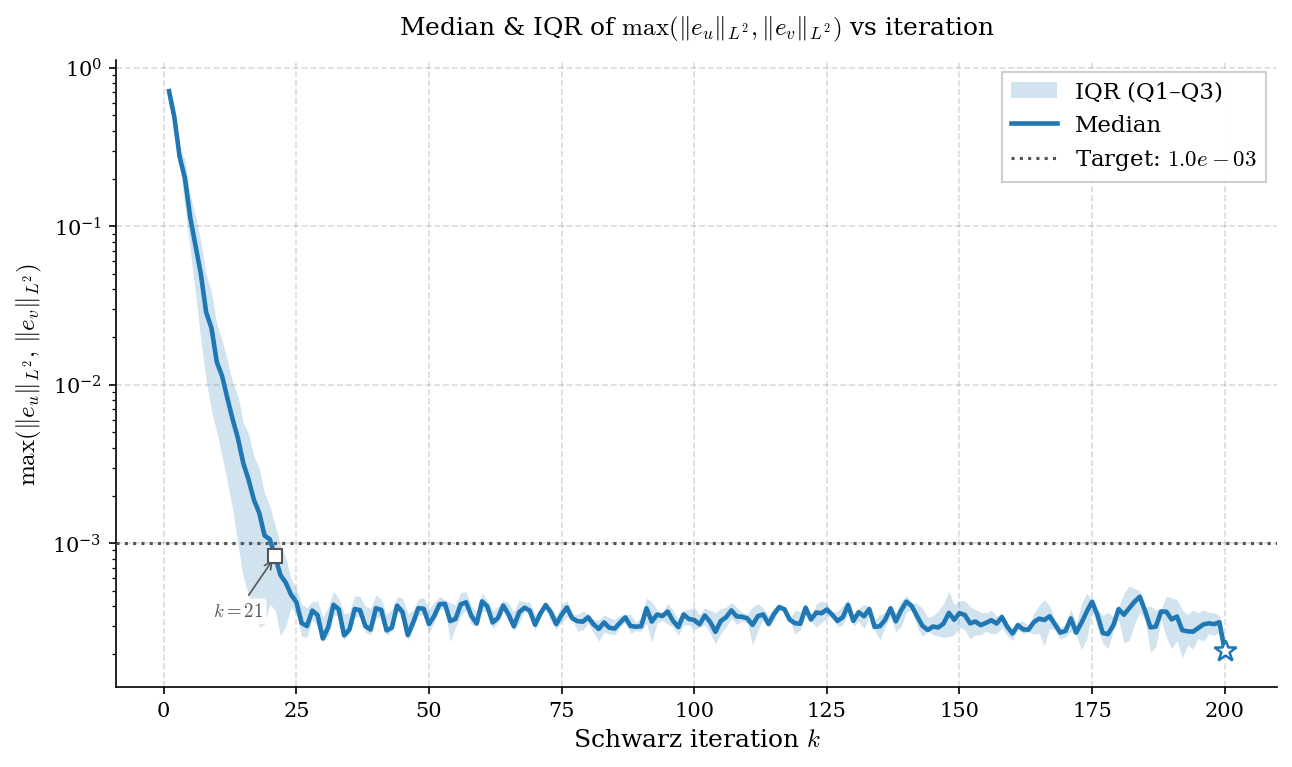

[Saved] content/aggregate/stats_gap.png


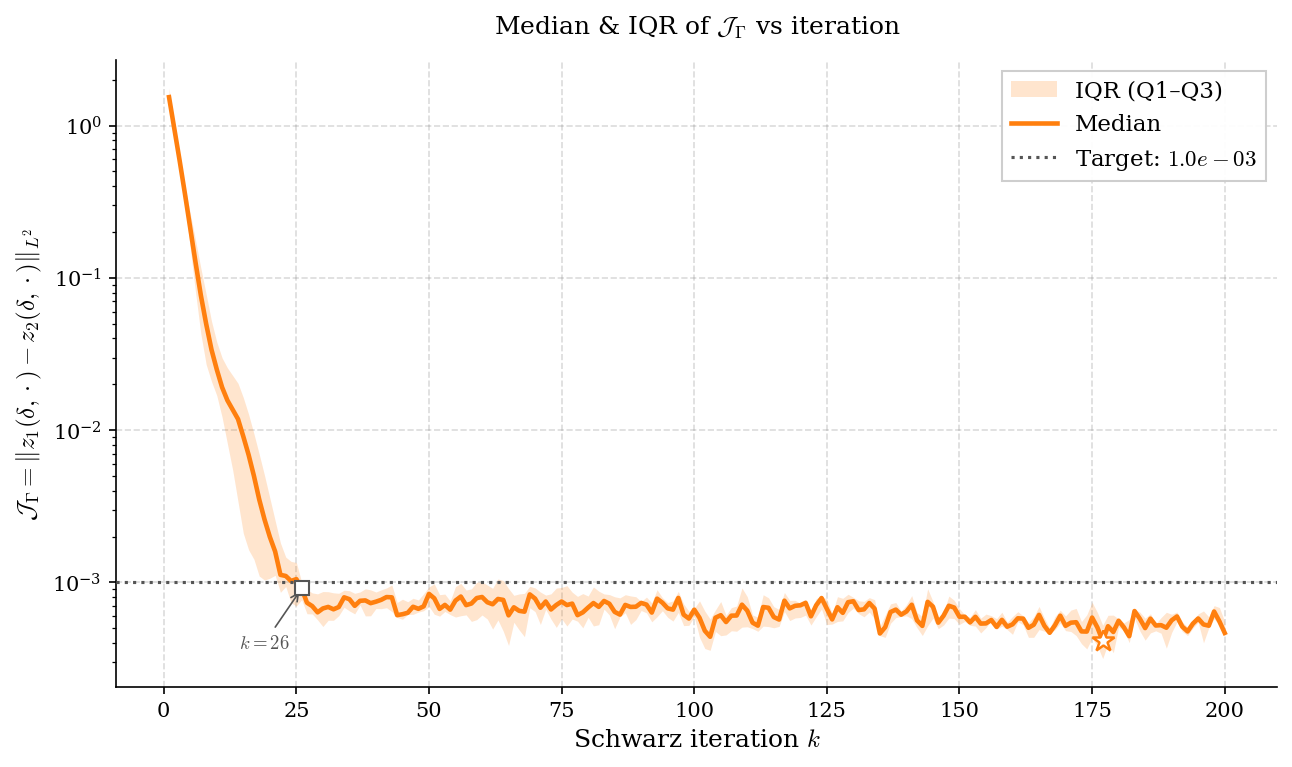

In [ ]:
# @title Statistical convergence dynamics across random seeds for symmetric decomposition
# -----------------------------------------------------------------------------
# Purpose: aggregate convergence behavior across random seeds.
# Inputs: `LOG_TEXT_BY_SEED` or log files on disk.
# Outputs: summary dataframes and convergence plots.
# -----------------------------------------------------------------------------

import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from typing import Dict

# 1. CONFIGURATION & COLOR PALETTE
_default_outdir = "/content/aggregate" if os.path.isdir("/content") else "aggregate"
OUTDIR           = globals().get("OUTDIR", _default_outdir)
SAVE_SVG         = True
DPI_PNG          = 300
PLOT_INDIV_SEEDS = False
LIMIT_ITERS      = globals().get("LIMIT_ITERS", None)
SHOW_PLOTS       = True
ONLY_FIRST_TWO   = True

# Convergence Thresholds
TARGET_ACC = globals().get("TARGET_ACC", 1e-3)
TARGET_GAP = globals().get("TARGET_GAP", 1e-3)

# --- Colors ---
C_ERR    = "#1f77b4"
C_GAP    = "#ff7f0e"
C_TARGET = "#555555"
C_GRID   = "#7f7f7f"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
    "grid.color": C_GRID,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
    "legend.edgecolor": "0.8",
    "figure.dpi": 150,
})
os.makedirs(OUTDIR, exist_ok=True)

# 2. DATA PARSING
_NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"

RE_L2_PAIR = re.compile(
    r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*u\s*\)\s*=\s*(" + _NUM + r")\s+.*?L2\s*\(\s*v\s*\)\s*=\s*(" + _NUM + r")",
    re.IGNORECASE
)
RE_L2U  = re.compile(r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*u\s*\)\s*=\s*(" + _NUM + r")", re.IGNORECASE)
RE_L2V  = re.compile(r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*v\s*\)\s*=\s*(" + _NUM + r")", re.IGNORECASE)
RE_GAP  = re.compile(r"\[iter\s+(\d+)\]\s*.*?z1.*?(?:-|−|–)\s*z2.*?=\s*(" + _NUM + r")", re.IGNORECASE)
RE_RMAX = re.compile(r"r1\s*=\s*(" + _NUM + r")\s*r2\s*=\s*(" + _NUM + r")\s*\(max\s*=\s*(" + _NUM + r")\)", re.IGNORECASE)

def parse_log_text(log_text: str) -> Dict:
    data = {"iters": set(), "L2u": {}, "L2v": {}, "gap": {}, "rmax": {}}
    current_iter = None

    for line in log_text.splitlines():
        m = RE_L2_PAIR.search(line)
        if m:
            k = int(m.group(1))
            data["L2u"][k] = float(m.group(2))
            data["L2v"][k] = float(m.group(3))
            data["iters"].add(k)
            current_iter = k
            continue

        m = RE_L2U.search(line)
        if m:
            k = int(m.group(1))
            data["L2u"][k] = float(m.group(2))
            data["iters"].add(k)
            current_iter = k

        m = RE_L2V.search(line)
        if m:
            k = int(m.group(1))
            data["L2v"][k] = float(m.group(2))
            data["iters"].add(k)
            current_iter = k

        m = RE_GAP.search(line)
        if m:
            k = int(m.group(1))
            data["gap"][k] = float(m.group(2))
            data["iters"].add(k)

        m = RE_RMAX.search(line)
        if m and current_iter is not None:
            data["rmax"][current_iter] = float(m.group(3))

    sorted_iters = sorted(list(data["iters"]))
    if LIMIT_ITERS is not None:
        sorted_iters = [k for k in sorted_iters if k <= LIMIT_ITERS]
    data["iters"] = sorted_iters
    return data

def load_logs(log_dict=None, log_dir=None):
    parsed_logs = {}
    if log_dir:
        for fpath in glob.glob(log_dir):
            name = os.path.splitext(os.path.basename(fpath))[0]
            with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
                parsed_logs[name] = parse_log_text(f.read())
    if log_dict:
        for name, txt in log_dict.items():
            parsed_logs[name] = parse_log_text(txt)
    return parsed_logs

# 3. STATISTICAL AGGREGATION
def compute_statistics(seed_data: Dict, metric: str):
    all_iters = set()
    for p in seed_data.values():
        all_iters.update(p["iters"])
    sorted_iters = sorted(list(all_iters))
    if LIMIT_ITERS is not None:
        sorted_iters = [k for k in sorted_iters if k <= LIMIT_ITERS]

    if not sorted_iters:
        return [], pd.DataFrame(), {}

    seed_series = {}
    matrix_rows = []

    for seed, p in seed_data.items():
        row_vals = []
        for k in sorted_iters:
            val = np.nan
            if metric == "L2max":
                u = p["L2u"].get(k, np.nan)
                v = p["L2v"].get(k, np.nan)
                if np.isfinite(u) and np.isfinite(v):
                    val = max(u, v)
                elif np.isfinite(u):
                    val = u
                elif np.isfinite(v):
                    val = v
            elif metric in ["L2u", "L2v"]:
                val = p[metric].get(k, np.nan)
            elif metric in ["gap", "rmax"]:
                val = p[metric].get(k, np.nan)
            row_vals.append(val)

        arr = np.array(row_vals, dtype=float)
        seed_series[seed] = arr
        matrix_rows.append(arr)

    M = np.vstack(matrix_rows)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", r"All-NaN (slice|axis) encountered")
        median = np.nanmedian(M, axis=0)
        q1     = np.nanpercentile(M, 25, axis=0)
        q3     = np.nanpercentile(M, 75, axis=0)
        count  = np.sum(np.isfinite(M), axis=0)

    df_stats = pd.DataFrame({
        "iter": sorted_iters,
        "median": median,
        "q1": q1,
        "q3": q3,
        "count": count
    })
    return sorted_iters, df_stats, seed_series

# 4. PLOTTING
def first_below(x, y, target):
    for k, v in zip(x, y):
        if np.isfinite(v) and v > 0 and v <= target:
            return int(k), float(v)
    return None, None

def best_point(x, y):
    mask = np.isfinite(y) & (y > 0)
    if not np.any(mask):
        return None, None
    idx = np.argmin(y[mask])
    return int(np.asarray(x)[mask][idx]), float(np.asarray(y)[mask][idx])

def plot_convergence(iters, df, seed_series, title, ylabel, outname, main_color, target=None):
    if df.empty:
        return

    x = np.array(iters, dtype=int)
    med = df["median"].to_numpy(dtype=float)
    q1  = df["q1"].to_numpy(dtype=float)
    q3  = df["q3"].to_numpy(dtype=float)

    def _pos(a):
        a = a.copy()
        a[~np.isfinite(a)] = np.nan
        a[a <= 0] = np.nan
        return a

    medp = _pos(med)
    q1p  = _pos(q1)
    q3p  = _pos(q3)

    valid = medp[np.isfinite(medp)]
    use_log = bool(valid.size) and (np.nanmax(valid) / np.nanmin(valid) > 50)

    fig, ax = plt.subplots(figsize=(8.5, 5.0), constrained_layout=True)

    if PLOT_INDIV_SEEDS:
        for s_vals in seed_series.values():
            s = _pos(np.asarray(s_vals, dtype=float))
            ax.plot(x, s, color=main_color, lw=0.6, alpha=0.10, zorder=1)

    ax.fill_between(x, q1p, q3p, color=main_color, alpha=0.20, lw=0, zorder=2, label="IQR (Q1–Q3)")
    ax.plot(x, medp, color=main_color, lw=2.2, alpha=1.0, zorder=3, label="Median")

    if target is not None:
        ax.axhline(target, color=C_TARGET, ls=":", lw=1.5, zorder=4, label=rf"Target: ${target:.1e}$")
        k_conv, v_conv = first_below(x, medp, target)
        if k_conv is not None:
            ax.plot(k_conv, v_conv, marker="s", ms=6.5, mfc="white", mec=C_TARGET, mew=1.0, zorder=6)
            ax.annotate(
                rf"$k={k_conv}$",
                xy=(k_conv, v_conv),
                xytext=(-18, -22), textcoords="offset points",
                fontsize=9, color=C_TARGET,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
                arrowprops=dict(arrowstyle="->", color=C_TARGET, lw=0.8),
                ha="center", va="top",
            )

    k_best, v_best = best_point(x, medp)
    if k_best is not None:
        ax.plot(k_best, v_best, marker="*", ms=11, mfc="white", mec=main_color, mew=1.2, zorder=7)

    ax.set_xlabel(r"Schwarz iteration $k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if use_log:
        ax.set_yscale("log")
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    else:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    if "count" in df.columns and np.nanmin(df["count"].values) != np.nanmax(df["count"].values):
        ax.text(
            0.02, 0.02,
            rf"$N_{{seeds}}(k)\in[{int(np.nanmin(df['count']))},{int(np.nanmax(df['count']))}]$",
            transform=ax.transAxes,
            fontsize=9, color=C_TARGET
        )

    ax.legend(loc="upper right", frameon=True)
    path_png = os.path.join(OUTDIR, f"{outname}.png")
    fig.savefig(path_png, dpi=DPI_PNG)
    if SAVE_SVG:
        fig.savefig(os.path.join(OUTDIR, f"{outname}.svg"))
    fig.savefig(os.path.join(OUTDIR, f"{outname}.pdf"))

    print(f"[Saved] {path_png}")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

# 5. MAIN EXECUTION
def main():
    logs_to_process = globals().get("SEED_LOGS", {})
    log_dir = globals().get("LOG_DIR", None)

    if not logs_to_process and not log_dir:
        print("[Info] No logs found. Generating dummy data...")
        for i in range(5):
            it = np.arange(1, 201)
            decay = 1.0 * np.exp(-0.05 * it)
            noise = np.random.normal(0, 0.15 * decay, size=len(it))
            u = np.abs(decay + noise)
            g = np.abs(0.5 * decay + 0.5 * noise)

            log_str = ""
            for k, val_u, val_g in zip(it, u, g):
                log_str += f"[iter {k}] L2(u)={val_u:.4e} L2(v)={val_u*0.9:.4e}\n"
                log_str += f"[iter {k}] z1-z2={val_g:.4e}\n"
            logs_to_process[f"seed_{i}"] = log_str

    parsed_data = load_logs(log_dict=logs_to_process, log_dir=log_dir)
    if not parsed_data:
        print("[Error] No data.")
        return

    tasks = [
        ("L2max",
         r"$\max(\|e_u\|_{L^2},\,\|e_v\|_{L^2})$",
         r"Median & IQR of $\max(\|e_u\|_{L^2},\|e_v\|_{L^2})$ vs iteration",
         "stats_L2max", TARGET_ACC, C_ERR),

        ("gap",
         r"$\mathcal{J}_\Gamma=\|z_1(\delta,\cdot)-z_2(\delta,\cdot)\|_{L^2}$",
         r"Median & IQR of $\mathcal{J}_\Gamma$ vs iteration",
         "stats_gap", TARGET_GAP, C_GAP),

        ("rmax",
         r"$\max(r_1,r_2)$",
         r"Median & IQR of $\max(r_1,r_2)$ vs iteration",
         "stats_rmax", None, C_ERR),
    ]
    if ONLY_FIRST_TWO:
        tasks = tasks[:2]

    for metric, ylab, title, fname, tgt, col in tasks:
        iters, df, series = compute_statistics(parsed_data, metric)
        df.to_csv(os.path.join(OUTDIR, f"{fname}.csv"), index=False)
        plot_convergence(iters, df, series, title, ylab, fname, main_color=col, target=tgt)

if __name__ == "__main__":
    main()


## Seed Robustness Summary Plots

This cell creates compact bar plots comparing final or best L2 errors across random seeds.


Figures saved to seed_robustness_figs/robustness_plot_final.png


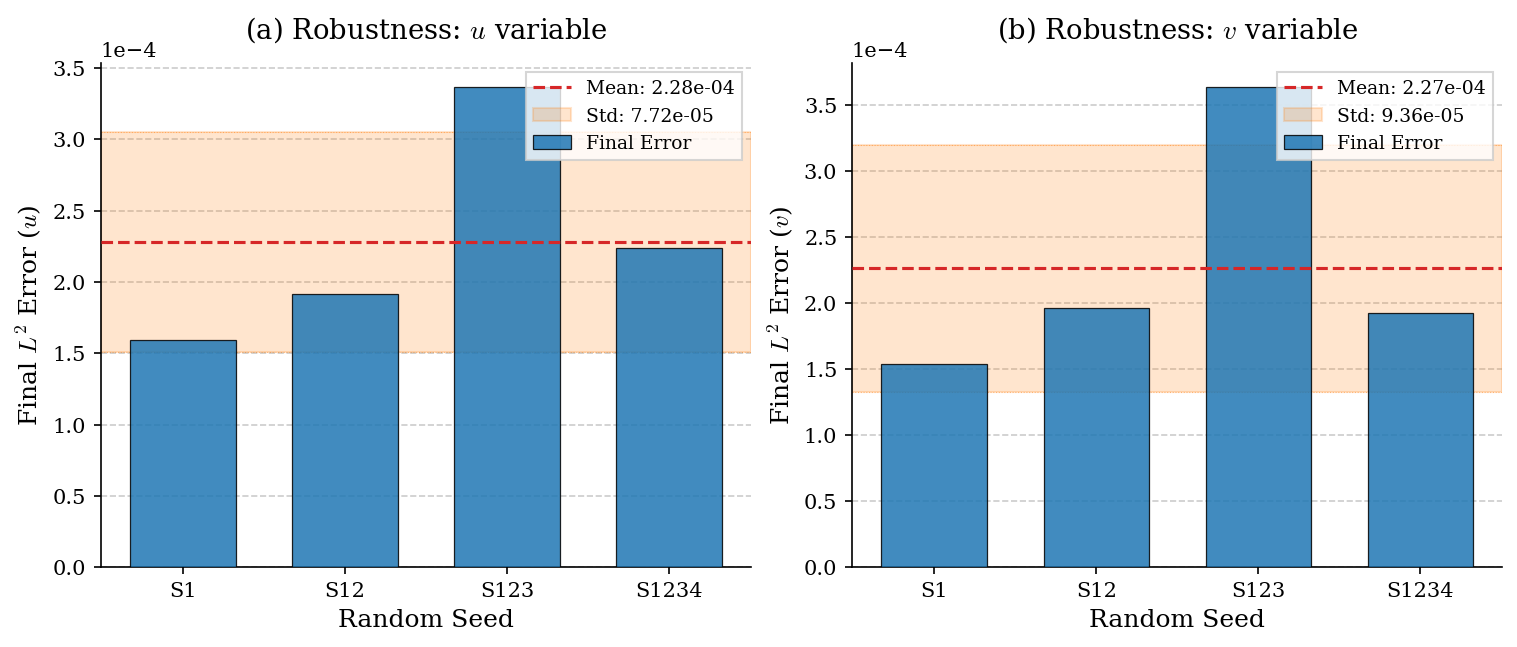

In [ ]:
# @title Seed robustness summary plots
# -----------------------------------------------------------------------------
# Purpose: summarize seed robustness using final or best L2 errors.
# Inputs: `LOG_TEXT_BY_SEED` from the logs cell.
# Outputs: bar plots for u and v error robustness.
# -----------------------------------------------------------------------------

import re
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# ------------------------------------------------------------------------------
# 1. MASTER COLOR PALETTE
# ------------------------------------------------------------------------------
C_BLUE   = "#1f77b4"  # Primary Data (Bars)
C_ORANGE = "#ff7f0e"  # Uncertainty / Std Dev
C_GREEN  = "#2ca02c"  # Ground Truth
C_RED    = "#d62728"  # Mean / Highlight
C_GREY   = "#7f7f7f"  # Grid / Annotations
C_DARK   = "#333333"  # Text

# ------------------------------------------------------------------------------
# 2. PARSING LOGIC
# ------------------------------------------------------------------------------
_NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
PAT_L2 = re.compile(
    rf"\[iter\s*(\d+)\]\s*L2\(u\)\s*=\s*({_NUM})\s+L2\(v\)\s*=\s*({_NUM})",
    re.IGNORECASE
)

def _normalize_text(s: str) -> str:
    """Handles unicode minus signs and zero-width spaces often found in PDFs/Web."""
    return s.replace("\u200b", "").replace("\ufeff", "").replace("−", "-")

def extract_l2_series(log_text: str):
    """Parses iterations and errors from a single log string."""
    txt = _normalize_text(log_text)
    iters, u_vals, v_vals = [], [], []
    for m in PAT_L2.finditer(txt):
        iters.append(int(m.group(1)))
        u_vals.append(float(m.group(2)))
        v_vals.append(float(m.group(3)))

    if not iters:
        # Fallback: return dummy data if parsing fails (prevents crash during debug)
        return [0], [0]

    order = np.argsort(iters)
    return [u_vals[i] for i in order], [v_vals[i] for i in order]

def pick_metric(u_vals, v_vals, use_min_over_iters: bool):
    """Selects either the final error or the best error observed."""
    if not u_vals: return np.nan, np.nan
    if use_min_over_iters:
        return float(np.min(u_vals)), float(np.min(v_vals))
    return float(u_vals[-1]), float(v_vals[-1])

# ------------------------------------------------------------------------------
# 3. PLOTTING STYLE & GENERATION
# ------------------------------------------------------------------------------
def make_seed_robustness_plots(log_data_map,
                               use_min_over_iters=False,
                               use_log_scale=True,
                               outdir="seed_robustness_figs"):

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 150
    })

    os.makedirs(outdir, exist_ok=True)
    seeds = sorted(log_data_map.keys())
    if not seeds:
        print("No seed data provided.")
        return

    l2u_vals, l2v_vals = [], []
    for s in seeds:
        u_series, v_series = extract_l2_series(log_data_map[s])
        u_pick, v_pick = pick_metric(u_series, v_series, use_min_over_iters)
        l2u_vals.append(u_pick)
        l2v_vals.append(v_pick)

    # Convert to arrays for stats
    data_groups = [np.array(l2u_vals), np.array(l2v_vals)]
    titles = [r"(a) Robustness: $u$ variable", r"(b) Robustness: $v$ variable"]
    ylabels = [r"Final $L^2$ Error ($u$)", r"Final $L^2$ Error ($v$)"]

    # --- C. Create Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

    for i, ax in enumerate(axes):
        vals = data_groups[i]
        # Filter NaNs
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        # Statistics
        mean_val = np.mean(vals)
        std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
        x_pos = np.arange(len(seeds))

        bottom_val = min(vals)/10 if use_log_scale else 0
        bars = ax.bar(x_pos, vals, width=0.65,
                      color=C_BLUE, edgecolor="black", linewidth=0.6,
                      alpha=0.85, zorder=3, label="Final Error")

        # 2. Mean Line (Red Dashed)
        ax.axhline(mean_val, color=C_RED, linestyle="--", linewidth=1.5, zorder=5,
                   label=f"Mean: {mean_val:.2e}")

        lower_bound = max(1e-16, mean_val - std_val)
        upper_bound = mean_val + std_val

        ax.axhspan(lower_bound, upper_bound, color=C_ORANGE, alpha=0.2, zorder=2,
                   label=f"Std: {std_val:.2e}")

        ax.axhline(upper_bound, color=C_ORANGE, lw=0.5, alpha=0.5, ls=':')
        ax.axhline(lower_bound, color=C_ORANGE, lw=0.5, alpha=0.5, ls=':')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"S{s}" for s in seeds], rotation=0)
        ax.set_xlabel("Random Seed")
        ax.set_ylabel(ylabels[i])
        ax.set_title(titles[i], pad=12)

        # Grid
        ax.grid(True, axis='y', which='major', linestyle='--', alpha=0.4, color=C_GREY)

        # Scale Handling
        if use_log_scale:
            ax.set_yscale('log')
            ax.yaxis.set_minor_formatter(NullFormatter())
        else:
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        # Legend (Clean)
        ax.legend(frameon=True, fancybox=False, edgecolor="0.8", loc="upper right", fontsize=9)

    # --- D. Save ---
    suffix = "min" if use_min_over_iters else "final"
    save_path = os.path.join(outdir, f"robustness_plot_{suffix}")

    plt.savefig(f"{save_path}.png", dpi=600)
    plt.savefig(f"{save_path}.pdf") # Vector format for LaTeX

    print(f"Figures saved to {save_path}.png")
    plt.show()
if 'LOG_TEXT_BY_SEED' not in globals():
    print("[Info] 'LOG_TEXT_BY_SEED' not found. Generating dummy data for demonstration.")
    LOG_TEXT_BY_SEED = {}
    for s in [0, 42, 123, 2024, 9999]:
        noise = np.random.uniform(0.5, 2.0)
        LOG_TEXT_BY_SEED[s] = f"[iter 200] L2(u)={1e-3 * noise:.3e} L2(v)={1e-3 * noise * 0.9:.3e}"

make_seed_robustness_plots(LOG_TEXT_BY_SEED, use_min_over_iters=False, use_log_scale=False)
